# Análisis de tasa de cancelación de clientes en banco ABC

---

## Índice general

- [1. Introducción](#Introducción)
- [2. Carga y descripción del conjunto de datos](#Carga_y_descripción_del_conjunto_de_datos)
- [3. Preprocesamiento de datos](#Preprocesamiento_de_datos)
- [4. Análisis exploratorio de datos](#Análisis_exploratorio_de_datos)
    - [4.1 Análisis de variables continuas](#Análisis_de_variables_continuas)
        - [4.1.1 Gráficos de violín](#Gráficos_de_violín)
        - [4.1.2 Función de distribución acumulada](#Función_de_distribución_acumulada)
        - [4.1.3 Relación entre saldo y abandono](#Relación_entre_saldo_y_abandono)
        - [4.1.4 Número de productos por clase](#Número_de_productos_por_clase)
    - [4.2 Análisis de variables categóricas](#Análisis_de_variables_categóricas)
        - [4.2.1 Gráficas de barra](#Gráficas_de_barras)
        - [4.2.2 Gráficas de barra apilada](#Gráficas_de_barras_apilada)
    - [4.3 Resumen de análisis exploratorio](#Resumen_de_análisis_exploratorio)
- [5. Partición de datos](#Partición_de_datos)
- [6. Pruebas estadísticas](#Pruebas_estadísticas)
    - [6.1 Similitud en distribución](#Similitud_en_distribución)
    - [6.2 Tendencia de valores](#Tendencia_de_valores)
    - [6.3 Saldo en cuentas de clientes](#Saldo_en_cuentas_de_clientes)
        - [6.3.1 Clientes con saldo en cuenta](#Clientes_con_saldo_en_cuenta)
        - [6.3.2 Clientes sin saldo en cuenta](#Clientes_sin_saldo_en_cuenta)
    - [6.4 Correlaciones entre variables](#Correlaciones_entre_variables)
    - [6.5 Variables categóricas discriminantes](#Variables_categóricas_discriminantes)
    - [6.6 Diferencias en proporciones](#Diferencias_en_proporciones)
    - [6.7 Dependencia entre variables categóricas](#Dependencia_entre_variables_categóricas)
    - [6.8 Resumen de pruebas estadísticas](#Resumen_de_pruebas_estadísticas)
- [7. Transformación de datos](#Transformación_de_datos)
- [8. Entrenamiento de modelos](#Entrenamiento_de_modelos)
    - [8.1 Regresión logística](#Regresión_logística)
    - [8.2 K-Nearest_Neighbors](#KNearest_Neighbors)
    - [8.3 Árboles de decisión](#Árboles_de_decisión)
    - [8.4 Random forest](#Random_forest)
    - [8.5 Gradient boosting classifier](#Gradient_boosting_classifier)

_____

<a name='Introducción'></a>
## Introducción

En este proyecto se llevará a cabo un análisis de datos relacionados con clientes que han cancelado su servicio (*churn*) en el banco multinacional ABC. El objetivo principal es identificar *insights* relevantes a partir del conjunto de datos que permitan predecir de manera efectiva la deserción de clientes. Utilizando estos datos se desarrollarán modelos de Machine Learning y Deep Learning que permitarán detectar potenciales patrones de deserción de clientes para así implementar estrategias de retención.

El conjunto de datos que será utilizado fue obtenido del repositorio Kaggle y se encuentra disponible en el siguiente enlace: [Bank Customer Churn Dataset](https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data)

----

<a name='Carga_y_descripción_del_conjunto_de_datos'></a>
## Carga y descripción del conjunto de datos

Para realizar el análisis de datos, importamos algunas de las librerías que se requerirán.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
#matplotlib inline

Importamos el conjunto de datos e imprimimos las primeras instancias.

In [4]:
df = pd.read_csv('C:/Users/Adrej/OneDrive/Escritorio/Proyectos/BankCustomerChurnPrediction/BankCustomerChurnPrediction.csv')
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


El conjunto de datos está compuesto por 12 variables. A continuación, se describen las variables, numéricas y categóricas, con la que este se encuentra compuesto:

**Variables numéricas:**
- `credit_score`: Puntaje crediticio basado en el análisis del historial financiero del cliente. Representa su solvencia, y usualmente varía en un rango de 300 a 850.
- `age`: Edad del cliente en años.
- `tenure`: Años de antigüedad del cliente como usuario del banco.
- `balance`: Saldo actual en la cuenta del cliente.
- `products_number`: Número de productos o servicios financieros contratados (por ejemplo, tarjeta de crédito, débito, préstamos, etc.).
- `estimated_salary`: Ingreso estimado del cliente, ya sea reportado o inferido, generalmente expresado en términos anuales.

**Variables categóricas**:
- `country`: País de residencia del cliente.
- `gender`: Género del cliente.
- `credit_card`: Variable binaria que indica si el cliente posee una tarjeta de crédito emitida por el banco ABC.
- `active_member`: Variable binaria que señala si el cliente ha estado activo recientemente (por ejemplo, mediante transacciones u operaciones bancarias).

**Variable objetivo**:
- `churn`: Variable binaria que indica si el cliente ha cancelado su servicio con el banco.

Adicionalmente, el conjunto de datos contiene la variable `customer_id`, que corresponde al identificador único del cliente. Dado que no aporta información útil para el análisis predictivo, se excluirá del conjunto de características en la etapa del preprocesamiento.

A continuación, se presentan los tipos de datos de cada una de las variables del conjunto.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


Se observa que el conjunto de datos contiene 10,000 instancias y que no presenta valores nulos en ninguna de sus variables. A continuación, se muestran las distribuciones generales de las variables, así como un resumen estadístico de estas.

In [6]:
df.describe(include = 'all')

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.569094e+07,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


Se observa que la variable de países (`contry`) contiene sólo 3 valores distintos. A continuación se imprimirán estas tres instancias:

In [7]:
df['country'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

Por último, se revisará la distribución de la variable objetivo `churn`, lo que permitirá conocer si los datos se encuentran balanceados. 

In [8]:
df['churn'].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

Como se puede observar, la variable objetivo presenta un desequilibrio en la distribución de clases, siendo solo un 20% el porcentaje de instancias positivas. Esto es de gran relevancia, ya que se debe tener cuidado al momento de entrenar modelos, pues podrían inclinarse a favorecer a la clase mayoritaria, lo que resultaría en un sobreajuste y un rendimiento deficiente en la detección de la clase positiva.

----

<a name='Preprocesamiento_de_datos'></a>
## Preprocesamiento de datos

Dado que el conjunto de datos no cuenta con valores nulos, no es necesario realizar un proceso de limpieza en el preprocesamiento. Sin embargo, como se mencionó, es necesario eliminar la variable `customer_id` dado que no aporta información relevante. 

In [9]:
df.drop(columns = ['customer_id'], inplace = True)

----

<a name = 'Análisis_exploratorio_de_datos'></a>
## Análisis exploratorio de datos

Se analizarán las distribuciones de las distintas variables para las distintas clases de la variable objetivo: clientes que en algún momento han abandonado la institución y clientes que nunca han abandonado la institución. Este análisis permitirá identificar diferencias en los patrones de comportamiento entre ambos grupos, lo que es útil para la detección de *insights* y la construcción de modelos predictivos más precisos.

<a name='Análisis_de_variables_continuas'></a>
### Análisis de variables continuas

Como se mencionó en la descripción de las variables, el conjunto de datos se compone de las siguientes variables numéricas:

In [10]:
numerical_vars = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

<a name = 'Gráficos_de_violín'></a>
#### Gráficos de violín

Se empezará realizando un análisis de las distribuciones de los datos para las distintas clases en las distintas variables numéricas utilizando gráficos de violín. A lo largo del análisis exploratorio se utilizarán los siguientes colores para señalar las distintas clases.

In [11]:
churn_colors = ['#191970', '#701919']

A continuación, se imprimen en pantalla los gráficos de violín de los datos.

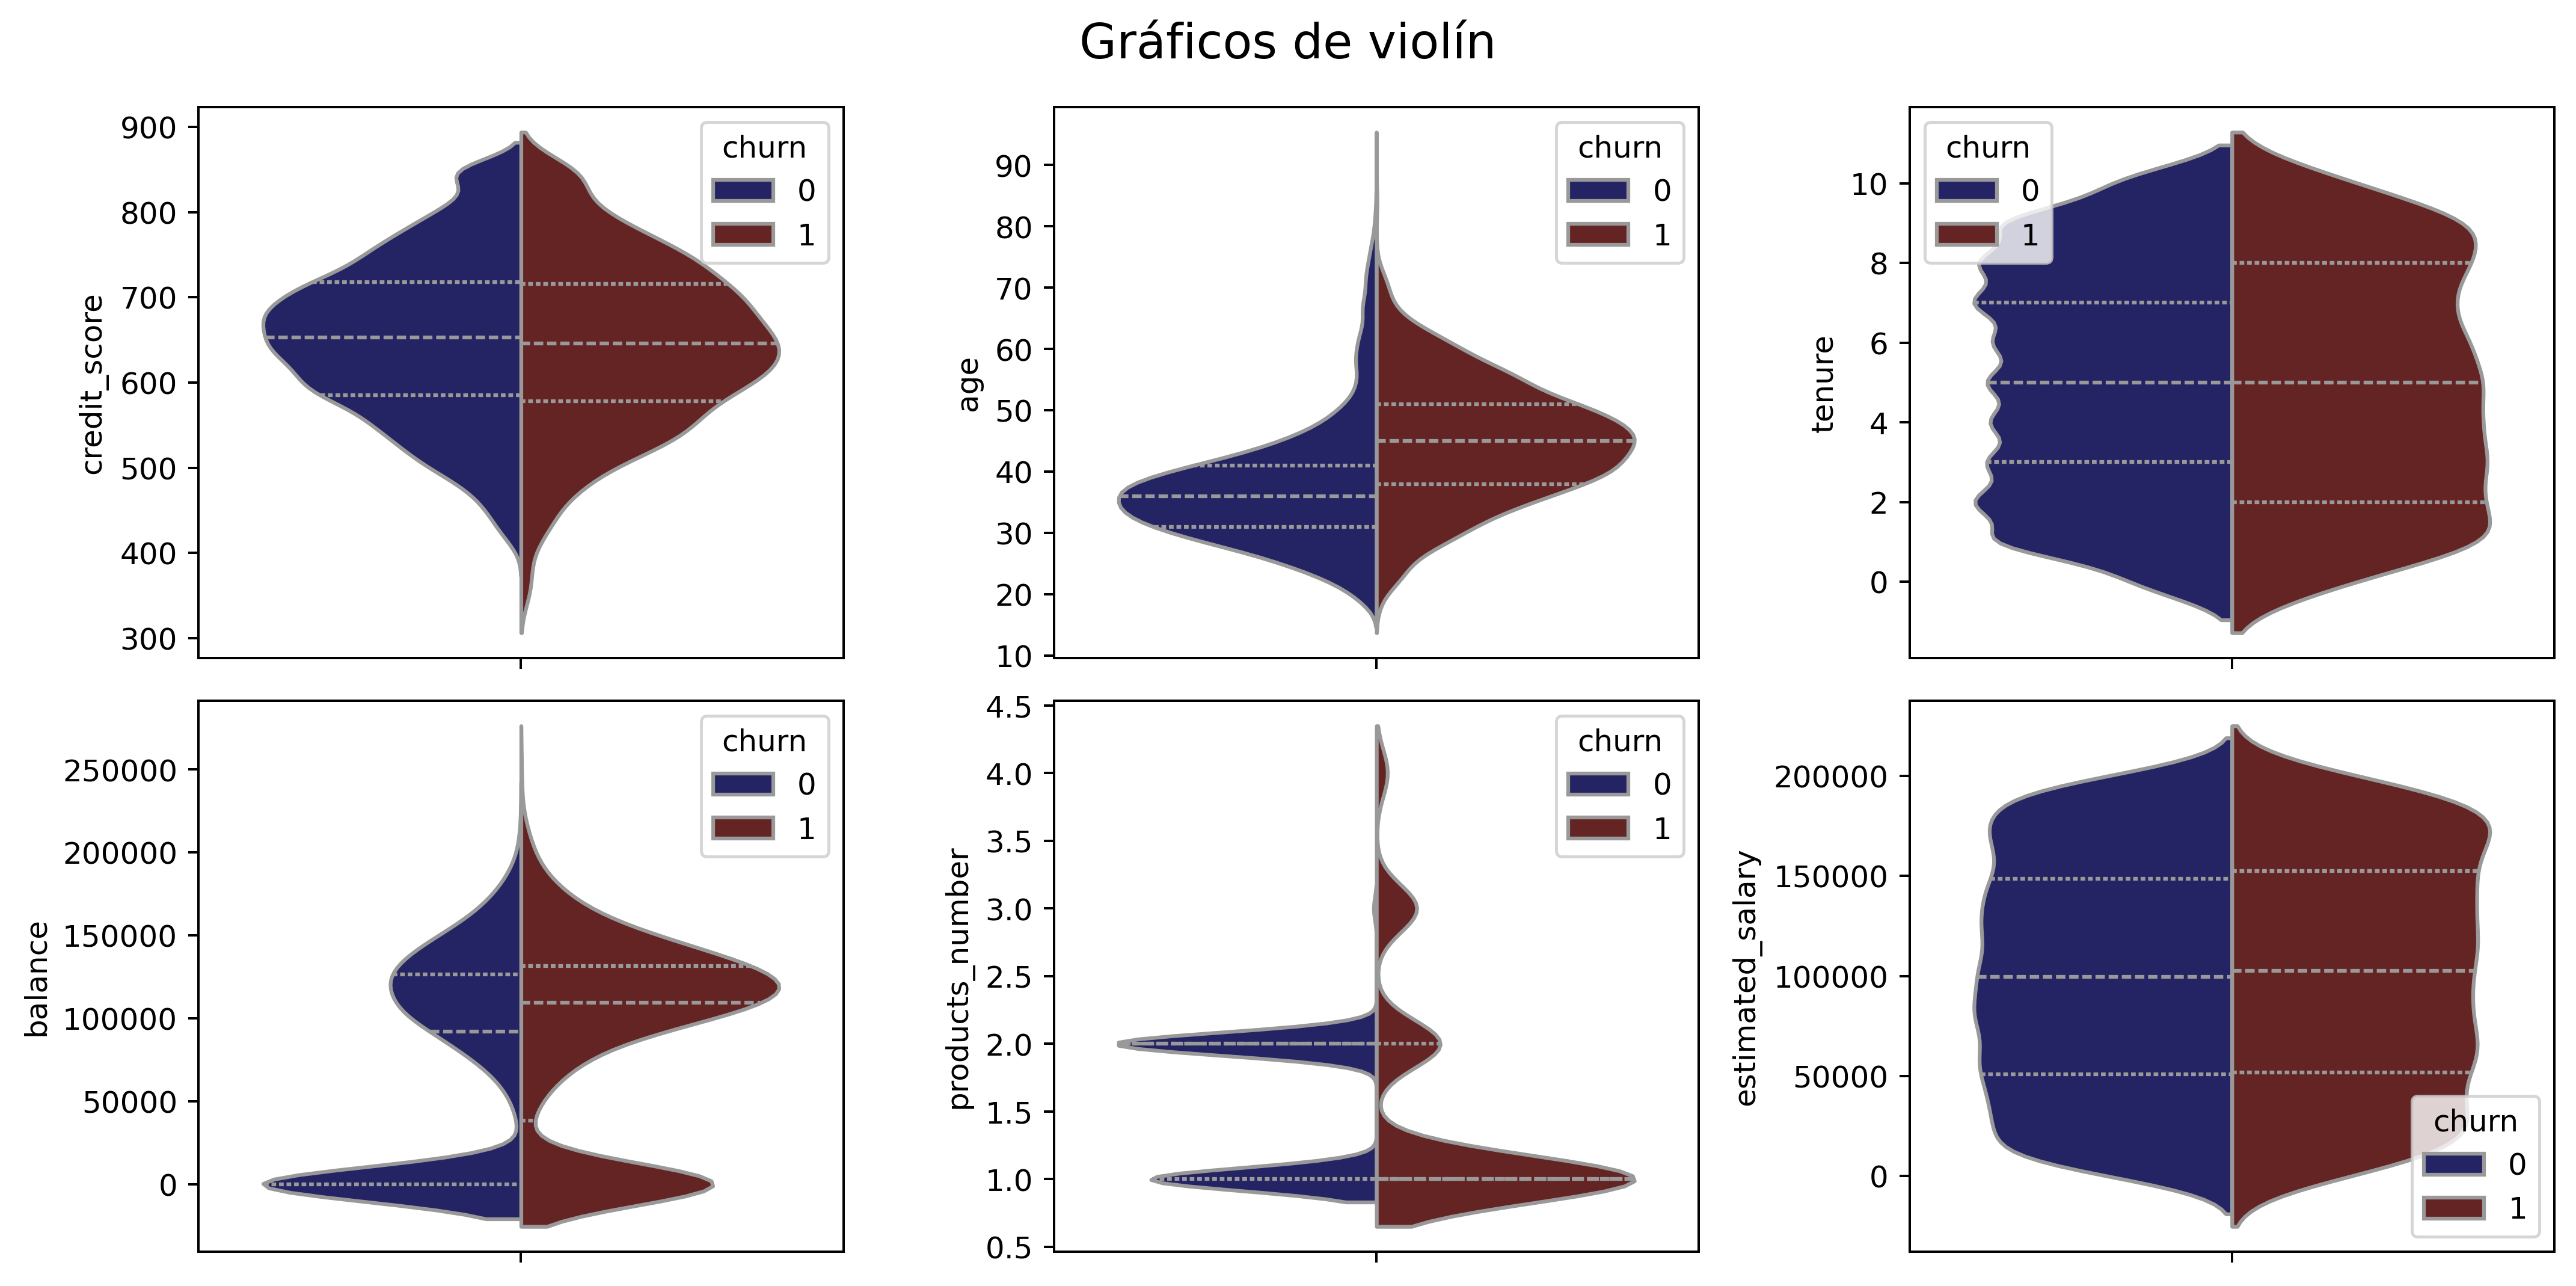

In [12]:
fig, axs = plt.subplots(nrows = 2, ncols = 3, dpi = 360, figsize = (12,6))
fig.suptitle('Gráficos de violín', fontsize = 16)
for i, var in enumerate(numerical_vars):
    row, col = divmod(i,3)
    sns.violinplot(data=df, y=var, hue = 'churn',
                   palette=churn_colors, split=True, inner='quart', ax = axs[row][col], fill = True, linecolor = '#999999')
    axs[row][col].set_ylabel(var)
plt.tight_layout()
plt.show()

A partir de estos gráficos, es posible realizar algunas primeras observaciones relevantes sobre el comportamiento de los clientes. A continuación, se presentan los principales hallazgos junto con preguntas que permitirán realizar un análisis estadístico posterior:

**Similitud en distribuciones de algunas variables**: A simple vista, las distribuciones de puntaje crediticio (`credit_score`), antigüedad en el banco (`tenure`) y salario estimado (`estimated_salary)` parecen ser similares entre clientes que abandonaron y que permanecen en la institución.
* ¿Estadísticamente existe una diferencia significativa entre las distribuciones de ambas clases para estas variables? ¿Qué variables numéricas presentan distribuciones distintas entre clientes que han abandonado y clientes que permanecen en la institución?

**Edad como posible factor determinante**: Se observa que la media de edad de clientes que ha abandonado la institución es mayor que la de los clientes que permancen.
* ¿Estadísticamente, los clientes que abandonan tienden a ser mayores que los que permanecen? ¿Existen otras variables cuya media difiera significativamente entre ambos grupos?

**Relación entre saldo y abandono**: Se observa que la proporción de clientes que poseen un saldo igual a $0 en su cuenta (`balance`) tienden a permanecer en la institución. Por otro lado, la proporción de clientes con un saldo mayor a 0 tiende a abandonarlo. 
- ¿Cómo se distribuye el saldo entre los clientes que se quedan y los que abandonan?

**Número de productos contratados**: En la distribución de clientes que han abandonado la institución, se observa un número considerable de casos con tres o cuatro productos contratados, patrón menos evidente entre los clientes que no han abandonado. Además, la mayoría de los clientes que no han abandonado tienden a tener dos productos, mientras que los que sí han abandonado, predomina tener un solo producto.
- ¿Existe evidencia estadística de que los clientes con un solo producto tienen mayor probabilidad de abandonar el banco?
- ¿Cómo se asigna el número de productos a cada cliente?
- ¿Actualmente la institución tiene implementada alguna estrategia de retención ofreciendo más productos a clientes en riesgo de abandono?
- ¿Existe una relación entre no adquirir más productos y la decisión de abandonar?

En las siguientes secciones se abordarán estas preguntas realizando análisis estadísticos apropiados, con el fin de darle respuesta a las observaciones hechas a partir de la distribución de los datos.

<a name = 'Función_de_distribución_acumulada'></a>
#### Función de distribución acumulada

Si bien el gráfico de violín permite identificar la forma y variabilidad de las distribuciones, la función de distribución acumulada (CDF) facilita comparar de manera precisa la posición relativa y la dispersión de ambas distribuciones, resaltando así diferencias que podrían pasar desapercibidas en gráficos basados solo en densidad.

Se separará el conjunto de datos por cada una de las clases.

In [13]:
df_NoChurn  = df[df['churn']==0]
df_Churn  = df[df['churn']==1]

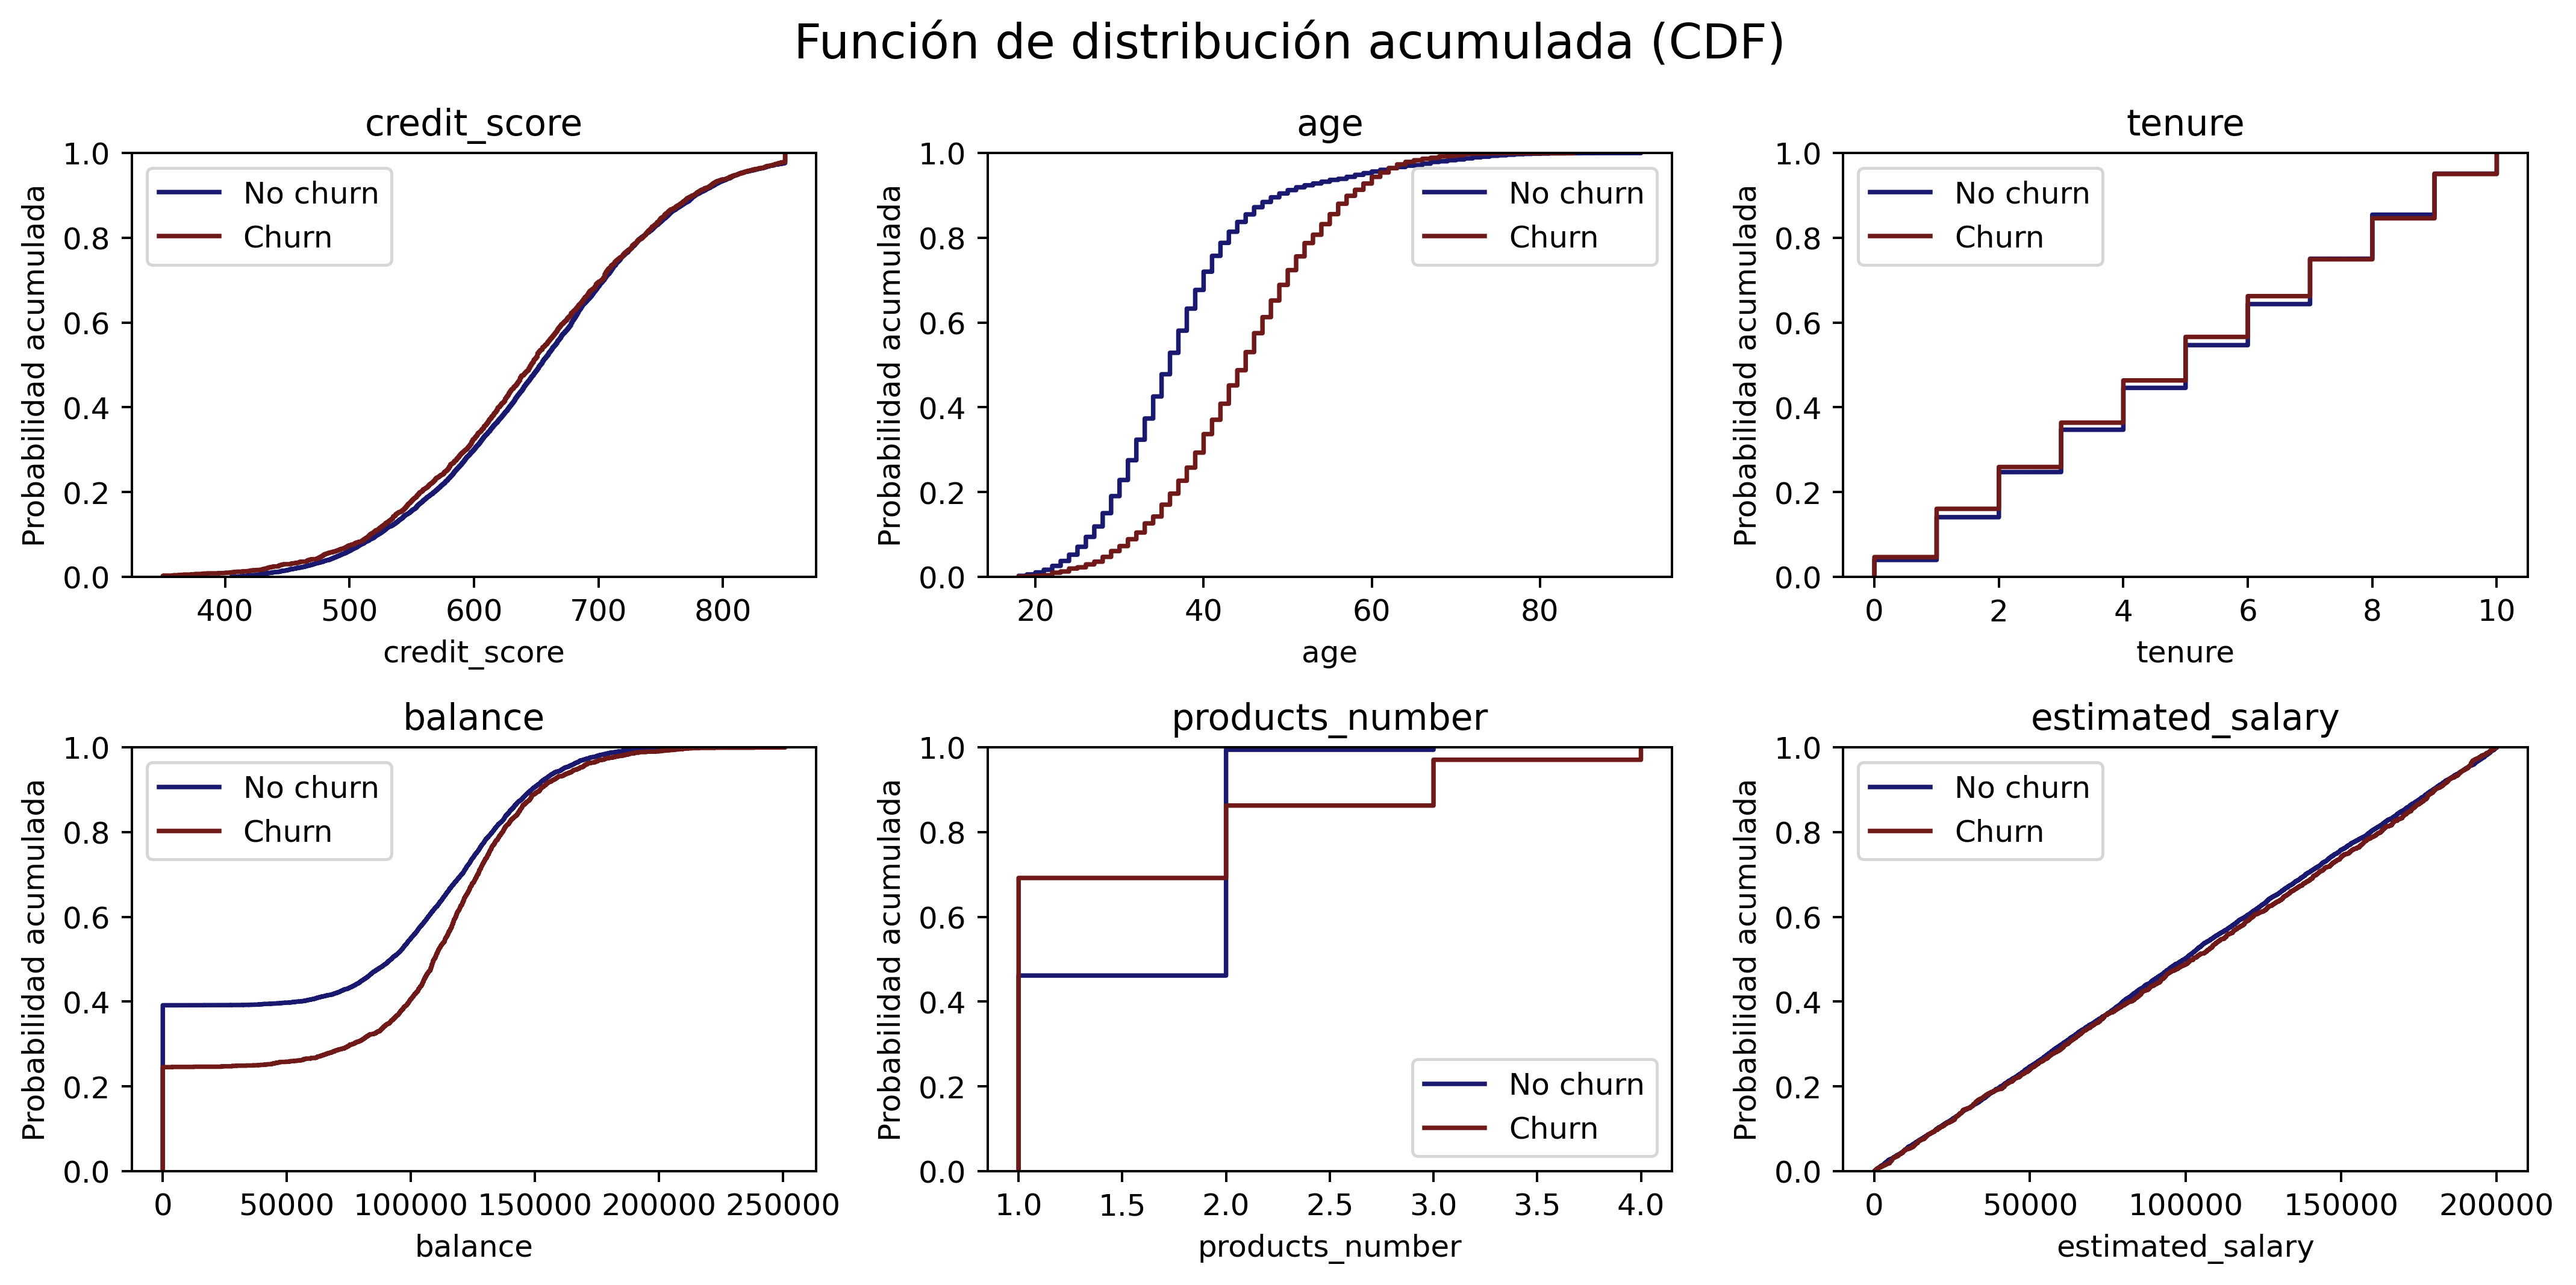

In [14]:
fig, axs = plt.subplots(nrows = 2, ncols = 3, figsize=(12,6), dpi = 360)
fig.suptitle('Función de distribución acumulada (CDF)', fontsize = 16)
for i,var in enumerate(numerical_vars):
    row, col = divmod(i,3)
    axs[row,col].set_title(var)
    axs[row,col].ecdf(df_NoChurn[var], color = churn_colors[0], label = 'No churn')
    axs[row,col].ecdf(df_Churn[var], color = churn_colors[1], label = 'Churn')
    axs[row,col].legend()
    axs[row,col].set_ylabel('Probabilidad acumulada')
    axs[row,col].set_xlabel(var)
plt.tight_layout()
plt.show()

A partir de estas gráficas es posible comparar las distribuciones de los datos en ambas clases desde otro enfoque. Se observa que la edad media de personas que abandonan la institución es mayor que la edad media de las que permanecen. De igual forma, se observa que alrededor del 40\% de todas las personas que permanecen tienen un saldo de $\$0$ en su cuenta, mientras que el porcentaje que abandona con un saldo de $\$0$ es solo del 25\% aproximadamente. Por otra parte, se aprecia que aproximadamente el 70\% de personas que abandonan la institución poseen un solo producto. También se observa que solo las personas que han abandonando cuentan con cuatro productos, mientras que la cantidad de productos de las personas que permanecen es a lo más tres.

<a name = 'Relación_entre_saldo_y_abandono'></a>
#### Relación entre saldo y abandono


En las gráficas de violín y de CDF se observó que la distribución de `balance` en ambas clases son relativamente parecidas. Se analizará a profundidad la distribución para esta variable comparando el histograma de ambas clases.

Para que el histograma tenga las mismas divisiones, se debe determinar el valor mínimo y máximo de los datos que se graficarán. Para ello, se realiza lo siguiente.

In [15]:
min_balance = df['balance'].min()
max_balance = df['balance'].max()

Una vez encontrado el intervalo, se graficará el histograma de la variable `balance` de ambas clases.

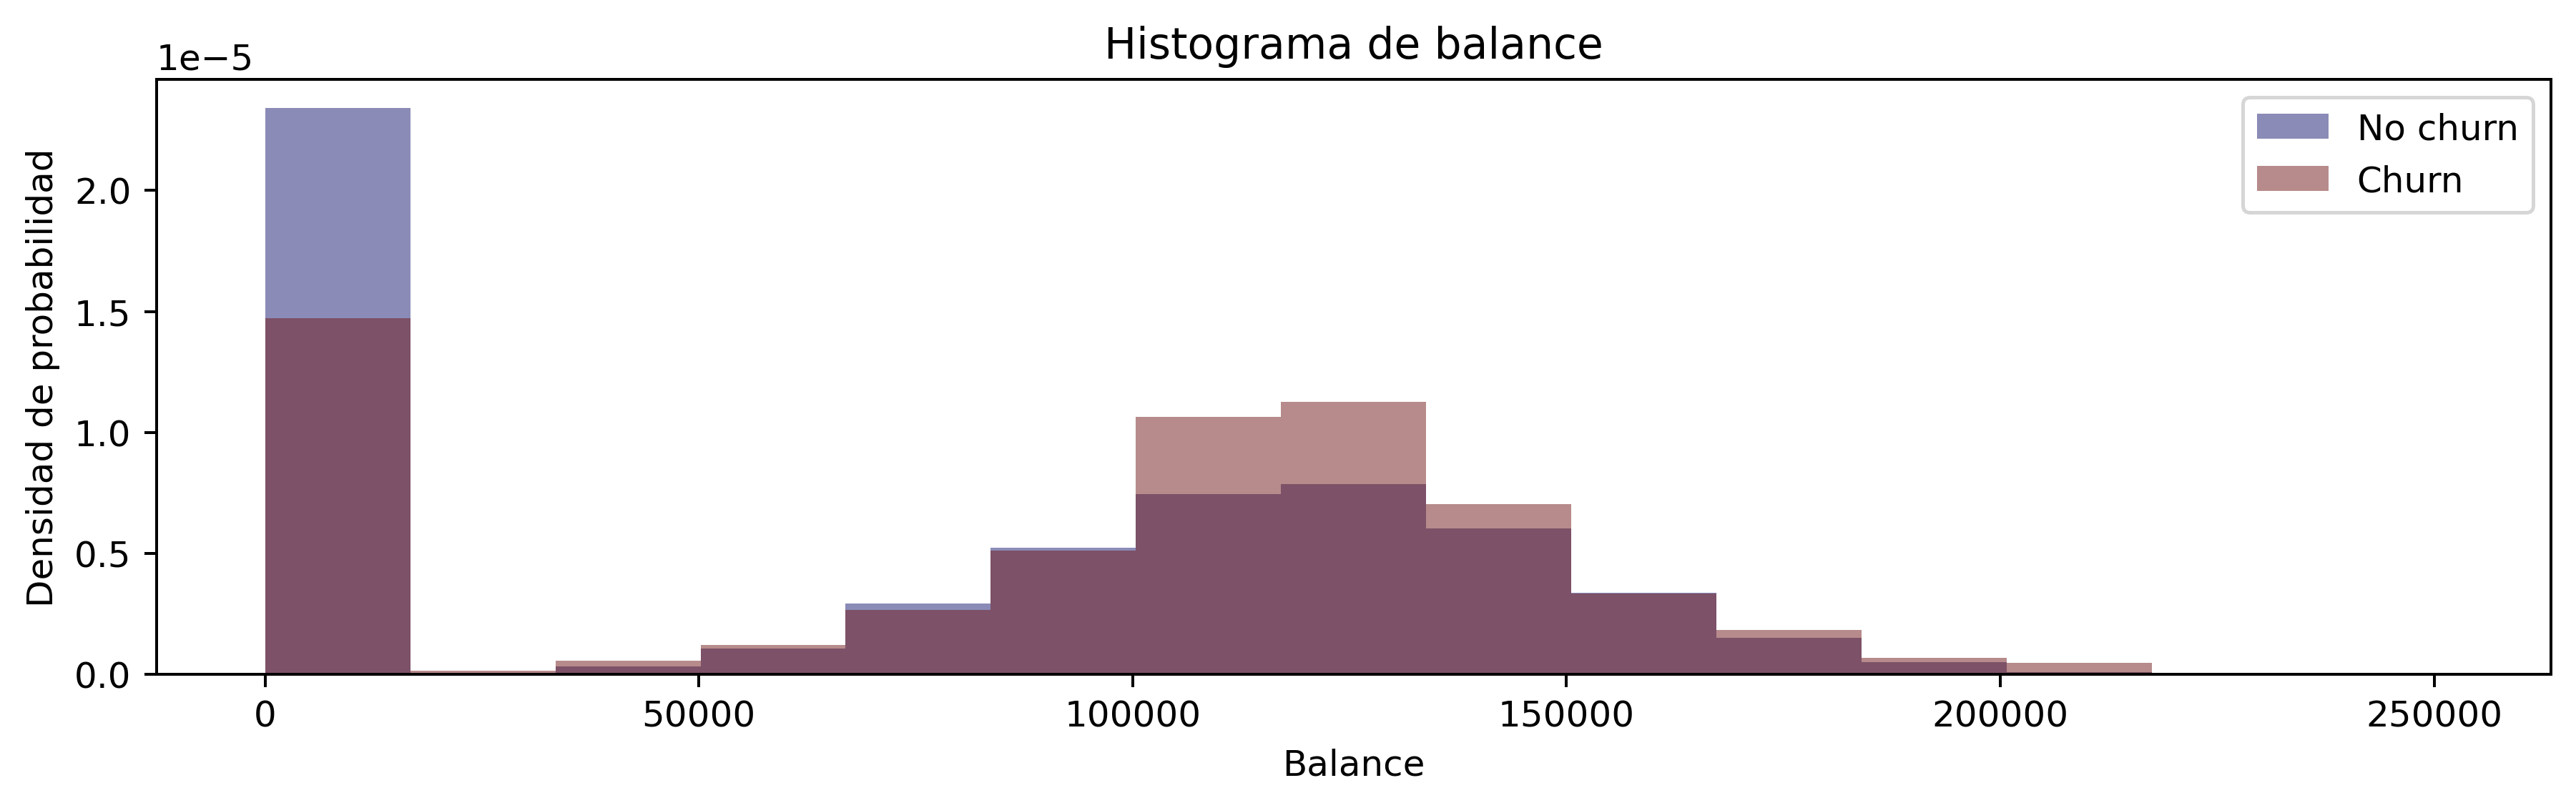

In [16]:
plt.figure(dpi = 360, figsize = (12,3))
plt.hist(df_NoChurn['balance'], bins = 15, color = churn_colors[0], range = [min_balance, max_balance], label = 'No churn', density = True, alpha =0.5)
plt.hist(df_Churn['balance'],   bins = 15, color = churn_colors[1], range = [min_balance, max_balance], label = 'Churn', density = True, alpha = 0.5)
plt.legend()
plt.xlabel("Balance")
plt.ylabel("Densidad de probabilidad")
plt.title('Histograma de balance')
plt.show()

Con esta gráfica se pueden realizar las siguientes observaciones:
* La distribución central de datos es parecida para ambas clases.
* Existe una gran cantidad de clientes con un saldo de $\$0$ en sus cuentas, siendo mayor el porcentaje de clientes que permanecen en la institución que el que abandona.

Como análisis adicional, se graficará la distribución de la variable `balance` considerando solo aquellos clientes que tienen un saldo mayor a $0 en sus cuentas.

In [17]:
NonZeroBalance_NoChurn = df_NoChurn[df_NoChurn['balance'] > 0]['balance']
NonZeroBalance_Churn = df_Churn[df_Churn['balance'] > 0]['balance']

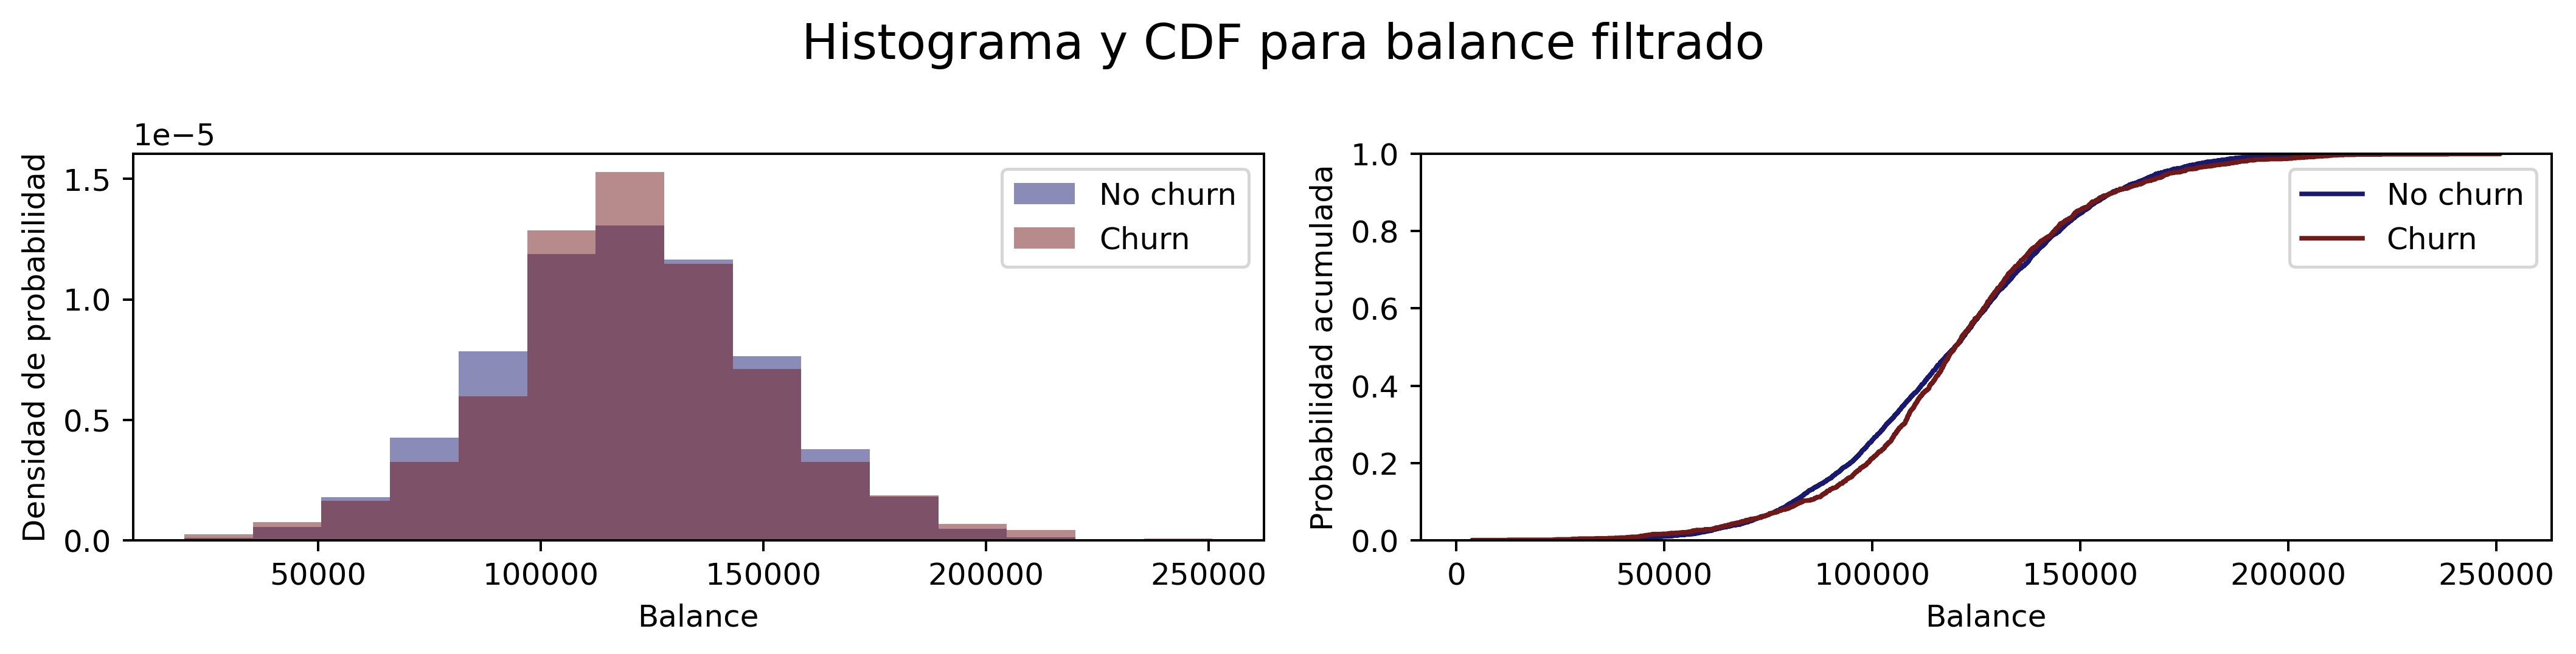

In [18]:
fig, axs = plt.subplots(nrows=1, ncols=2, dpi=360, figsize=(12, 3))
fig.suptitle('Histograma y CDF para balance filtrado', fontsize = 16)
axs[0].hist(NonZeroBalance_NoChurn, bins=15, color=churn_colors[0], range=[20000, max_balance], label="No churn",  density = True, alpha = 0.5)
axs[0].hist(NonZeroBalance_Churn, bins=15, color=churn_colors[1], range=[20000, max_balance], label="Churn",  density = True, alpha = 0.5)
axs[0].set_xlabel("Balance")
axs[0].set_ylabel("Densidad de probabilidad")
axs[0].legend()
sns.ecdfplot(NonZeroBalance_NoChurn, ax=axs[1], color=churn_colors[0], label="No churn")
sns.ecdfplot(NonZeroBalance_Churn, ax=axs[1], color=churn_colors[1], label="Churn")
axs[1].set_xlabel("Balance")
axs[1].set_ylabel("Probabilidad acumulada")
axs[1].legend()
plt.tight_layout()
plt.show()


La gráfica de histograma y de la función de distribución acumulada para la variable `balance` muestran que las distribuciones son similares entre los clientes que abandonan y los que permanecen en la institución. Esto sugiere que, entre clientes que tienen un saldo mayor a $\$0$, no hay diferencias significativas en el comportamiento financiero que permitan distinguir a los clientes según su decisión de permanecer o abandonar la institución. Con esta observación, se plantea lo siguiente:
- ¿Estadísticamente el porcentaje de clientes que poseen un saldo mayor a $\$0$ es distinto entre clientes que abandonan y permanecen en la institución?

<a name = 'Número_de_productos_por_clase'></a>
#### Número de productos por clase



En las gráficas anteriores, se observó que solo los clientes que habían abandonado la institución contaban con 4 productos, mientras que los que no lo habían hecho tenían a lo más 3 productos. De igual forma, en la gráfica de CDF de `products_number` se observó que alrededor del 70\% de clientes que habían abandodando contaban unicamente con un producto, mientras que un 45\% de los que no habían abandonado tenían sólo un producto. A partir de estas observaciones surgen las siguientes preguntas:

- ¿Existen clientes que abandonaron la institución y que regresaron posteriormente debido a que el banco les ofreció más productos?
- ¿Existen clientes que decidieron abandonar la institución después de solicitar un determinado servicio?
- ¿Existen clientes que poseen un solo producto que han abandonado la institución debido a que esta no les proporciona otras prestaciones?
- ¿Cuáles son los criterios que el banco sigue para asignar una determinada cantidad de productos?

Para tratar de dar respuestas a estas preguntas, se analizarán las distribuciones para distintas variables continuas considerando el número de productos que poseen los clientes.

In [19]:
numerical_vars.remove('products_number')

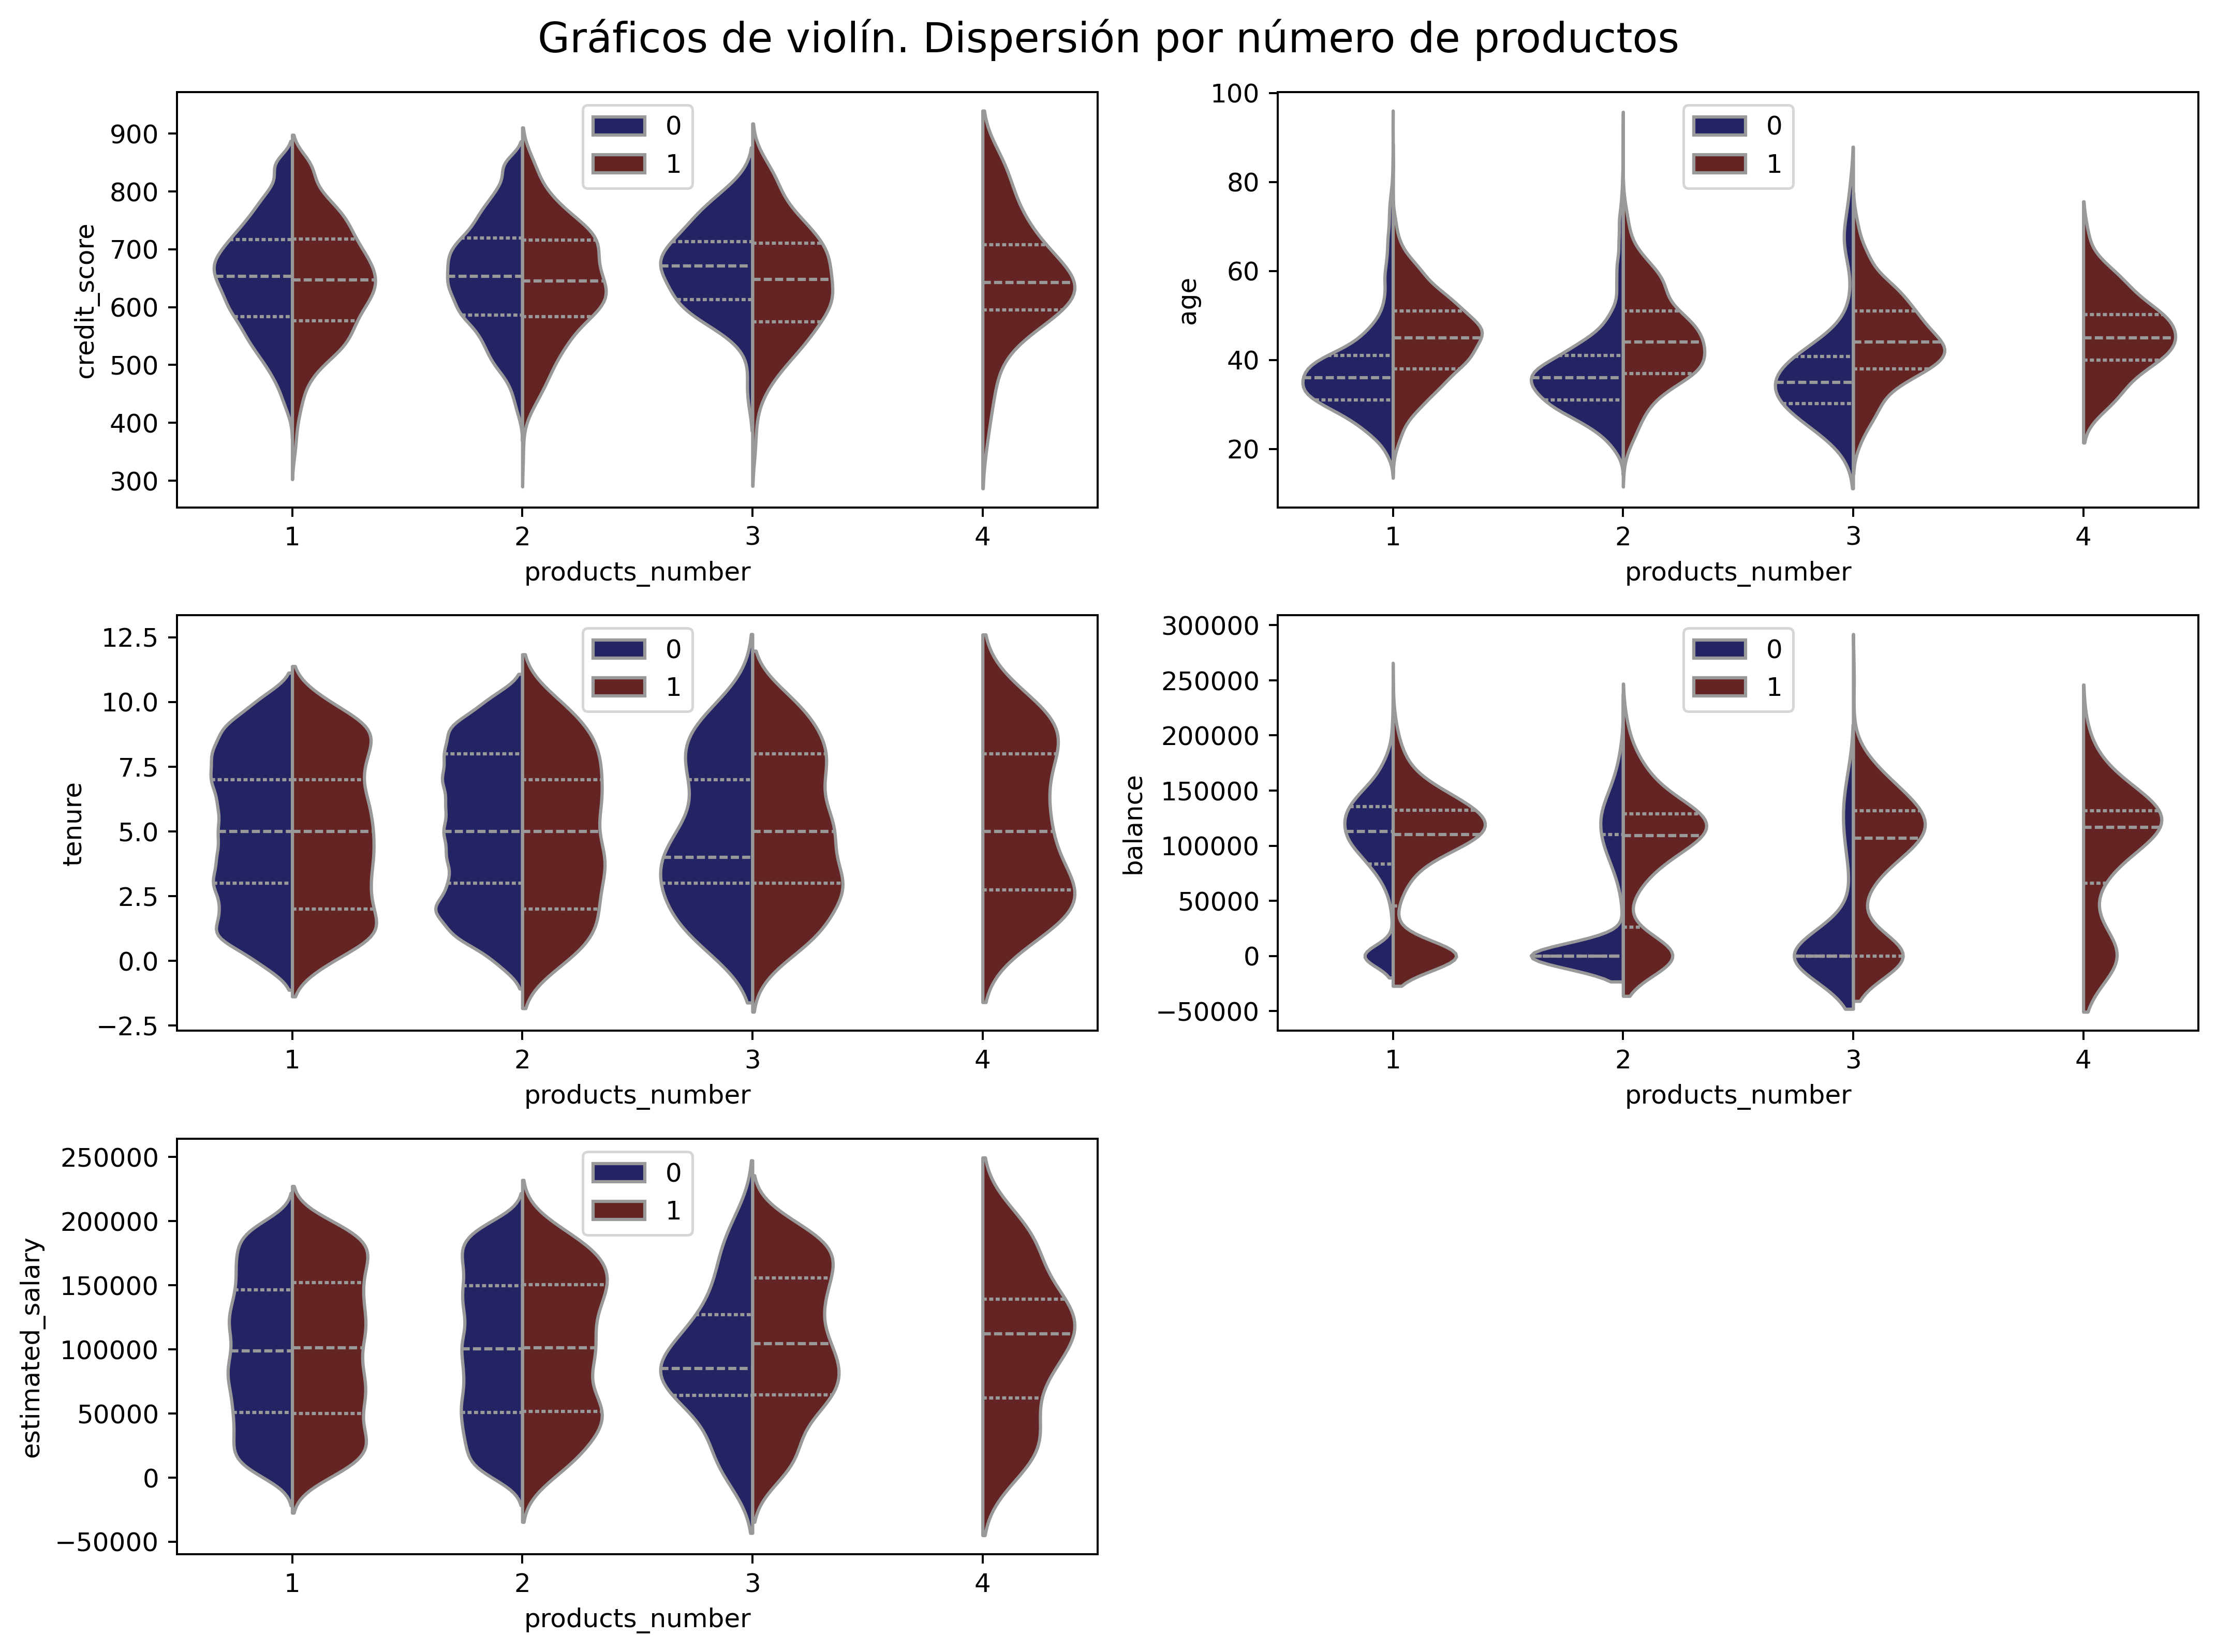

In [20]:
fig, axs = plt.subplots(nrows = 3, ncols = 2, dpi = 360, figsize = (12,9))
fig.suptitle('Gráficos de violín. Dispersión por número de productos', fontsize = 16)
for i, var in enumerate(numerical_vars):
    row, col = divmod(i,2)
    sns.violinplot(data=df, y=var, hue ='churn' , x = 'products_number',
                   palette=churn_colors, split=True, inner='quart', fill = True, linecolor = '#999999', ax = axs[row, col])
    axs[row][col].set_ylabel(var)
    axs[row][col].legend(loc = 'upper center')
fig.delaxes(axs[2, 1])
plt.tight_layout()
plt.show()

A partir de estas gráficas, se pueden realizar las siguientes observaciones:
* Todos los clientes que poseen 4 productos son clientes que han abandonado la institución en algún momento.
* La variable `credit_score` parece no tener relevancia para la asignación del número de productos.
* La variable `age` parece no tener relevancia para la asignación del número de productos.
* En la variable `tenure` se observa una asignación considerable de 3 productos en aquellos clientes que poseen menos años de antiguedad y que no han abandonado la institución. Por su parte, la asignación de productos para los clientes que han abandonado parece no tener cambios según los años de antiguedad de estos.
* En la variable `balance`se observa que los clientes que no han abandonado la institución poseen más productos si tienen menor saldo en sus cuentas, lo cual no ocurre con los clientes que han abandonado. Además, se observa que mientras más productos posee un cliente que ha abandonado la institución y que no tiene saldo en su cuenta, menor es la proporción de clientes que abandonan con respecto al total de los clientes que han abadonado y que poseían ese mismo número de productos.
* La variable `estimated_salary`  parece no tener relevancia para la asignación del número de productos.

En principio, no es posible determinar variables indicadoras para determinar la posesión de una cantidad de productos. Lo unico relevante de este análisis es que existe una gran deserción de clientes con un sólo producto y que la mayoría de clientes que no han abandonado, y que tienen saldo $\$0$ poseen gran cantidad de productos.

*Se sugiere implementar un modelo que permita determinar cómo se están asignando los numeros de productos ya que, en principio, parecen otorgarse de manera independiente. Además, sería conveniente tener una variable adicional que permita identificar que clientes abandonan la institución y posteriormente se vuelven a incorporar. Se sugiere el uso de variables binarias para determinar si el cliente tiene un servicio en especifico en lugar de número de productos*

<a name = 'Análisis_de_variables_categóricas'></a>
### Análisis de variables categóricas

Una vez analizadas las variables continuas, se analizarán las distribuciones de los datos con las variables categóricas mostradas anteriormente.

In [21]:
categorical_vars = ['country', 'gender', 'credit_card', 'active_member']

<a name = 'Gráficas_de_barras'></a>
#### Gráficas de barras

Se graficará una figura de barras para cada una de las clases en las distintas variables categóricas, lo cual permitirá analizar la distribución de datos.

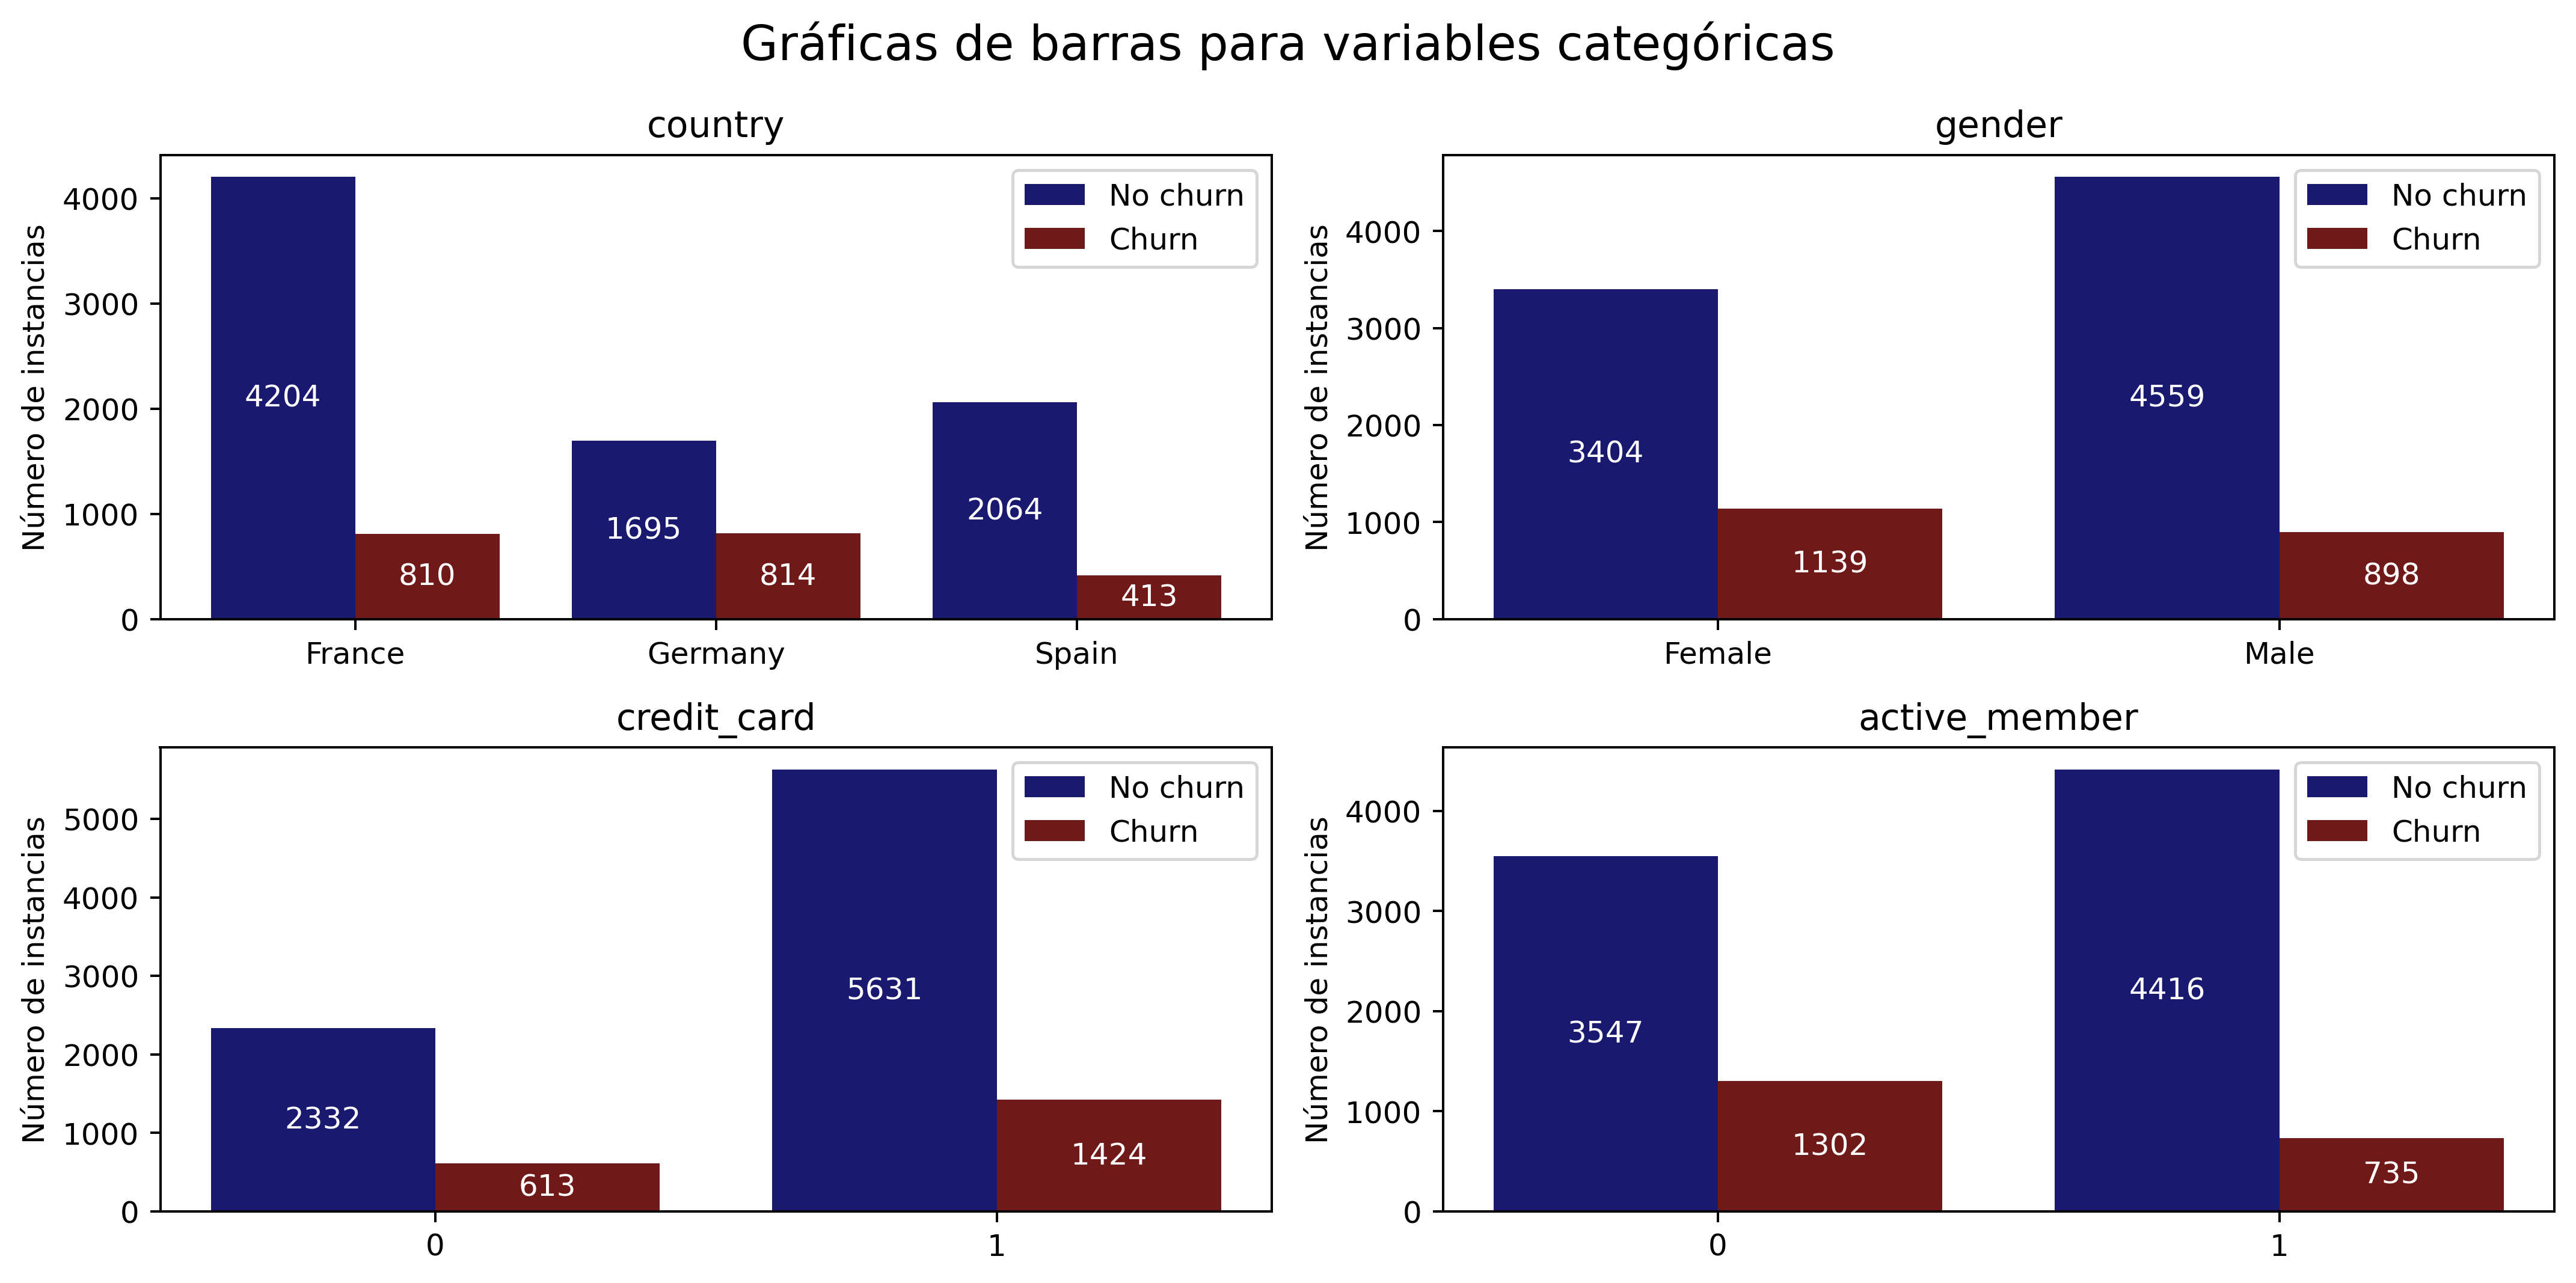

In [22]:
width = 0.4
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (12,6), dpi = 360)
for i, var in enumerate(categorical_vars):
    row, col = divmod(i,2)
    classes = np.sort(df[var].unique()).tolist()
    data = np.zeros(len(classes))
    x_pos = np.arange(len(classes))
    for churn in range(2):
        for j, label in enumerate(classes):
            data[j] = ((df[var]==label) & (df['churn']==churn)).sum()
        offset = width * churn
        label_churn = 'Churn' if churn else 'No churn'
        p = axs[row,col].bar(x_pos + offset, data, width, label = label_churn, color = churn_colors[churn])
        axs[row, col].bar_label(p, fmt='%.0f', label_type='center', color = 'White')
    axs[row,col].set_title(var)
    axs[row,col].set_ylabel('Número de instancias')
    axs[row,col].set_xticks(x_pos + width/2, classes)
    axs[row,col].legend()
plt.suptitle('Gráficas de barras para variables categóricas', fontsize = 16)
plt.tight_layout()
plt.show()

De igual forma a como se realizó con las variables continuas, a partir de las gráficas de barras se extraerán algunas observaciones relevantes sobre el comportamiento de los clientes que abandonan o permanecen en la institución financiera. A continuación, se presentan los principales hallazgos junto con preguntas que permitirán realizar un análisis estadístico posterior:

**Diferencias por país de origen:** A pesar de que la mayor cantidad de clientes provienen de Francia, se observa una misma proporción de abandono y permanencia que en España (aproximadamente una relación de abandono 1:5). Sin embargo esto no ocurre para Alemania, teniendo una mayor proporción de clientes que abandonan la institución (aproximadamente una relación 1:2).
* ¿Es posible afirmar estadísticamente que los clientes alemanes suelen abandonar la institución más que los clientes de otros países?
* ¿La tasa de abandono entre clientes de Francia y España es estadísticamente igual entre ellas?

**Variaciones por género:** Si bien, la mayoría de clientes son del género masculino, el porcentaje de hombres que abandonan la institución es menor que el procentaje de mujeres que abandonan.
* ¿Estadísticamente existe una diferencia entre el porcentajes de mujeres y hombres que abandonan?

**Posesión de tarjeta de credito:** Un gran porcentaje de clientes tiene tarjeta de crédito, sin embargo, se debe revisar si las proporciones son similares entre clientes que tienen y abandonan la institución y clientes que no tienen y no abandonan la institución.
* ¿Estadísticamente las proporciones son distintas para la variable de `credit_card`?

**Actividad y abandono:** Los clientes que se consideran activos poseen un bajo porcentaje de abandono, por el contrario, los clientes que no son considerados activos tienen una mayor tendencia al abandono, a pesar de que el conjunto 'No activo' es menor.
* ¿Es la variable de actividad útil para predecir si un cliente abandonará o no la institución?

<a name = 'Gráficas_de_barras_apilada'></a>
#### Gráficas de barras apiladas

Para poder descubrir patrones y factores que permitan identificar el abandono de clientes en las distintas varibles de manera visual, se realizarán gráficas de barras apiladas las cuales permitirán observar las diferencias entre las proporciones de distintas variables en las diferentes clases.

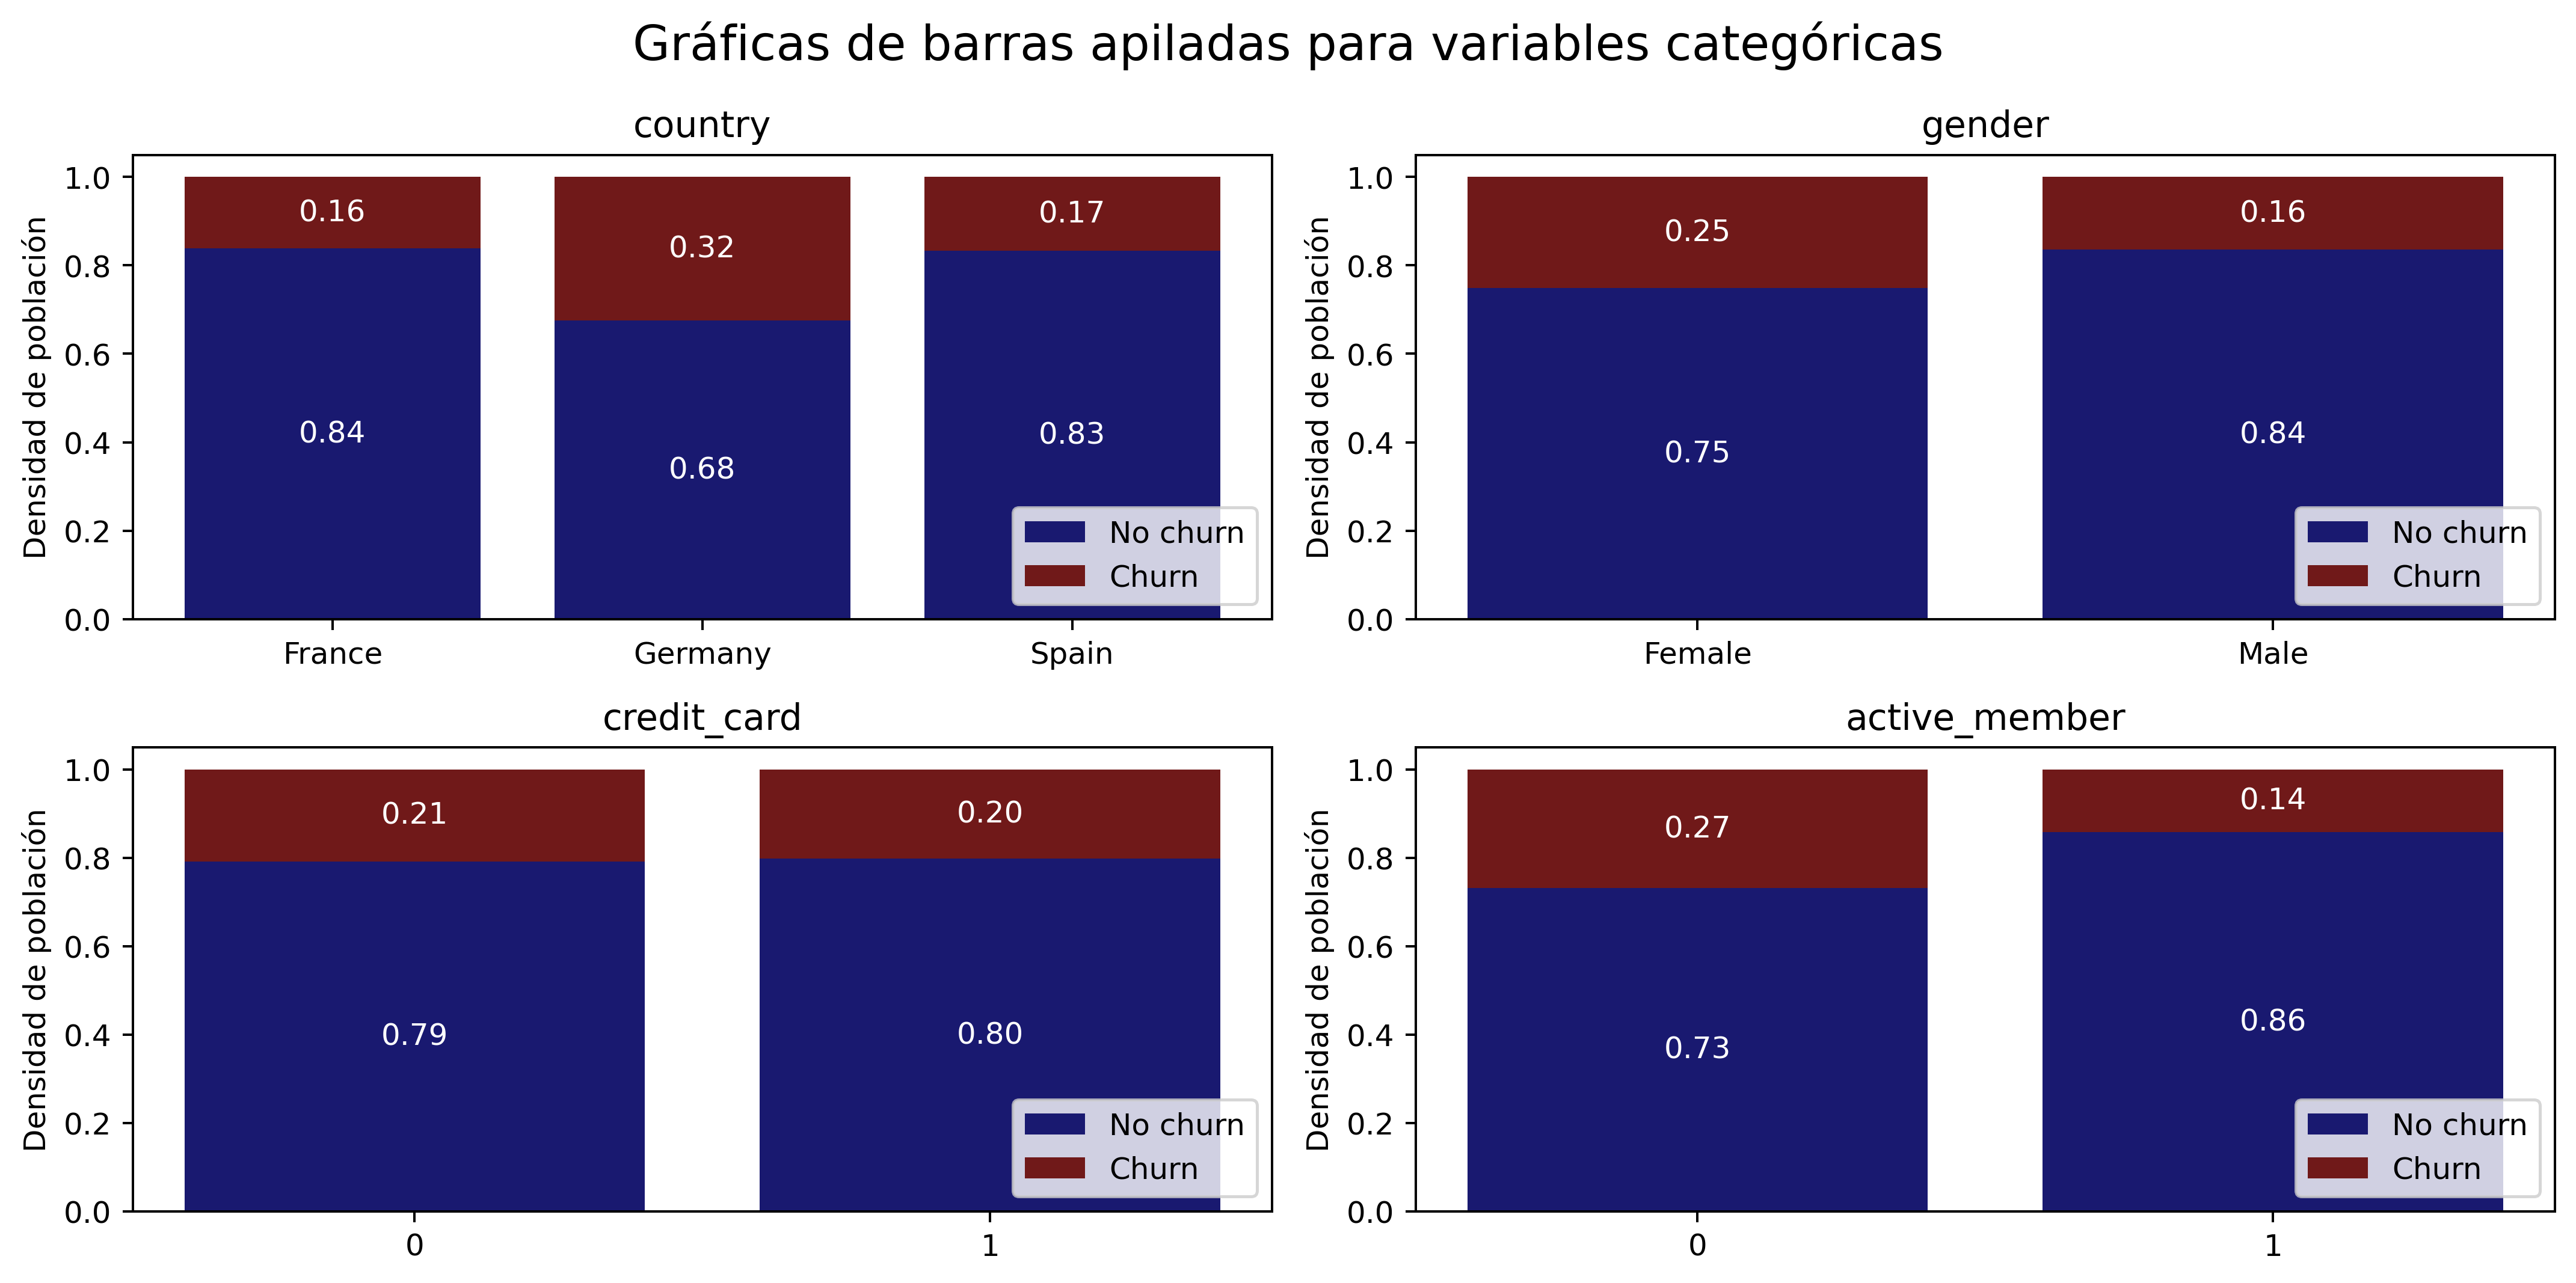

In [23]:
width = 0.8

fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (12,6), dpi = 360)
for i, var in enumerate(categorical_vars):
    row, col = divmod(i,2)
    classes = np.sort(df[var].unique()).tolist()
    data = np.zeros((2, len(classes)))
    x_pos = np.arange(len(classes))
    bottom = np.zeros(len(classes))
    for j, label in enumerate(classes):
        data[0,j] = ((df[var]==label) & (df['churn']==0)).sum()
        data[1,j] = ((df[var]==label) & (df['churn']==1)).sum()
    data = data/data.sum(axis = 0)
    for j in range(2):
        label_churn = 'Churn' if j else 'No churn'
        p = axs[row,col].bar(x_pos, data[j,:], width, label = label_churn, color = churn_colors[j], bottom = bottom)
        bottom += data[j,:]
        axs[row, col].bar_label(p, fmt='%.2f', label_type='center', color = 'White')
    axs[row,col].set_title(var)
    axs[row,col].set_ylabel('Densidad de población')
    axs[row,col].set_xticks(x_pos, classes)
    axs[row,col].legend(loc="lower right")
plt.suptitle('Gráficas de barras apiladas para variables categóricas', fontsize = 16)
plt.tight_layout()
plt.show()

Con estas gráficas se pueden observar como se distribuyen las proporciones de clases en las distintas variables, lo que permite realizar las siguientes observaciones:
- Se observa que la mayor proporción de clientes que abandonan son clientes de Alemania, mientras que la proporción de Francia y España es similar entre estas y menor a las de Alemania.
- Se observa que las mujeres tienden a abandonar más la institución bancaria que los hombres.
- Parece ser que poseer tarjeta de credito no afecta la permanencia de clientes.
- La proporción de clientes que abandonan es más grande en los clientes inactivos que activos.

Si bien, es posible destacar estos patrones de manera visual, es necesario realizar un análisis estadístico que valide dichas afirmaciones. Estas pruebas estadísticas se realizarán en las siguientes secciones.

<a name = 'Resumen_de_análisis_exploratorio'></a>
### Resumen de análisis exploratorio preliminar

A continuación, se presenta un resumen de los principales *insights* encontrados a partir del análisis exploratorio:
1. Se observa una similitud entre las distribuciones de clases para las variables `credit_score`, `tenure` y `estimated_salary`
2. La media de edad de las personas que abandonan es mayor a la media de edad de las personas que permanecen.
3. Existe una gran concentración de personas con un saldo de $\$0$ en sus cuentas, así mismo, los clientes que tienen este saldo muestran un mayor porcentaje de permanencia. Por otro lado, para quienes tienen un saldo mayor a $\$0$ parece no existir diferencias en la distribución.
4. Solo las personas que han abandonado poseen 4 productos, mientras que aquellos clientes que permanecen y tienen $0 en su cuenta tienden a
tener más productos. Se observa que un gran porcentaje de clientes que abandonan tienen un solo producto. *Como sugerencia para implementación a
futuro debe considerarse utilizar esta variable como categórica para idetificar los productos que el cliente posee y revisar de mejor manera las tendencias. También se sugiere implementar una nueva variable que permita identificar si el cliente a abandonado y regresado a la institución*.
5. Se observa una mayor tendencia de abandono por parte de clientes alemanes que de otros países.
6. La tasa de abandono es más alta en el género femenino que masculino.
7. Alrededor del 70\% de clientes poseen tarjeta de credito. No es posible marcar una tendencia clara con esta variable.
8. Los clientes considerados como inactivos suelen tener una tasa de abandono más alta.	 

<a name='Partición_de_datos'></a>
## Partición de datos

Dado que los datos se encuentran desbalanceados, es necesario realizar una partición estratificada. Para ello, se utilizará la implementación `train_test_split`de *sklearn*, utilizando una partición 80-20.

In [24]:
from sklearn.model_selection import train_test_split

SEED = 123
np.random.seed(SEED)

X = df.drop(columns = ['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)

_______

<a name='Pruebas_estadísticas'></a>
## Pruebas estadísticas

Como se mencionó en el análisis exploratorio, es necesario realizar algunas pruebas estadísticas sobre los datos para validar hipotesis y describir variables que sirvan para predecir el abandono de clientes. Para ello, se utilizará el conjunto de entrenamiento. Las pruebas estadísticas se harán con una significancia del 5%. 

Además, para realizar las pruebas estadísiticas, se dividirá el conjunto de datos en dos subconjuntos: clientes que han abandonado y clientes que no han abandonado la institución.

In [25]:
X_NoChurn= X_train[y_train == 0]
X_Churn = X_train[y_train == 1]

<a name = 'Similitud_en_distribución'></a>
### Similitud en distribución: Kolmogorov-Smirnov de dos muestras

Se empezará realizando la prueba de *kolmogorov-Smirnov* para comparar las *distribuciones* de los datos para las distintas variables numéricas.

Se propone como hipotesis nula H0 que no existe diferencia significativa entre las distribuciones para clientes que han abandonodo y que permancen en la institución para la variable analizada.

In [26]:
print('-----Prueba Kolmogorov-Smirnov de dos muestras-----')
for var in numerical_vars:
    res = stats.ks_2samp(X_NoChurn[var], X_Churn[var])
    print(f"{var}: p-value = {res.pvalue:.4f}")

-----Prueba Kolmogorov-Smirnov de dos muestras-----
credit_score: p-value = 0.0071
age: p-value = 0.0000
tenure: p-value = 0.1076
balance: p-value = 0.0000
estimated_salary: p-value = 0.6952


Con lo anterior, se obtiene que estadísticamente no hay diferencia significativa entre la distribución de datos de `tenure` y `estimated_salary` entre clientes con y sin abandono. Las demás variables numéricas sí presentan diferencias significativas entre las distribuciones de datos para los dos tipos de clientes.

<a name = 'Tendencia_de_valores'></a>
### Tendencias de valores: Mann-Whitney U

Una prueba no paramétrica para analizar si dos conjuntos de datos presentan una *tendencia* estadisticamente distinta, es la prueba de *Mann-Whitney U*. Esta prueba no es la alternativa no paramétrica de la prueba t, sin embargo, puede ser utilizado de manera aproximada. 

Se establece como hipótesis nula H0 que la tendencia entre los dos grupos para una determinada variable es la misma. Implementando esta prueba para cada una de las variables numéricas se obtiene lo siguiente:

In [27]:
print('-----Prueba Mann–Whitney U-----')
for var in numerical_vars:
    res = stats.mannwhitneyu(X_NoChurn[var], X_Churn[var])
    print(f"{var} p-value = {res.pvalue:.4f}")

-----Prueba Mann–Whitney U-----
credit_score p-value = 0.0053
age p-value = 0.0000
tenure p-value = 0.0371
balance p-value = 0.0000
estimated_salary p-value = 0.4385


La prueba de *Mann-Whitney U* indica que no existe diferencias significativas en las tendencias de los datos para la variable `estimated_salary`. Por su parte, las demás variables sí presentan una tendencia significativamente diferente entre los dos grupos.

<a name = 'Saldo_en_cuentas_de_clientes'></a>
### Saldo en cuentas de clientes

<a name = 'Clientes_con_saldo_en_cuenta'></a>
#### Clientes con saldo en cuenta

Como se mencionó en el análisis exploratorio, existe una gran concentración de clientes que poseen $\$0$ en sus cuentas, siendo mayor la proporción de clientes que permanecen que los que abandonan. Al filtrar los clientes que tienen saldo en su cuenta, se encontró que la distribución entre grupos era casi normal y muy parecida entre sí. Es por ello que se desea saber si la media, y en general, las distribuciones de los clientes que tienen saldo en sus cuentas es distinta entre las dos clases. 

Se realiza el filtrado de datos y se obtienen los clientes que sí tienen saldo en sus cuentas:

In [28]:
X_NonZero_NoChurn = X_NoChurn[X_NoChurn['balance']>0]['balance']
X_NonZero_Churn = X_Churn[X_Churn['balance']>0]['balance']

Para comparar las medias, se debe revisar si el conjunto de datos sigue una distribución normal. Para ello, se realizará una prueba de Shapiro.

Se propone como H0 que los datos siguen una distribución normal. 

In [29]:
res_NoChurn = stats.shapiro(X_NonZero_NoChurn)
res_Churn = stats.shapiro(X_NonZero_Churn)
print('-----Prueba Shapiro para normalidad-----')
print(f'p-value para balance de clientes que permanecen: {res_NoChurn.pvalue:.4f}')
print(f'p-value para balance de clientes que abandonan: {res_Churn.pvalue:.4f}')

-----Prueba Shapiro para normalidad-----
p-value para balance de clientes que permanecen: 0.8429
p-value para balance de clientes que abandonan: 0.0000


Dado que los dos grupos no siguen una distribución normal, es necesario aplicar una prueba no paramétrica. Debido a esto, se utilizarán las pruebas anteriormente aplicadas para comparar la distribución y tendencia del saldo entre las clases. 

Se establece como hipotesis nula H0 que no existe diferencia significativa entre la distribución y tendencia del balance de clientes con saldo en sus cuentas que abandonan y permanecen.

In [30]:
res = stats.ks_2samp(X_NonZero_NoChurn, X_NonZero_Churn)
print(f"KS: p-value = {res.pvalue:.4f}")
res = stats.mannwhitneyu(X_NonZero_NoChurn, X_NonZero_Churn)
print(f"MWU: p-value = {res.pvalue:.4f}")

KS: p-value = 0.0022
MWU: p-value = 0.1156


Como se puede observar, los datos tienen una distribución significativamente distinta (prueba Kolmogorov-Smirnov), mientras que la tendencia parece no ser significativamente distinta (prueba Mann-Whitney U).

Para comparar esto visualmente, se graficará el histograma y la función de distribución de probabilidad. (Nota: esto ya se había realizado en la [relación entre saldo y abandono](#Relación_entre_saldo_y_abandono), sin embargo, ahora se realiza sólo sobre el conjunto de entrenamiento).

In [31]:
n = X_Churn.shape[0] + X_NoChurn.shape[0]

n_bins = 1+ np.log2(n) #Regla de Sturges y redondeo
if 0.5 > n_bins - np.floor(n_bins):
    n_bins = int(np.floor(n_bins))
else:
    n_bins = int(np.ceil(n_bins))
    
min_train_balance = X_train['balance'].min()
max_train_balance = X_train['balance'].max()

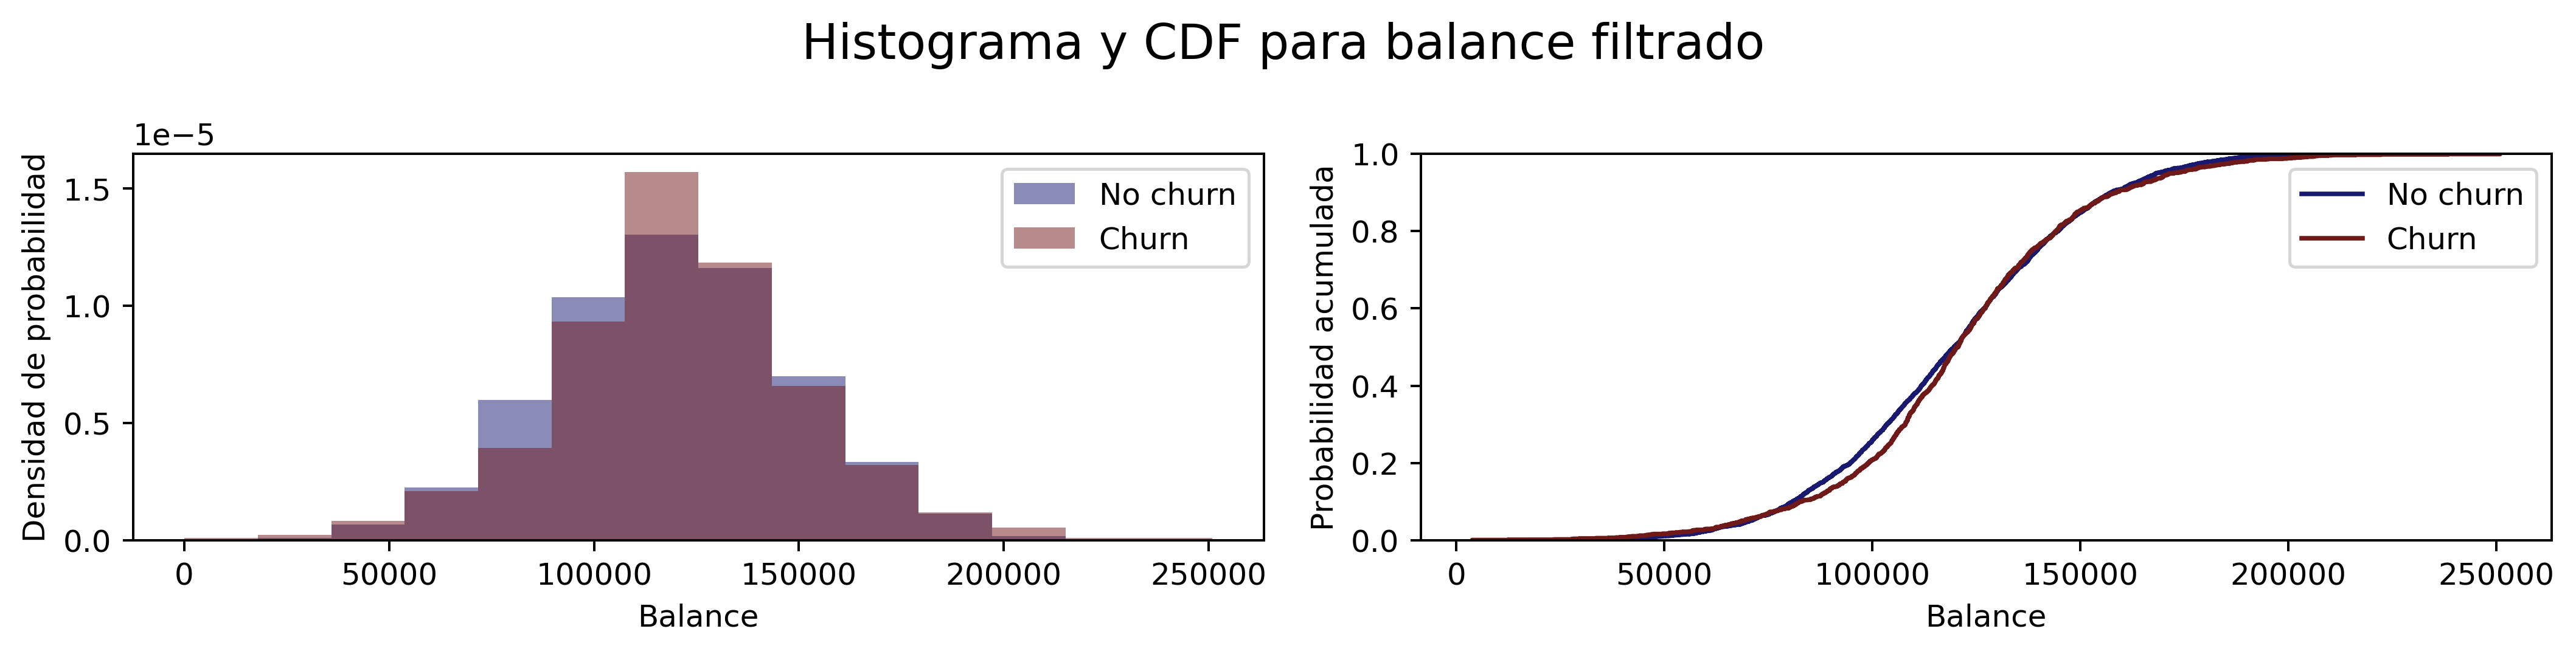

In [32]:
fig, axs = plt.subplots(nrows=1, ncols=2, dpi=360, figsize=(12, 3))
fig.suptitle('Histograma y CDF para balance filtrado', fontsize = 16)
axs[0].hist(X_NonZero_NoChurn, bins=n_bins, range=[min_train_balance, max_train_balance], density = True,
            label="No churn", color=churn_colors[0], alpha = 0.5)
axs[0].hist(X_NonZero_Churn,   bins=n_bins, range=[min_train_balance, max_train_balance], density = True,
            label="Churn", color=churn_colors[1], alpha = 0.5)
axs[0].set_xlabel("Balance")
axs[0].set_ylabel("Densidad de probabilidad")
axs[0].legend()
sns.ecdfplot(X_NonZero_NoChurn, ax=axs[1], color=churn_colors[0], label="No churn")
sns.ecdfplot(X_NonZero_Churn, ax=axs[1], color=churn_colors[1], label="Churn")
axs[1].set_xlabel("Balance")
axs[1].set_ylabel("Probabilidad acumulada")
axs[1].legend()
plt.tight_layout()
plt.show()

Como se puede observar, el histograma muestra la tendencia central de los datos, los cuales se encuentran centrados en el intervalo entre $\$100000$ y $\$140000$. Por otro lado, la gráfica CDF presenta diferencias mínimas entre las distribuciones de los datos. Debido a que no es muy clara la diferencia entre los datos, considerar clientes con un saldo mayor a 0 no permite separar correctamente las clases.

<a name = 'Clientes_sin_saldo_en_cuenta'></a>
#### Clientes sin saldo en cuenta

Ahora, es momento de analizar si existen diferencias significativas entre el número de clientes que poseen un saldo de $\$0$ en sus cuentas. Para ello, se realizará una prueba $Z$ para proporciones. Para esto, se define la función `z_proportions`.

In [33]:
def z_proportions(n1, n2, x1,x2):
    p = (x1 + x2)/(n1+n2)
    p1 = x1/n1
    p2 = x2/n2
    Z = (p1-p2)/np.sqrt(p*(1-p)*(1/n1+1/n2))
    pvalue = 2*stats.norm.sf(abs(Z))
    res = {'statistics': Z,
            'pvalue': pvalue}
    return res

Para realizar esta prueba, se seleccionan las instancias que cumplen una determinada condición, en este caso, se seleccionan los $x_i$ clientes que no tienen saldo, es decir, tienen un total de $\$0$ en cuenta, para cada una de las $i$ clases (permanencia y abandono). Es necesario comparar el total de instancias por clase con respecto al tamaño $n_i$ de su respectiva clase.

Para esta prueba, se toma como hipotesis nula H0 que no existen diferencias significativas entre las proporciones de ambos grupos.

In [34]:
n1, n2= X_NoChurn.shape[0], X_Churn.shape[0]
x1, x2 = (X_NoChurn['balance']==0).sum(), (X_Churn['balance']==0).sum()

res = z_proportions(n1,n2,x1,x2)
print(f"pvalue: {res['pvalue']:.4f}")

pvalue: 0.0000


Dado que el pvalue es menor, se concluye que sí existen diferencias significativas entre las proporciones de clientes que tienen un saldo de $\$0$ para aquellos que abandonan o permanecen. Debido a esto, se agregará una variable categórica la cuál permitirá identificar cuando un cliente posea un balance activo o inactivo, la cual se denominará `active_balance`.

In [35]:
X_train['active_balance'] = (X_train['balance'] > 0).astype(int)
X_test['active_balance'] = (X_test['balance'] > 0).astype(int)

X_NoChurn= X_train[y_train == 0]
X_Churn = X_train[y_train == 1]

<a name = 'Correlaciones_entre_variables'></a>
### Correlaciones entre variables

Para observar si existen correlaciones entre las distintas variables numéricas, se realizará una grafica de correlaciones para observar patrones en los distintos grupos de clientes.

In [36]:
numerical_vars = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

corr_churn = X_Churn[numerical_vars].corr()
corr_no_churn = X_NoChurn[numerical_vars].corr()

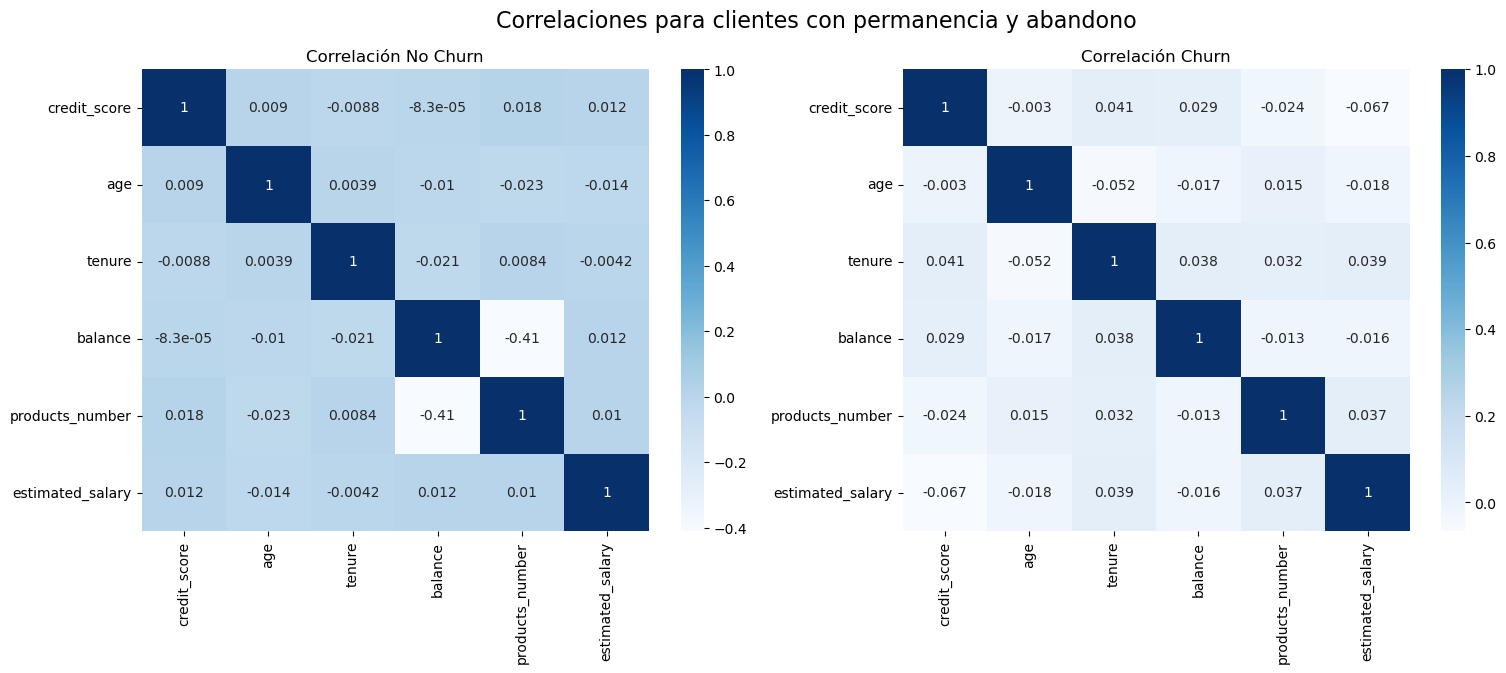

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(18,6))
plt.suptitle('Correlaciones para clientes con permanencia y abandono', fontsize = 16)
sns.heatmap(corr_no_churn, annot=True, cmap='Blues', ax=axs[0])
axs[0].set_title('Correlación No Churn')
sns.heatmap(corr_churn, annot=True, cmap='Blues', ax=axs[1])
axs[1].set_title('Correlación Churn')
plt.show()

Como se puede observar, la única variable que parece estar correlacionada de manera descendente es el número de productos y balance para las personas que no han abandonado. Esta correlación se puede observar en la figura del gráfico de violín donde se presentan las distribuciones por número de productos. Se observa que para el balance existe una asignación mayor de productos para aquellas cuentas que tienen un saldo de $\$0$. Sin embargo, como se mencionó, esto solo ocurre para las personas que no han abandonado. Parece no existir correlaciones claras para las demás variables en clientes que han abandonado. 

<a name = 'Variables_categóricas_discriminantes'></a>
### Variables categóricas discriminantes: Prueba $\chi^2$

Una vez analizadas las distribuciones con las variables numéricas, se analizarán las distribuciones con las variables categóricas, para ello, se analizaran las diferencias entre grupos utilizando la prueba $\chi^2$.

In [38]:
categorical_vars = ['country', 'gender', 'credit_card', 'active_member', 'active_balance']

La prueba $\chi^2$ de independencia permite saber si una variable influye estadísticamente en otra. Para esta prueba se propone como hipótesis nula H0 que el estado del cliente (permanecer o abandonar) es independiente de la variable analizada.

In [39]:
for var in categorical_vars:
    tabla = pd.crosstab(X_train[var], y_train)
    chi2 = stats.chi2_contingency(tabla, correction=(tabla.shape == (2,2)))
    print(f"{var}: pvalue = {chi2.pvalue:.4f}")

country: pvalue = 0.0000
gender: pvalue = 0.0000
credit_card: pvalue = 0.4773
active_member: pvalue = 0.0000
active_balance: pvalue = 0.0000


Los resultados obtenidos indican que sólo `credit_card` es independiente del estado del cliente, mientras que para las demás variable sí existe un grado de dependencia entre que un cliente permanezca o abandone.

<a name = 'Diferencias_en_proporciones'></a>
### Diferencias en proporciones

En la gráfica de barras apiladas, se observó que existían distintas proporciones de abandono para algunas variables categóricas. Se desea saber si las proporciones de clientes que han abandonado el banco son estadísticamente distinto al pertenecer a un conjunto para las distintas variables categóricas.

Se propone como hipótesis nula H0 que no existe diferencia significativa entre la proporción de clientes que han abandonado al pertenecer a una clase u otra para las distintas variables categóricas.

In [40]:
categorical_vars = ['gender', 'credit_card', 'active_member', 'active_balance']

En este caso, se omite la variable `country` dado que esta posee 3 clases.

In [41]:
for var in categorical_vars:
    label0, label1= np.sort(X_train[var].unique())
    
    n0 = (X_train[var]==label0).sum()
    n1 = (X_train[var]==label1).sum()
    x0 = (X_Churn[var]==label0).sum()
    x1 = (X_Churn[var]==label1).sum()
    res = z_proportions(n0, n1, x0,x1)

    print(f"{var}. pvalue: {res['pvalue']:.4f}")

gender. pvalue: 0.0000
credit_card. pvalue: 0.4586
active_member. pvalue: 0.0000
active_balance. pvalue: 0.0000


Como se puede observar, se obtienen resultados parecidos a la pruba $\chi^2$, lo cual fortalece los resultados que la variable `credit_card` no funciona como variable predictora.

En el análisis exploratorio general, se observó que Alemania era el país que más abandonaba. Si bien, es posible realizar una prueba post hoc para determinar en que grupo existe la diferencia, se asumirá que se trata de Alemania. Se desea saber ahora si las proporciones de abandono entre Francia y España es la misma. 

Se asume como hipótesis nula H0 que no existe diferencia significativa en la proporción de clientes que han abandonado la institución y que son originarios de Francia o España.

In [42]:
n0 = (X_train['country'] == "Spain").sum()
n1 = (X_train['country'] == "France").sum()
x0 = (X_Churn['country'] == "Spain").sum()
x1 = (X_Churn['country'] == "France").sum()

res = z_proportions(n0, n1, x0,x1)

print(f"pvalue: {res['pvalue']:.4f}")

pvalue: 0.8990


Como se puede observar, no es posible descartar H0, por lo cual se establece que no existe diferencia significativa en la proporción de clientes que han abandonado entre clientes de Francia y España.

<a name = 'Dependencia_entre_variables_categóricas'></a>
### Dependencia entre variables categóricas: Prueba $\chi^2$

Una relación interesante a analizar son las dependencias entre las distintas variables categóricas, de manera análoga a la correlación que se calculó entre variables numéricas. Para ello, se realizarán pruebas $\chi^2$ para cada una de las variables.

Se establece como H0 que la variable 1 y la variable 2 son estadisticamente independientes.

In [43]:
categorical_vars = ['country', 'gender', 'credit_card', 'active_member', 'active_balance']

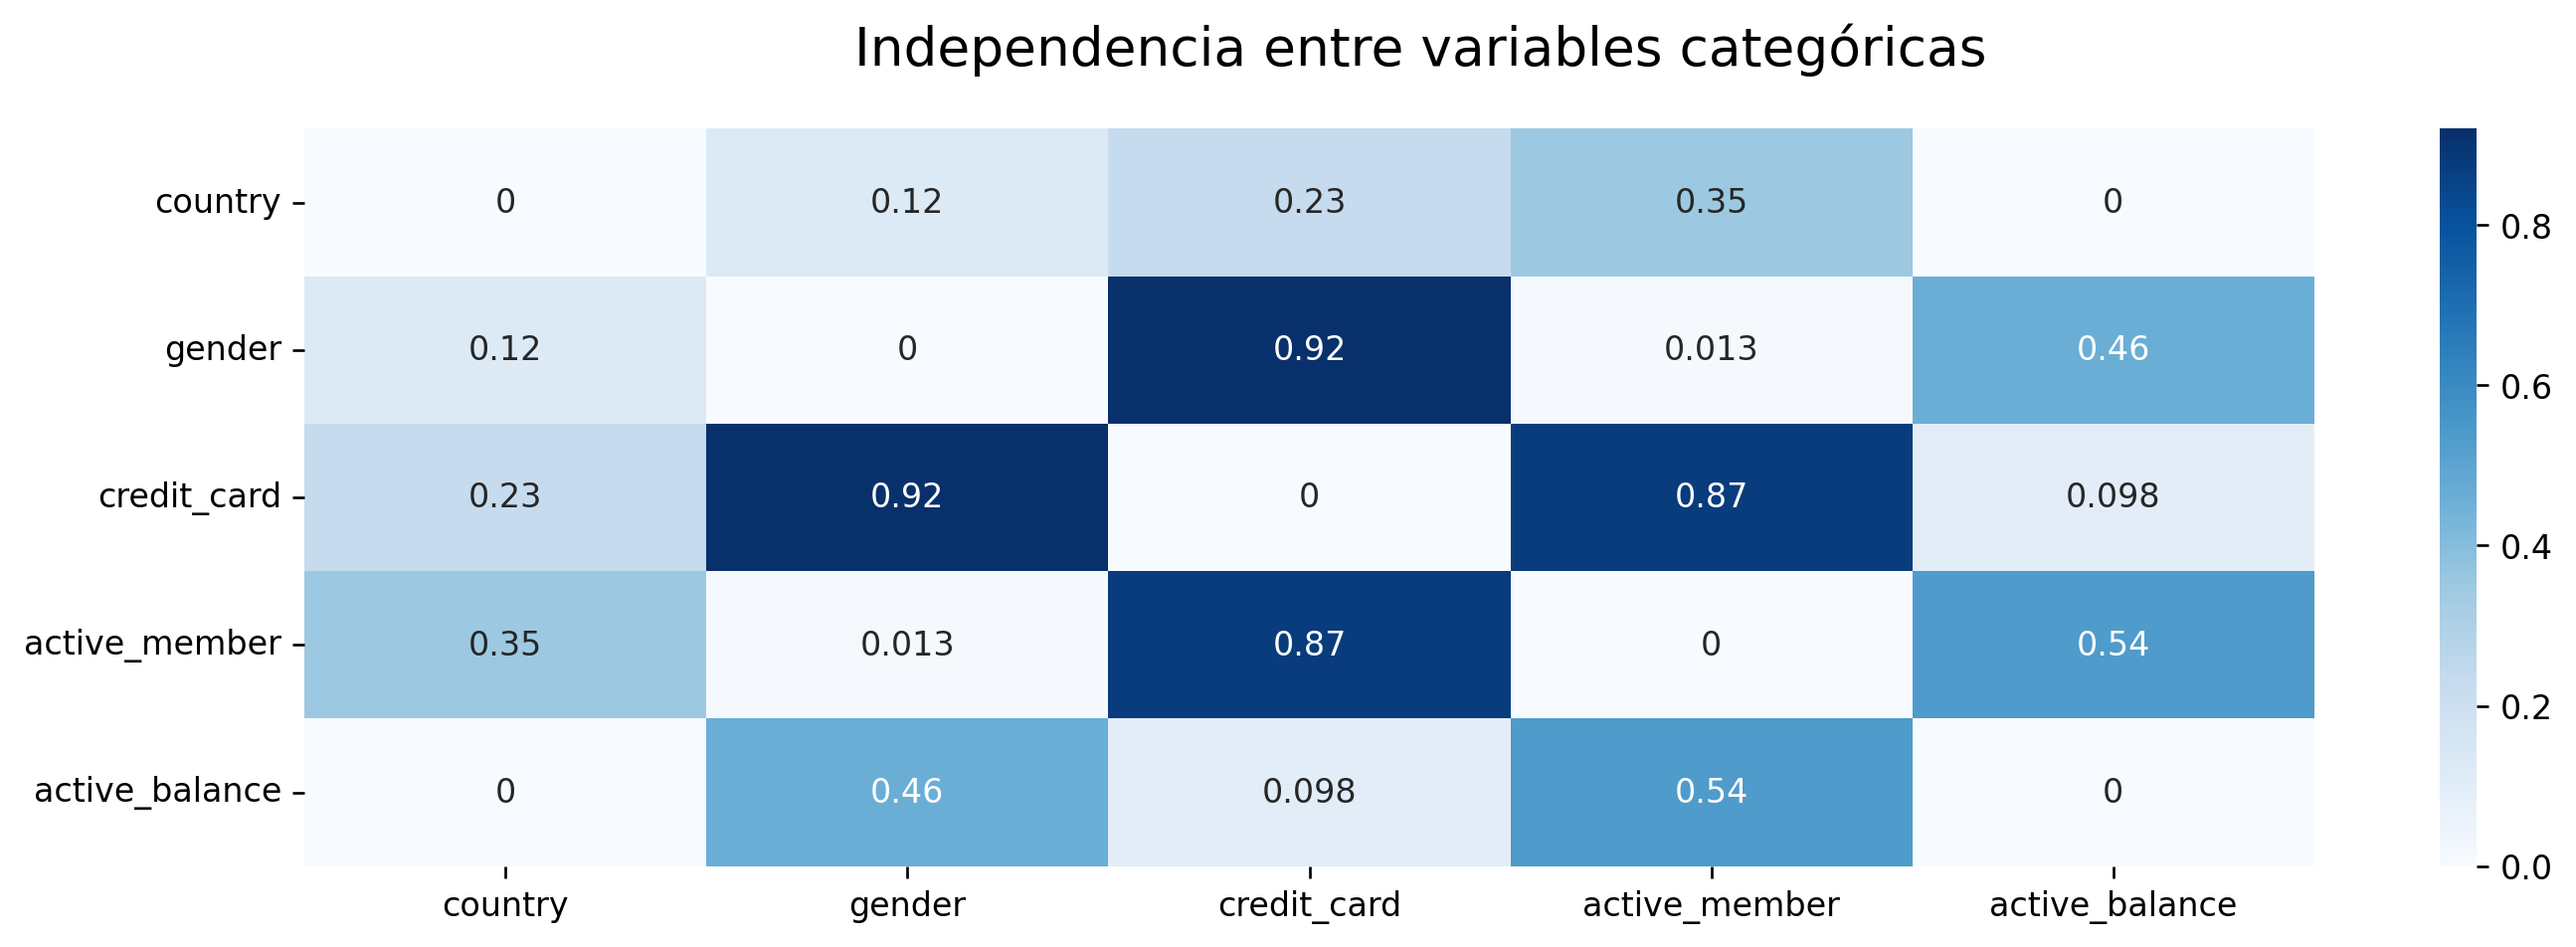

In [44]:
tabla = np.zeros((len(categorical_vars), len(categorical_vars)))

for row, var1 in enumerate(categorical_vars):
    for col, var2 in enumerate(categorical_vars):
        crosstab = pd.crosstab(X_train[var1], X_train[var2])
        chi2 = stats.chi2_contingency(crosstab, correction=True)
        tabla[row, col] = chi2.pvalue

plt.figure(figsize=(12, 4), dpi = 240)
plt.suptitle('Independencia entre variables categóricas', fontsize=16)
sns.heatmap(tabla, annot=True, cmap='Blues', xticklabels=categorical_vars, yticklabels=categorical_vars)
plt.tight_layout()
plt.show()

Con los resultados obtenidos, es posible establecer las siguientes conclusiones:
- Existe una dependencia entre el país y los clientes con un balance activo, lo que indicaría que hay una mayor proporción de clientes que tienen $\$0$ en sus cuentas en distintos países.
- Existe una dependencia entre el género y la variable de miembro activo. Existe un género que es más 'activo' que el otro.

Se graficará en una figura de barras apiladas los *insights* encontrados.

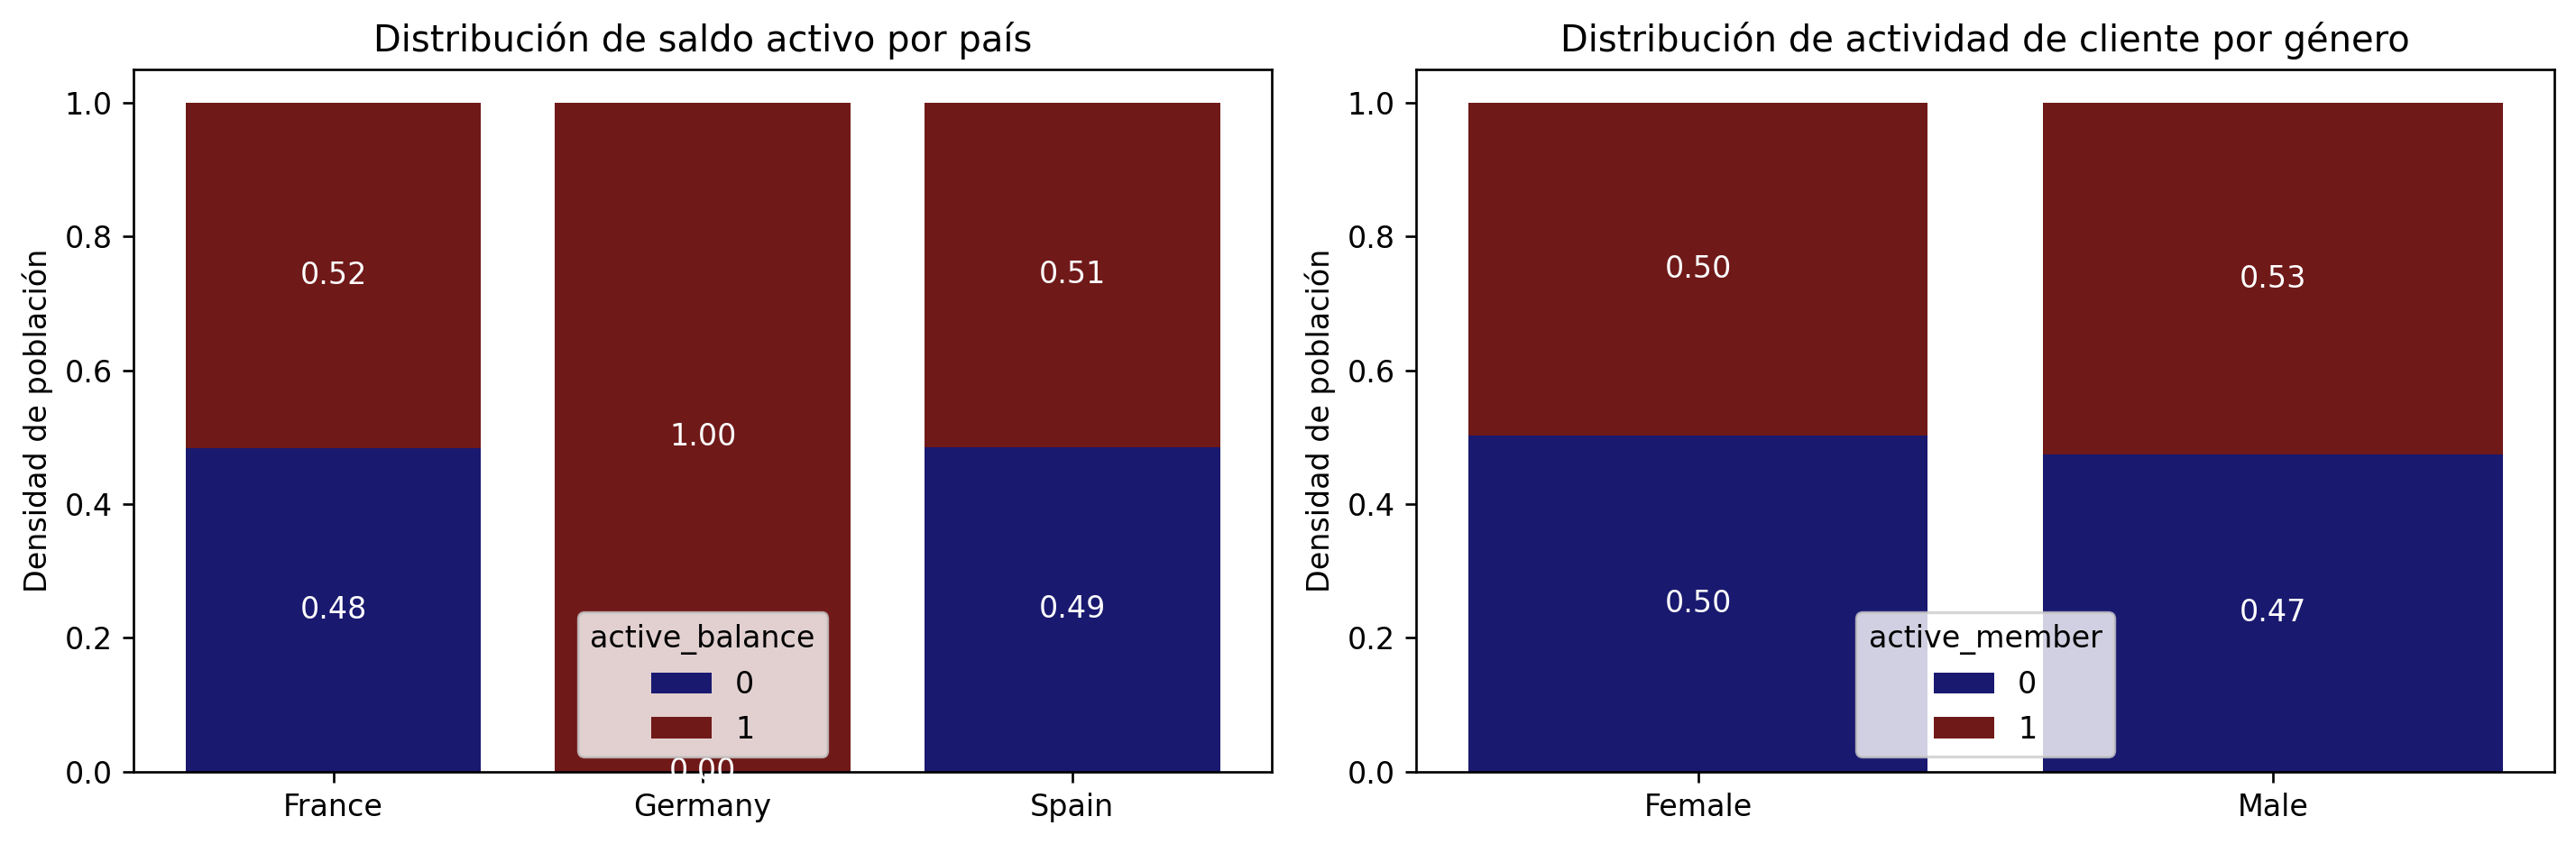

In [45]:
width = 0.8
fig, axs = plt.subplots(ncols=2, figsize=(12, 4), dpi=240)

# Country vs Active Balance 
classes = np.sort(X_train['country'].unique()).tolist()
x_pos = np.arange(len(classes))
data = np.zeros((2, len(classes)))
for j, label in enumerate(classes):
    data[0, j] = ((X_train['country'] == label) & (X_train['active_balance'] == 0)).sum()
    data[1, j] = ((X_train['country'] == label) & (X_train['active_balance'] == 1)).sum()
data = data / data.sum(axis=0)
bottom = np.zeros(len(classes))
for j in range(2):
    p = axs[0].bar(x_pos, data[j, :], width=width, bottom=bottom, label=str(j), color = churn_colors[j])
    bottom += data[j, :]
    axs[0].bar_label(p, fmt='%.2f', label_type='center', color = 'White')
axs[0].set_ylabel('Densidad de población')
axs[0].set_xticks(x_pos)
axs[0].set_xticklabels(classes)
axs[0].legend(title='active_balance', loc="lower center")
axs[0].set_title('Distribución de saldo activo por país')

#Active Member vs Gender
classes = np.sort(X_train['gender'].unique()).tolist()
x_pos = np.arange(len(classes))
data = np.zeros((2, len(classes)))
for j, label in enumerate(classes):
    data[0, j] = ((X_train['gender'] == label) & (X_train['active_member'] == 0)).sum()
    data[1, j] = ((X_train['gender'] == label) & (X_train['active_member'] == 1)).sum()
data = data / data.sum(axis=0)
bottom = np.zeros(len(classes))
for j in range(2):
    p = axs[1].bar(x_pos, data[j, :], width=width, bottom=bottom, label=str(j), color = churn_colors[j])
    bottom += data[j, :]
    axs[1].bar_label(p, fmt='%.2f', label_type='center', color = 'White')
axs[1].set_ylabel('Densidad de población')
axs[1].set_xticks(x_pos)
axs[1].set_xticklabels(classes)
axs[1].legend(title='active_member', loc="lower center")
axs[1].set_title('Distribución de actividad de cliente por género')

plt.tight_layout()
plt.show()


A partir de las gráficas de barras apiladas. se observa lo siguiente:
- Todos los clientes de Alemania tienen un saldo activo en sus cuentas, mientras que, aproximadamente solo la mitad de clientes de Francia y España tienen sus saldos activos.
- En proporción, los clientes másculinos son más activos que los clientes femeninos.

<a name = 'Resumen_de_pruebas_estadísticas'></a>
### Resumen de pruebas estadísticas

A continuación se presenta un resumen de los resultados obtenidos a partir de las pruebas estadísticas realizadas.
- No se muestra una diferencia significativa entre la distribución de la variable `tenure` en clientes que abandonan y permanecen.
- No se muestra una diferencia significativa entre la distribución y tendencia de la variable `estimated_salary` en clientes que abandonan y permanecen.
- Si bien, la distribución de `balance` en clientes con saldo en su cuentas es distinto en ambos grupos, la tendencia es la misma.
- Se agregó la variable `active_balance`la cual indica si un cliente posee o no saldo en su cuenta. Se encontró que la proporción de clientes con saldo $\$0$ es significativamente distinta en aquellos que permanecen que los que abandonan la institución.
- Se encontró una correlación significante entre el número de productos y el balance para clientes que no han abandonado la institución.
- No existe una dependencia significativa entre la variable `credit_card` y el hecho de que los clientes abandonen o permanezcan en la institución.
- No se encontró una diferencia significativa entre la proporción de clientes que abandonan y la variable `credit_card`.
- La proporción de clientes alemanes que abandonan es mayor a la proporción de clientes españoles y franceses que abandonan. La proporción de clientes españoles y franceces que abandonan estadísticamente es la misma.
- Todos los clientes alemanes tienen su balance activo, es decir, cuentan con dinero ingresado en cuenta. 
- En proporción, los clientes masculinos son estadísticamente clientes más activos que los clientes femeninos.

A partir de la información encontrada, se seleccionarán variables con las cuales se entrenarán diversos modelos computacionales.

<a name='Transformación_de_datos'></a>
## Transformación de datos

Para los modelos computacionales, es necesario transformar y codificar los datos para que estos sean interpretados por el modelo. 

Antes de modificar los datos, se almacenaran los datos originales.

In [46]:
# Generando copia datasets
X_train_base = X_train.copy()
X_test_base = X_test.copy()

Las variables `country`y `gender`, cuyos valores son *strings*, deben ser codificados a valores númericos. La variable `country` será codificada a `one-hot encoding`, mientras que la variable `gender` será codificada de la siguiente forma
* `Female`: 0
* `Male`: 1

De igual forma, es necesario escalar los datos numéricos para evitar que los modelos se saturen debido a diferencias de magnitudes en ciertas variables.

Para escalar los datos, es posible utilizar dos métricas distintas: *normalización* y *estandarización*. En este caso se generan ambos escaladores para utilizarlos a conveniencia. 

In [47]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

# Generando escaladores
scalerMinMax = MinMaxScaler()
scalerStandard = StandardScaler()

# Generando encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

En este caso, se ajustan (*fitting*) los enconders al conjunto de datos de entrenamiento

In [48]:
# Inicializando OHE
_ = encoder.fit(X_train[['country']])
_ = scalerStandard.fit(X_train[numerical_vars])

Para tener reproducibilidad de los datos, se realizó la función `transform_data`. Esta función recibe el escalador y el encoder ajustados a los datos de entrenamiento con los cuales se obtendrá el conjunto de datos transformados. Esta función servirá tanto para ajustar los mismos datos de entrenamiento u cualquier otra instancia que se desee pasar por el modelo y que tenga la misma estructura que los datos originales.

In [49]:
def transform_data(X, scaler, encoder):
    numerical_vars = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
    X[numerical_vars] = scaler.transform(X[numerical_vars])
    encoded = encoder.transform(X[['country']])
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['country']), index=X.index).astype(int)
    X_transformed = pd.concat([X.drop(columns=['country']), encoded_df], axis=1)
    X_transformed = X_transformed.sort_index(axis=1)

    X_transformed['gender'] = X_transformed['gender'].map({'Male': 0, 'Female': 1})
    return X_transformed

In [50]:
X_train = X_train_base.copy()
X_test = X_test_base.copy()

Se utiliza la función `transform_data` para modificar los datasets de entrenamiento y prueba.

In [51]:
# Transformando data
X_train = transform_data(X_train, scalerStandard, encoder)
X_test = transform_data(X_test, scalerStandard, encoder)

A continuación se muestra cómo se modifican las variables en el conjunto de entrenamiento.

In [52]:
X_train.head()

,active_balance,active_member,age,balance,country_France,country_Germany,country_Spain,credit_card,credit_score,estimated_salary,gender,products_number,tenure
9385,1,1,0.487923,0.308125,0,1,0,1,0.382227,-1.712869,0,0.825039,1.033751
2155,1,0,-0.379067,0.394675,1,0,0,1,0.101876,-1.409809,1,-0.914174,0.341382
768,1,0,0.198926,0.699392,0,0,1,0,0.351077,0.349622,0,0.825039,-1.043358
6082,1,0,0.102594,0.448857,0,1,0,1,0.776796,-0.664364,0,-0.914174,1.033751
2926,0,1,2.318235,-1.220239,1,0,0,1,-1.455629,0.262719,0,0.825039,1.033751


Además del conjunto completo de variables,denominado conjunto *All*, también se utilizará un conjunto sin las variables que estadísticamente no mostraron diferencia significante entre ambos grupos de `churn` y `no churn`, denominado conjunto *Drop*.

In [53]:
X_train_drop = X_train.drop(columns = ['tenure', 'estimated_salary', 'credit_card'])
X_test_drop = X_test.drop(columns = ['tenure', 'estimated_salary', 'credit_card'])

Con los conjuntos de datos ajustados, se procederá al entrenamiento de modelos.

____

<a name='Entrenamiento_de_modelos'></a>
## Entrenamiento de modelos

Una vez obtenido el conjunto de datos con el que se entrenará, se probarán distintos modelos computacionales para la predicción del abandono de clientes.

Es necesario establecer una métrica con la cual se evaluará el desempeño de cada modelo. Debido a que el conjunto de datos se encuentra desbalanceado y se tiene un mayor interés en predecir a los clientes que abandonan (clase positiva), **se escogerá la métrica *F2-score* para evaluar los modelos**. 

Sin embargo, para encontrar modelos óptimos, se realizará una busqueda de hiperparámetros utilizando una estrategia de **Random Search**.  Para evitar sobreajuste sobre el conjunto de entrenamiento, se empleará la técnica de **validación cruzada estratificada** (**k-folds stratified**) la cual permitirá obtener distintos conjuntos de validación obtenidos a partir del conjunto de entrenamiento. Mediante un proceso iterativo, se eligirán los hiperparámetros que proporcionen un mayor valor promedio en la métrica de **Average Precision** en los diferentes **k-folds** de validación. *Esta búsqueda de hiperparámetros no se mostrará en el código, únicamente se presentarán los modelos finales con los hiperparámetros óptimos.*

Posteriormente de haber encontrado los hiperparámetros óptimos, se modificará el valor **threshold** de tal forma que se maximice el valor del **F2-score**. Para realizar esto, se utilizará una estrategia de **Out of Fold** (**OOF**) el cual permitirá generar un *conjunto de validación virtual* sobre el conjunto de entrenamiento y así evitar sobreajuste sobre este.

Para calcular el threshold óptimo, se utilizará la función `precision_recall_curve` de sklearn el cual proporcionará los valores de **precision** y **recall** para cada uno uno de los thresholds analizados. Con estos valores se obtendrá el valor del F2-Score para cada par ordenado, obteniendo así el umbral de decisión que maximice esta métrica.

Se entrenará nuevamente el modelo utilizando los hiperparámetros óptimos sobre el conjunto de entrenamiento completo y posteriormente las clasificaciones se realizarán considerando el umbral de decisión encontrado anteriormente.

Con esto en cuenta, se exportan e implementan las siguientes funciones:

In [54]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import precision_recall_curve

def fbeta_pr(precision, recall, beta):
    precision = np.asarray(precision, dtype=float)
    recall = np.asarray(recall, dtype=float)

    numerator = (1+beta**2)*(precision*recall)
    denominator = beta**2*precision + recall
    
    result = np.divide(numerator, denominator, out=np.zeros_like(denominator, dtype=float), where = denominator!= 0)
    
    return result

Por último, se evaluará el conjunto de testing sobre el conjunto entrenado. Para obtener un panoráma completo del desempeño del modelo sobre este conjunto, se imprimirán diversas métricas de este utilizando la función `report_metrics`:

In [55]:
from sklearn.metrics import classification_report, fbeta_score, confusion_matrix, ConfusionMatrixDisplay

def report_metrics(y_true, y_hat):
    # Imprimiendo resultados generales
    print(classification_report(y_true, y_hat))
    f2 = fbeta_score(y_true, y_hat, beta = 2)
    print(f'F2-score : {f2:.4f}')

    # Graficando matriz de confusión
    cm = confusion_matrix(y_true, y_hat)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    plt.figure(dpi = 360)
    cm_display.plot(cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()

    return f2

Para mantener reproducibilidad, se construye un generador de 5 folds el cual se entrenarán los distintos modelos.

In [56]:
skf = StratifiedKFold(n_splits = 5, shuffle=True, random_state = SEED)
skf2 = StratifiedKFold(n_splits = 5, shuffle=True) # Generador usado para random search

Para guardar el desempeño de los distintos modelos, se generará la lista `history_models`, en la que se almacenaran los distintos modelos así como las métricas de desempeño obtenidos sobre el conjunto de prueba.

In [57]:
history_models = []

<a name='Regresión_logística'></a>
### Regresión logística 

Dado que el problema que se desea resolver es un *problema de clasificación binaria*, la regresión logística es uno de los primeros modelos que se analizarán. La regresión logística permite predecir si un conjunto permanece a una clase (negativa o positiva, no churn y churn) mediante una estimación lineal de sus parámetros. Sin embargo, debido a esta dependencia lineal, el modelo se ve limitado si no existe una diferencia significativa entre las variables del conjunto de datos. A pesar de ello, este modelo se implementa como un modelo *baseline*.

Se empezará entrenando un modelo de regresión logística para el conjunto de datos completos (sin el filtrado de variables)

New threshold: 0.4099

-----Métricas sobre testing set-----

              precision    recall  f1-score   support

           0       0.92      0.55      0.69      1593
           1       0.32      0.82      0.46       407

    accuracy                           0.61      2000
   macro avg       0.62      0.69      0.58      2000
weighted avg       0.80      0.61      0.65      2000

F2-score : 0.6262


<Figure size 2304x1728 with 0 Axes>

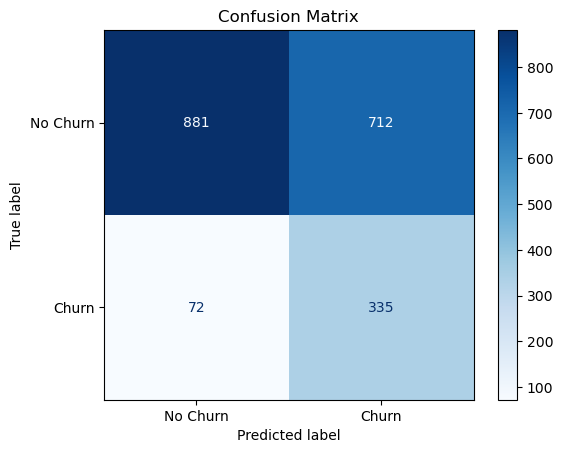

In [58]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty='elasticnet',
                         class_weight='balanced',
                         solver='saga',
                         random_state=SEED,
                         C=0.01,
                         max_iter = 350,
                         l1_ratio = 0.99)

oof_pred = np.zeros((len(X_train), 2))
for _, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
    model.fit(X_train.iloc[train_index], y_train.iloc[train_index])
    oof_pred[test_index, :] = model.predict_proba(X_train.iloc[test_index])

precision, recall, thresholds = precision_recall_curve(y_train, oof_pred[:,1])
f2_score = fbeta_pr(precision, recall, 2)
index_max = np.argmax(f2_score)
new_threshold = thresholds[index_max]
print(f'New threshold: {new_threshold:.4f}')

model.fit(X_train, y_train)

print('\n-----Métricas sobre testing set-----\n')
y_hat = (model.predict_proba(X_test)[:,1] >= new_threshold).astype(int)
f2 = report_metrics(y_test, y_hat)

In [59]:
model_resume = {'model_name': 'Regresión logística All',
                'model': model,
                'recall': recall,
                'precision': precision,
                'threshold': new_threshold,
                'f2-score': f2}

history_models.append(model_resume)

Ahora, se implementará un modelo de regresión logística utilizando el conjunto de datos reducidos.

New threshold: 0.3877

-----Métricas sobre testing set-----

              precision    recall  f1-score   support

           0       0.92      0.55      0.69      1593
           1       0.32      0.82      0.46       407

    accuracy                           0.60      2000
   macro avg       0.62      0.69      0.57      2000
weighted avg       0.80      0.60      0.64      2000

F2-score : 0.6248


<Figure size 2304x1728 with 0 Axes>

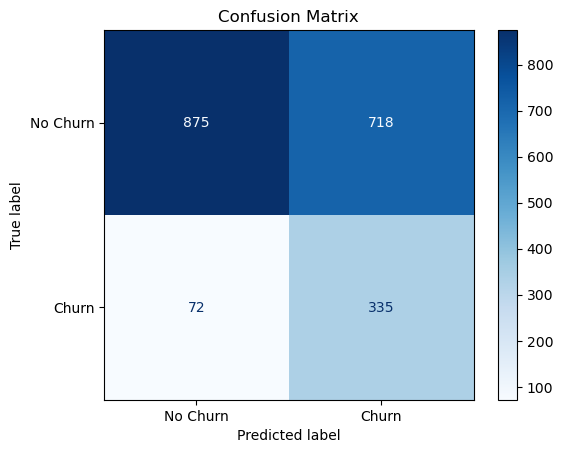

In [60]:
model = LogisticRegression(penalty='elasticnet',
                         class_weight='balanced',
                         solver='saga',
                         random_state=SEED,
                         C = 0.1,
                         l1_ratio = 0.2,
                         max_iter = 400)

oof_pred = np.zeros((len(X_train), 2))
for _, (train_index, test_index) in enumerate(skf.split(X_train_drop, y_train)):
    model.fit(X_train_drop.iloc[train_index], y_train.iloc[train_index])
    oof_pred[test_index, :] = model.predict_proba(X_train_drop.iloc[test_index])

precision, recall, thresholds = precision_recall_curve(y_train, oof_pred[:,1])
f2_score = fbeta_pr(precision, recall, 2)
index_max = np.argmax(f2_score)
new_threshold = thresholds[index_max]
print(f'New threshold: {new_threshold:.4f}')

model.fit(X_train_drop, y_train)

print('\n-----Métricas sobre testing set-----\n')
y_hat = (model.predict_proba(X_test_drop)[:,1] >= new_threshold).astype(int)
f2 = report_metrics(y_test, y_hat)

In [61]:
model_resume = {'model_name': 'Regresión logística Drop',
                'model': model,
                'recall': recall,
                'precision': precision,
                'threshold': new_threshold,
                'f2-score': f2}

history_models.append(model_resume)

<a name='KNearest_Neighbors'></a>
### K-Nearest Neighbors

*K-Nearest Neighbours* (KNN) es un algoritmo que clasifica una nueva instancia comparándola con las instancias de entrenamiento más cercanas. En lugar de aprender reglas complejas, KNN simplemente guarda todos los datos y, cuando se le da un nuevo punto, busca los $k$ vecinos más cercanos y asigna la clase más común entre ellos. Es útil para reconocer patrones y dibujar fronteras entre grupos de datos similares.

Se empezará generando un modelo de KNN para el conjunto de datoss *All*.

New threshold: 0.1245

-----Métricas sobre testing set-----

              precision    recall  f1-score   support

           0       0.94      0.63      0.76      1593
           1       0.37      0.85      0.52       407

    accuracy                           0.68      2000
   macro avg       0.66      0.74      0.64      2000
weighted avg       0.83      0.68      0.71      2000

F2-score : 0.6732


<Figure size 2304x1728 with 0 Axes>

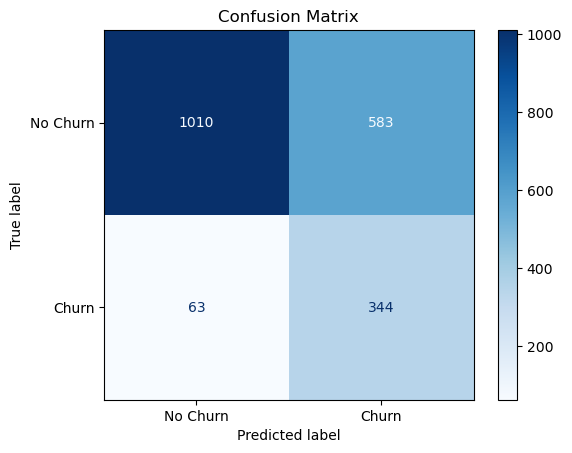

In [62]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(metric='minkowski',
                           algorithm='brute',
                           n_neighbors = 25,
                           p = 4,
                           weights = 'distance')

oof_pred = np.zeros((len(X_train), 2))
for _, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
    model.fit(X_train.iloc[train_index], y_train.iloc[train_index])
    oof_pred[test_index, :] = model.predict_proba(X_train.iloc[test_index])

precision, recall, thresholds = precision_recall_curve(y_train, oof_pred[:,1])
f2_score = fbeta_pr(precision, recall, 2)
index_max = np.argmax(f2_score)
new_threshold = thresholds[index_max]
print(f'New threshold: {new_threshold:.4f}')

model.fit(X_train, y_train)

print('\n-----Métricas sobre testing set-----\n')
y_hat = (model.predict_proba(X_test)[:,1] >= new_threshold).astype(int)
f2 = report_metrics(y_test, y_hat)

In [63]:
model_resume = {'model_name': 'K-Nearest Neighbors All',
                'model': model,
                'recall': recall,
                'precision': precision,
                'threshold': new_threshold,
                'f2-score': f2}

history_models.append(model_resume)

Ahora, se implementará un modelo de KNN para el conjunto de datos *Drop*.

New threshold: 0.1230

-----Métricas sobre testing set-----

              precision    recall  f1-score   support

           0       0.94      0.64      0.77      1593
           1       0.38      0.85      0.53       407

    accuracy                           0.69      2000
   macro avg       0.66      0.75      0.65      2000
weighted avg       0.83      0.69      0.72      2000

F2-score : 0.6825


<Figure size 2304x1728 with 0 Axes>

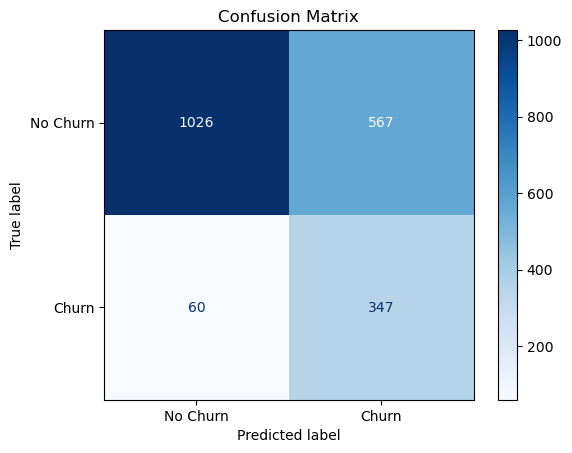

In [64]:
model = KNeighborsClassifier(metric='minkowski',
                           algorithm='brute',
                           weights = 'distance',
                           n_neighbors = 33,
                           p = 3)

oof_pred = np.zeros((len(X_train), 2))
for _, (train_index, test_index) in enumerate(skf.split(X_train_drop, y_train)):
    model.fit(X_train_drop.iloc[train_index], y_train.iloc[train_index])
    oof_pred[test_index, :] = model.predict_proba(X_train_drop.iloc[test_index])

precision, recall, thresholds = precision_recall_curve(y_train, oof_pred[:,1])
f2_score = fbeta_pr(precision, recall, 2)
index_max = np.argmax(f2_score)
new_threshold = thresholds[index_max]
print(f'New threshold: {new_threshold:.4f}')

model.fit(X_train_drop, y_train)

print('\n-----Métricas sobre testing set-----\n')
y_hat = (model.predict_proba(X_test_drop)[:,1] >= new_threshold).astype(int)
f2 = report_metrics(y_test, y_hat)

In [65]:
model_resume = {'model_name': 'K-Nearest Neighbors Drop',
                'model': model,
                'recall': recall,
                'precision': precision,
                'threshold': new_threshold,
                'f2-score': f2}

history_models.append(model_resume)

<a name='Árboles_de_decisión'></a>
### Arboles de decisión

Los *árboles de decisión* establecen umbrales sobre diferentes variables para estimar la probabilidad de que una muestra pertenezca a una clase determinada. Esta forma de particionar los datos permite analizarlos de manera no lineal y construir modelos altamente interpretables.

De igual manera que con la regresión logística, se empezará entrenando un modelo utilizando el conjunto de datos completos.

New threshold: 0.3944

-----Métricas sobre testing set-----

              precision    recall  f1-score   support

           0       0.94      0.70      0.80      1593
           1       0.41      0.82      0.55       407

    accuracy                           0.72      2000
   macro avg       0.67      0.76      0.68      2000
weighted avg       0.83      0.72      0.75      2000

F2-score : 0.6832


<Figure size 2304x1728 with 0 Axes>

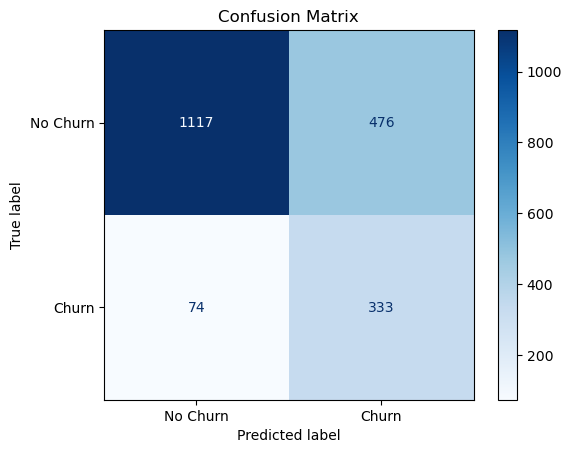

In [66]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(criterion = 'gini',
                               splitter = 'best',
                               class_weight = 'balanced',
                               random_state = SEED,
                               max_depth = 10,
                               max_leaf_nodes = 75,
                               min_samples_split = 140,
                               min_samples_leaf=20)

oof_pred = np.zeros((len(X_train), 2))
for _, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
    model.fit(X_train.iloc[train_index], y_train.iloc[train_index])
    oof_pred[test_index, :] = model.predict_proba(X_train.iloc[test_index])

precision, recall, thresholds = precision_recall_curve(y_train, oof_pred[:,1])
f2_score = fbeta_pr(precision, recall, 2)
index_max = np.argmax(f2_score)
new_threshold = thresholds[index_max]
print(f'New threshold: {new_threshold:.4f}')

model.fit(X_train, y_train)

print('\n-----Métricas sobre testing set-----\n')
y_score = model.predict_proba(X_test)[:,1]
y_hat = (y_score >= new_threshold).astype(int)
f2 = report_metrics(y_test, y_hat)

In [67]:
model_resume = {'model_name': 'Decision Tree All',
                'model': model,
                'recall': recall,
                'precision': precision,
                'threshold': new_threshold,
                'f2-score': f2}

history_models.append(model_resume)

Dado que los arboles de decisión son altamente interpretables, es posible graficar el arbol de decisión encontrado por el modelo.

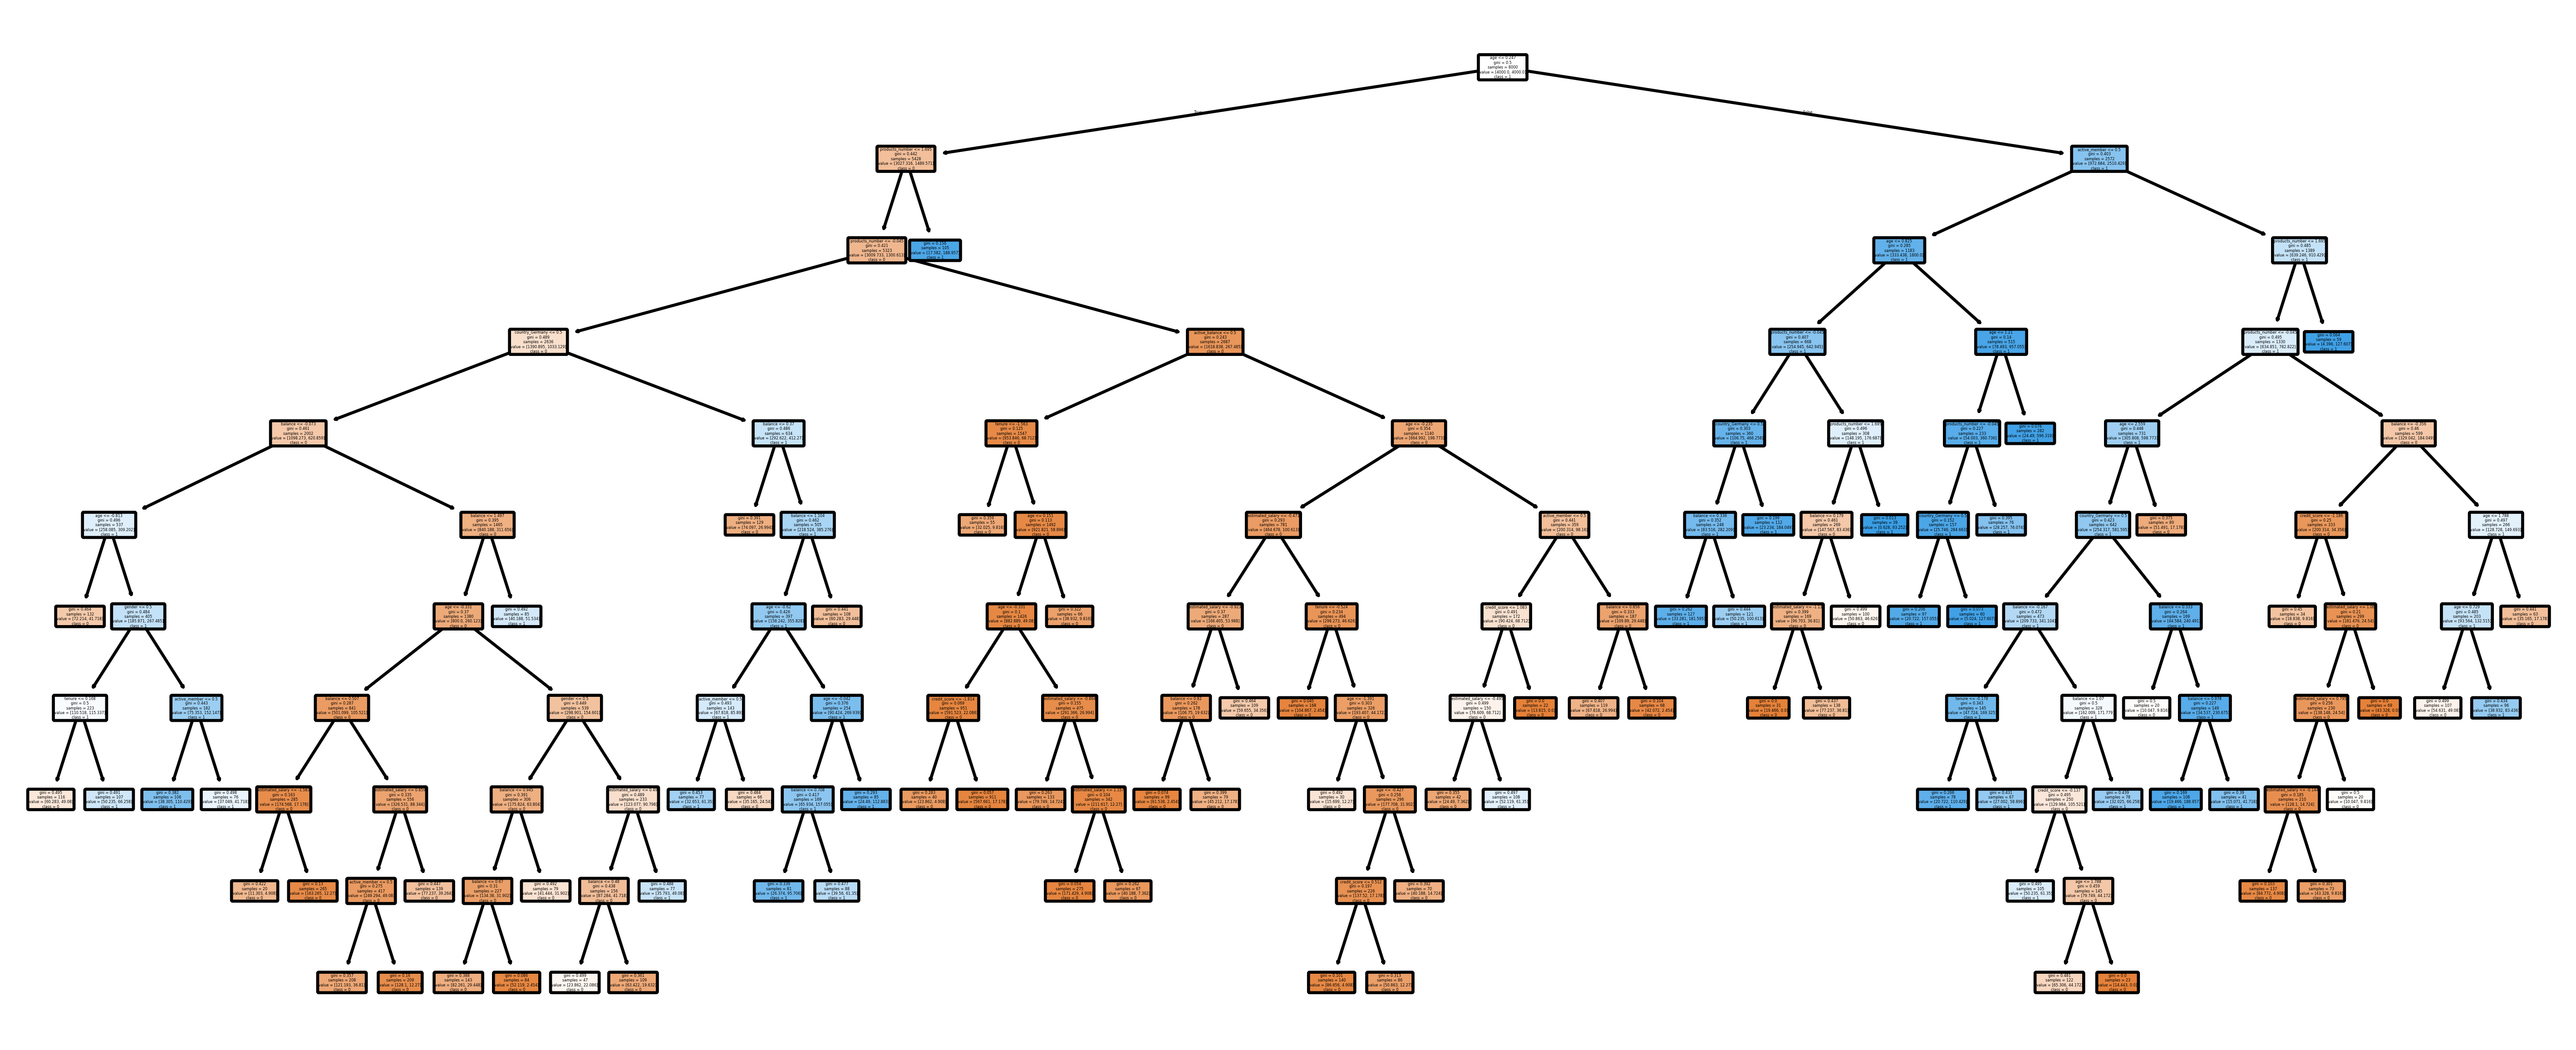

In [68]:
from sklearn.tree import plot_tree

feature_names = X_train.columns if hasattr(X_train, "columns") else [f"x{i}" for i in range(X_train.shape[1])]

class_names = [str(cls) for cls in np.unique(y)]

plt.figure(figsize=(15, 6), dpi = 480)
plot_tree(model, filled=True, feature_names=feature_names, class_names=class_names, rounded=True)
plt.show()

Ahora, se entrenará el modelo de árbol de decisión utilizando el conjunto de datos filtrado.

New threshold: 0.4132

-----Métricas sobre testing set-----

              precision    recall  f1-score   support

           0       0.93      0.70      0.80      1593
           1       0.41      0.81      0.54       407

    accuracy                           0.72      2000
   macro avg       0.67      0.75      0.67      2000
weighted avg       0.83      0.72      0.75      2000

F2-score : 0.6738


<Figure size 2304x1728 with 0 Axes>

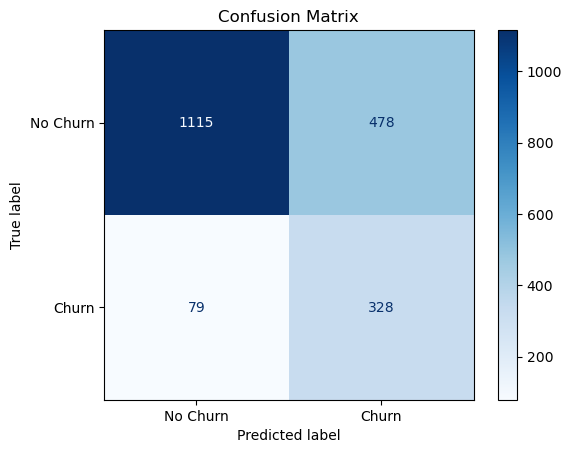

In [69]:
model = DecisionTreeClassifier(criterion = 'gini',
                               splitter = 'best',
                               class_weight = 'balanced',
                               random_state = SEED,
                               max_depth = 10,
                               max_leaf_nodes = 100,
                               min_samples_split = 170,
                               min_samples_leaf = 20)

oof_pred = np.zeros((len(X_train), 2))
for _, (train_index, test_index) in enumerate(skf.split(X_train_drop, y_train)):
    model.fit(X_train_drop.iloc[train_index], y_train.iloc[train_index])
    oof_pred[test_index, :] = model.predict_proba(X_train_drop.iloc[test_index])

precision, recall, thresholds = precision_recall_curve(y_train, oof_pred[:,1])
f2_score = fbeta_pr(precision, recall, 2)
index_max = np.argmax(f2_score)
new_threshold = thresholds[index_max]
print(f'New threshold: {new_threshold:.4f}')

model.fit(X_train_drop, y_train)

print('\n-----Métricas sobre testing set-----\n')
y_hat = (model.predict_proba(X_test_drop)[:,1] >= new_threshold).astype(int)
f2 = report_metrics(y_test, y_hat)

In [70]:
model_resume = {'model_name': 'Decision Tree Drop',
                'model': model,
                'recall': recall,
                'precision': precision,
                'threshold': new_threshold,
                'f2-score': f2}

history_models.append(model_resume)

De igual forma, se grafica el arbol de decisión encontrado por el modelo para el conjunto de variables filtradas.

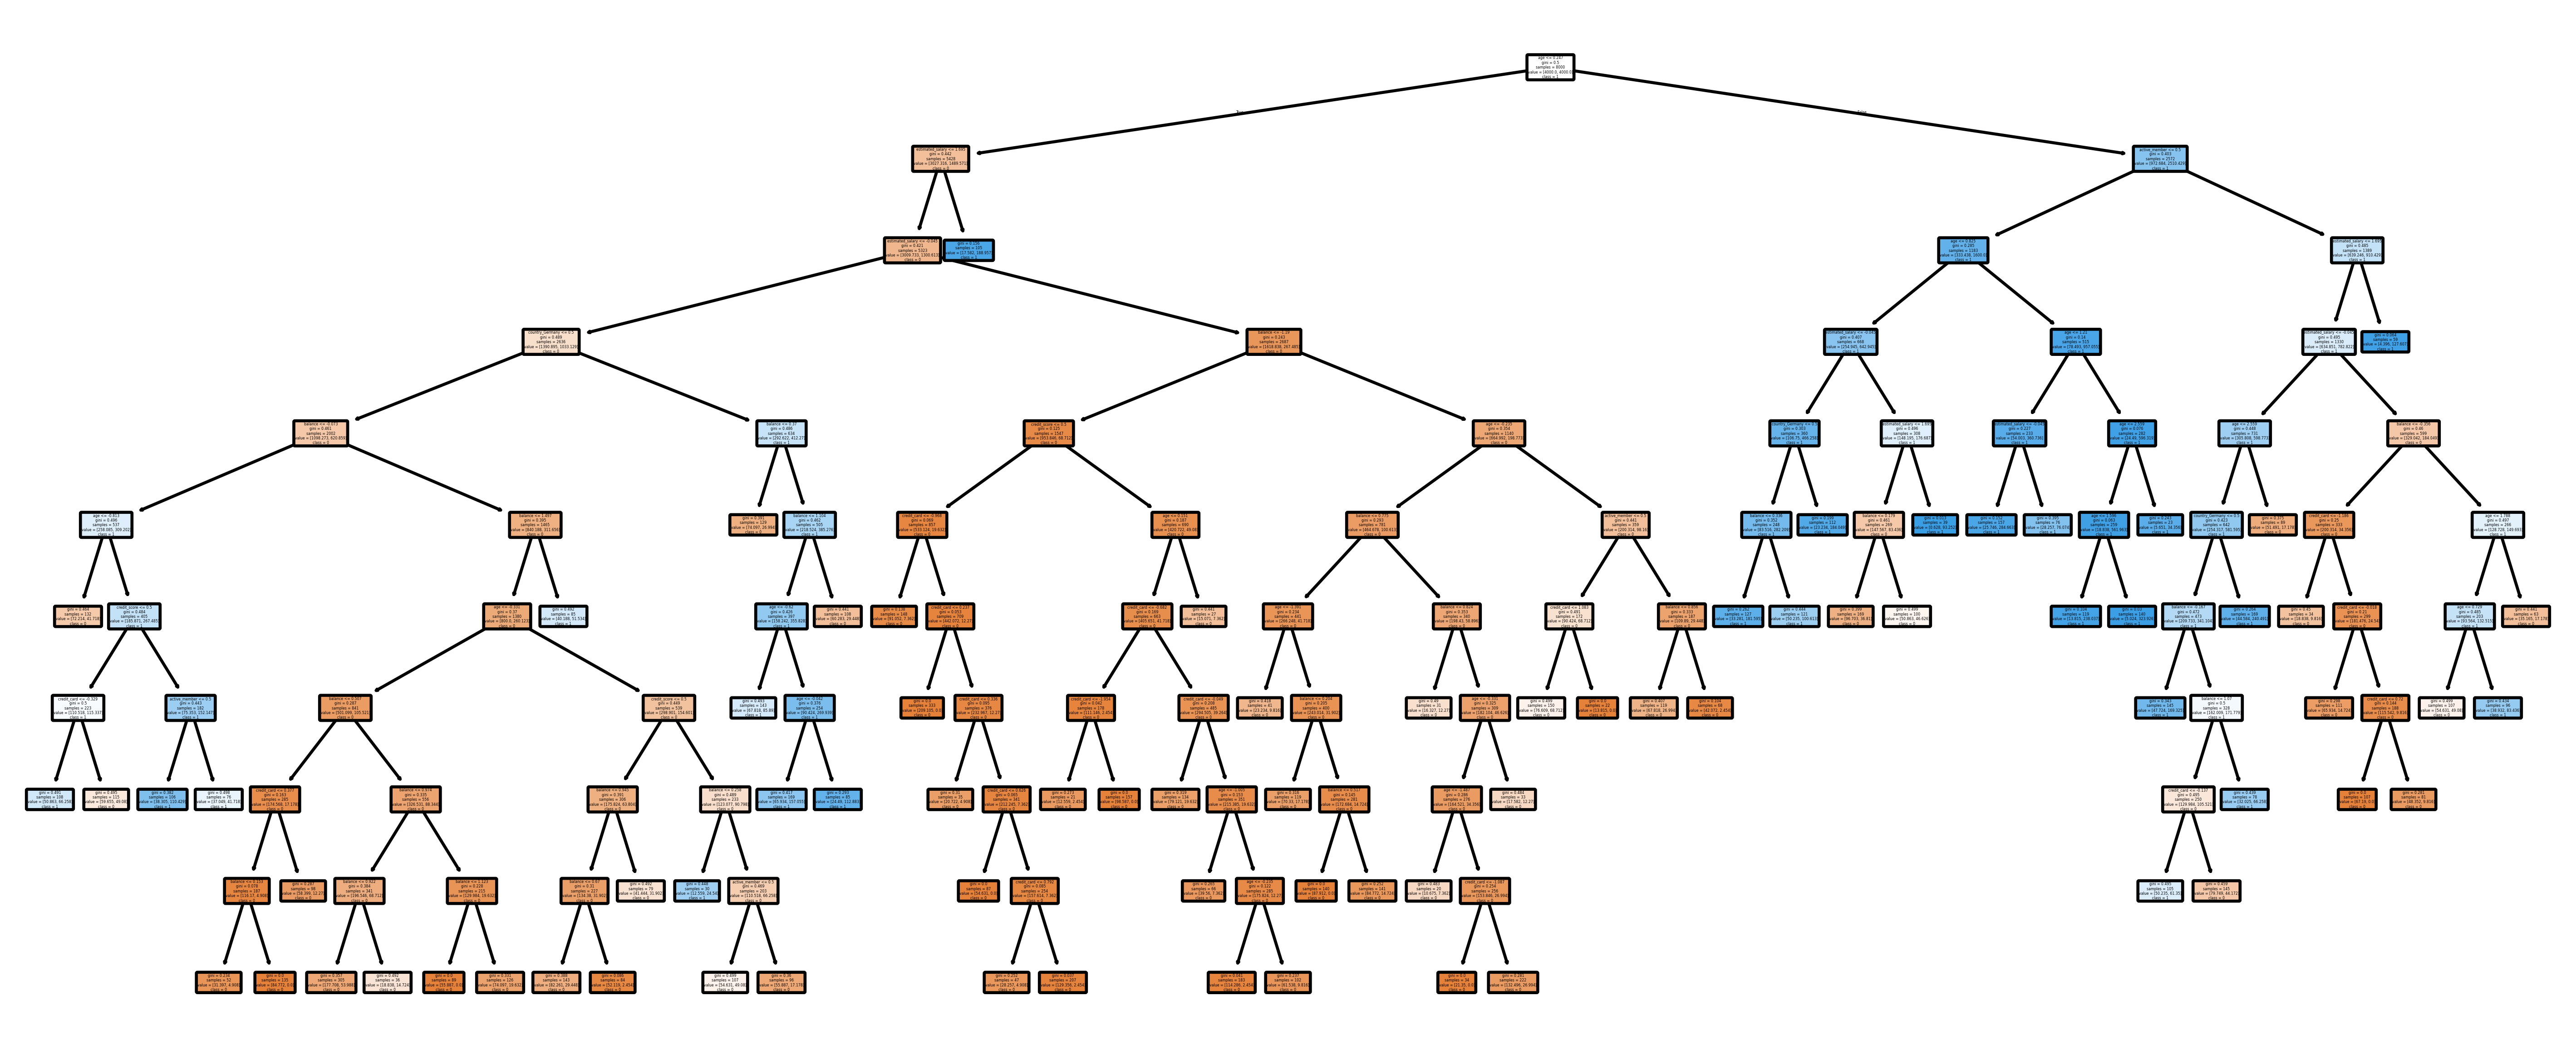

In [71]:
plt.figure(figsize=(15, 6), dpi = 480)
plot_tree(model, filled=True, feature_names=feature_names, class_names=class_names, rounded=True)
plt.show()

<a name='Random_forest'></a>
### Random forest

Los árboles aleatorios, o *random forest*, se basan en el mismo concepto de los árboles de decisión, con la diferencia de que ahora se entrenan $n$ árboles los cuales realizan distintas clasificaciones sobre una instancia en específico. Posteriormente mediante una suma de votos (*bagging*) se determina a qué clase pertenece dicha instancia. 

Se empezará entrando un modelo sobre el conjunto de datos completo. 

New threshold: 0.3450

-----Métricas sobre testing set-----

              precision    recall  f1-score   support

           0       0.94      0.75      0.83      1593
           1       0.45      0.81      0.58       407

    accuracy                           0.76      2000
   macro avg       0.70      0.78      0.71      2000
weighted avg       0.84      0.76      0.78      2000

F2-score : 0.7019


<Figure size 2304x1728 with 0 Axes>

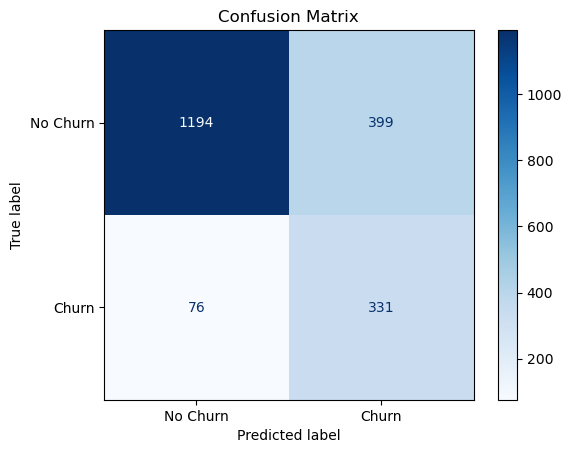

In [72]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(criterion='gini',
                               bootstrap=True,
                               class_weight='balanced',
                               n_estimators = 175,
                               max_features = 8,
                               max_depth = 10,
                               max_leaf_nodes = 150,
                               min_samples_split = 20,
                               min_samples_leaf = 5,
                               random_state=SEED)

oof_pred = np.zeros((len(X_train), 2))
for _, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
    model.fit(X_train.iloc[train_index], y_train.iloc[train_index])
    oof_pred[test_index, :] = model.predict_proba(X_train.iloc[test_index])

precision, recall, thresholds = precision_recall_curve(y_train, oof_pred[:,1])
f2_score = fbeta_pr(precision, recall, 2)
index_max = np.argmax(f2_score)
new_threshold = thresholds[index_max]
print(f'New threshold: {new_threshold:.4f}')

model.fit(X_train, y_train)

print('\n-----Métricas sobre testing set-----\n')
y_hat = (model.predict_proba(X_test)[:,1] >= new_threshold).astype(int)
f2 = report_metrics(y_test, y_hat)

In [73]:
model_resume = {'model_name': 'Random Forest All',
                'model': model,
                'recall': recall,
                'precision': precision,
                'threshold': new_threshold,
                'f2-score': f2}

history_models.append(model_resume)

Ahora, se implementará entrenará un modelo de random forest para el conjunto de datos filtrado.

New threshold: 0.3848

-----Métricas sobre testing set-----

              precision    recall  f1-score   support

           0       0.94      0.74      0.83      1593
           1       0.45      0.83      0.58       407

    accuracy                           0.76      2000
   macro avg       0.69      0.78      0.70      2000
weighted avg       0.84      0.76      0.78      2000

F2-score : 0.7059


<Figure size 2304x1728 with 0 Axes>

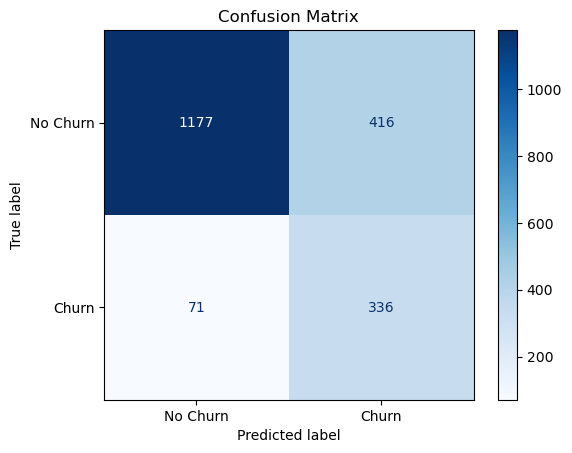

In [74]:
model = RandomForestClassifier(criterion='gini',
                               bootstrap=True,
                               class_weight='balanced',
                               n_estimators = 75,
                               max_features = 6,
                               max_depth = 8,
                               max_leaf_nodes = 75,
                               min_samples_split = 30,
                               min_samples_leaf = 5,
                               random_state=SEED)

oof_pred = np.zeros((len(X_train), 2))
for _, (train_index, test_index) in enumerate(skf.split(X_train_drop, y_train)):
    model.fit(X_train_drop.iloc[train_index], y_train.iloc[train_index])
    oof_pred[test_index, :] = model.predict_proba(X_train_drop.iloc[test_index])

precision, recall, thresholds = precision_recall_curve(y_train, oof_pred[:,1])
f2_score = fbeta_pr(precision, recall, 2)
index_max = np.argmax(f2_score)
new_threshold = thresholds[index_max]
print(f'New threshold: {new_threshold:.4f}')

model.fit(X_train_drop, y_train)

print('\n-----Métricas sobre testing set-----\n')
y_hat = (model.predict_proba(X_test_drop)[:,1] >= new_threshold).astype(int)
f2 = report_metrics(y_test, y_hat)

In [75]:
model_resume = {'model_name': 'Random Forest Drop',
                'model': model,
                'recall': recall,
                'precision': precision,
                'threshold': new_threshold,
                'f2-score': f2}

history_models.append(model_resume)

<a name='Gradient_boosting_classifier'></a>
### Gradient Boosting Classifier

Los modelos de *gradient boosting* también se basan en árboles de decisión, pero en lugar de entrenarlos de manera independiente como en random forest, se entrenan de forma secuencial. Cada nuevo árbol busca corregir los errores que cometieron los anteriores, aprendiendo sobre los “residuos” o diferencias entre las predicciones y los valores reales. Al final, se suman las contribuciones de todos los árboles para obtener la predicción final.

Empezamos entrenando un modelo sobre el conjunto de entrenamiento completo.

New threshold: 0.1367

-----Métricas sobre testing set-----

              precision    recall  f1-score   support

           0       0.95      0.71      0.81      1593
           1       0.43      0.85      0.57       407

    accuracy                           0.74      2000
   macro avg       0.69      0.78      0.69      2000
weighted avg       0.84      0.74      0.76      2000

F2-score : 0.7113


<Figure size 2304x1728 with 0 Axes>

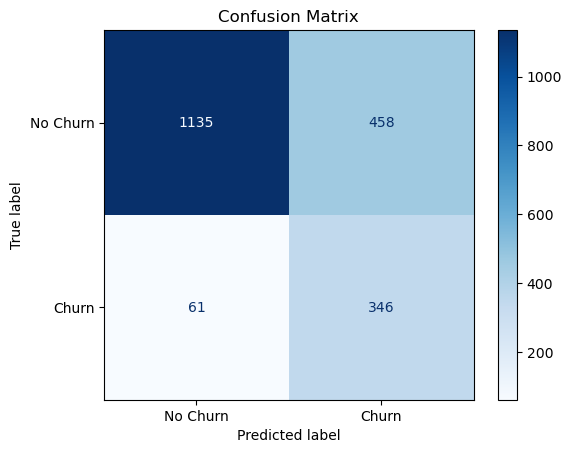

In [76]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(loss='log_loss',
                                   criterion='friedman_mse',
                                   n_estimators=1000,
                                   n_iter_no_change=20,                                 
                                   tol=0.0001,
                                   learning_rate = 0.02,
                                   subsample = 0.85,
                                   max_features = 3,
                                   max_depth = 5,
                                   max_leaf_nodes = 70,
                                   min_samples_split = 100,
                                   min_samples_leaf =5,
                                   validation_fraction=0.15,
                                   random_state = SEED)

oof_pred = np.zeros((len(X_train), 2))
for _, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
    model.fit(X_train.iloc[train_index], y_train.iloc[train_index])
    oof_pred[test_index, :] = model.predict_proba(X_train.iloc[test_index])

precision, recall, thresholds = precision_recall_curve(y_train, oof_pred[:,1])
f2_score = fbeta_pr(precision, recall, 2)
index_max = np.argmax(f2_score)
new_threshold = thresholds[index_max]
print(f'New threshold: {new_threshold:.4f}')

model.fit(X_train, y_train)

print('\n-----Métricas sobre testing set-----\n')
y_hat = (model.predict_proba(X_test)[:,1] >= new_threshold).astype(int)
f2 = report_metrics(y_test, y_hat)

In [77]:
model_resume = {'model_name': 'Gradient Boosting ALL',
                'model': model,
                'recall': recall,
                'precision': precision,
                'threshold': new_threshold,
                'f2-score': f2}

history_models.append(model_resume)

Ahora, se implementará un modelo de Gradient boosting para el conjunto de datos filtrado.

New threshold: 0.1369

-----Métricas sobre testing set-----

              precision    recall  f1-score   support

           0       0.95      0.72      0.82      1593
           1       0.44      0.85      0.58       407

    accuracy                           0.75      2000
   macro avg       0.69      0.79      0.70      2000
weighted avg       0.85      0.75      0.77      2000

F2-score : 0.7164


<Figure size 2304x1728 with 0 Axes>

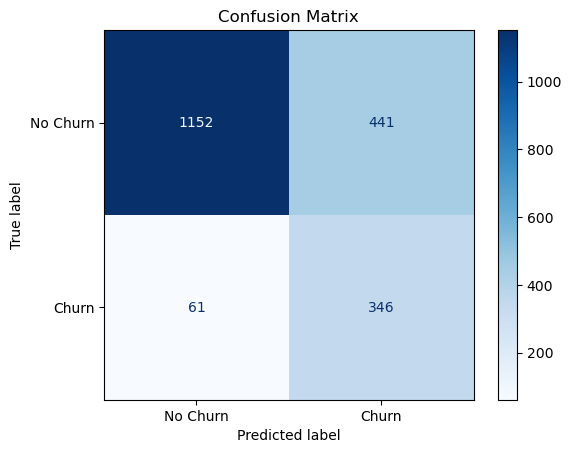

In [78]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(loss='log_loss',
                                 criterion='friedman_mse',
                                 n_estimators=1000,
                                 n_iter_no_change=20,                                 
                                 tol=0.0001,
                                 learning_rate = 0.04,                                 
                                 subsample = 0.90,
                                 max_features = 2,
                                 max_depth = 4,
                                 max_leaf_nodes = 75,
                                 min_samples_split = 100,
                                 min_samples_leaf = 5,
                                 validation_fraction=0.15,
                                 random_state = SEED)

oof_pred = np.zeros((len(X_train), 2))
for _, (train_index, test_index) in enumerate(skf.split(X_train_drop, y_train)):
    model.fit(X_train_drop.iloc[train_index], y_train.iloc[train_index])
    oof_pred[test_index, :] = model.predict_proba(X_train_drop.iloc[test_index])

precision, recall, thresholds = precision_recall_curve(y_train, oof_pred[:,1])
f2_score = fbeta_pr(precision, recall, 2)
index_max = np.argmax(f2_score)
new_threshold = thresholds[index_max]
print(f'New threshold: {new_threshold:.4f}')

model.fit(X_train_drop, y_train)

print('\n-----Métricas sobre testing set-----\n')
y_hat = (model.predict_proba(X_test_drop)[:,1] >= new_threshold).astype(int)
f2 = report_metrics(y_test, y_hat)

In [79]:
model_resume = {'model_name': 'Gradient Boosting Drop',
                'model': model,
                'recall': recall,
                'precision': precision,
                'threshold': new_threshold,
                'f2-score': f2}

history_models.append(model_resume)

### Resumen de modelos entrenados

Como se pudo observar a lo largo del entrenamiento de los modelos, los resultados fueron variando según el modelo implementado, teniendo un mayor valor de *f2-score* en los modelos de Gradient Boosting Classifier.

#### Curva Precision-Recall

A partir de los valores de *Precision* y *Recall* que cada modelo tuvo para los diferentes thresholds, es posible construir su gráfica Precisón-Recall (o *Curve PR* en inglés). Justamente el valor de *Average Precision* sobre el que los hiperparámetros fueron escogidos, proporciona el área debajo de la curva Precision-Recall. Una métrica parecida a esta, aunque más optimista, es la función `auc` de Sklearn. La métrica `auc` calcula también el área debajo de la curva Precision-Recall pero con interpolaciones entre los distintos puntos que la conforman, requeriendo así solo los valores de `Precision` y `Recall`. (Nota: la métrica `average_precision_score` para implementarse necesita de los `scores` obtenidos por los distintos modelos. Si bien, se podría implementar esta métrica almacenando estos *scores*, se opta por presentar la otra métrica por simplicidad).

A continuación, se presentan la curva Precision-Recall para los distintos modelos entrenados así como su valor *F2-Score* y el *AUC_PR* en una notación de pares ordenados.

Modelo: (F2-Score, AUC-PR)
Regresión logística All: (0.6262, 0.4322)
Regresión logística Drop: (0.6248, 0.4540)
K-Nearest Neighbors All: (0.6732, 0.6464)
K-Nearest Neighbors Drop: (0.6825, 0.6645)
Decision Tree All: (0.6832, 0.6492)
Decision Tree Drop: (0.6738, 0.6507)
Random Forest All: (0.7019, 0.6878)
Random Forest Drop: (0.7059, 0.6889)
Gradient Boosting ALL: (0.7113, 0.7011)
Gradient Boosting Drop: (0.7164, 0.7048)


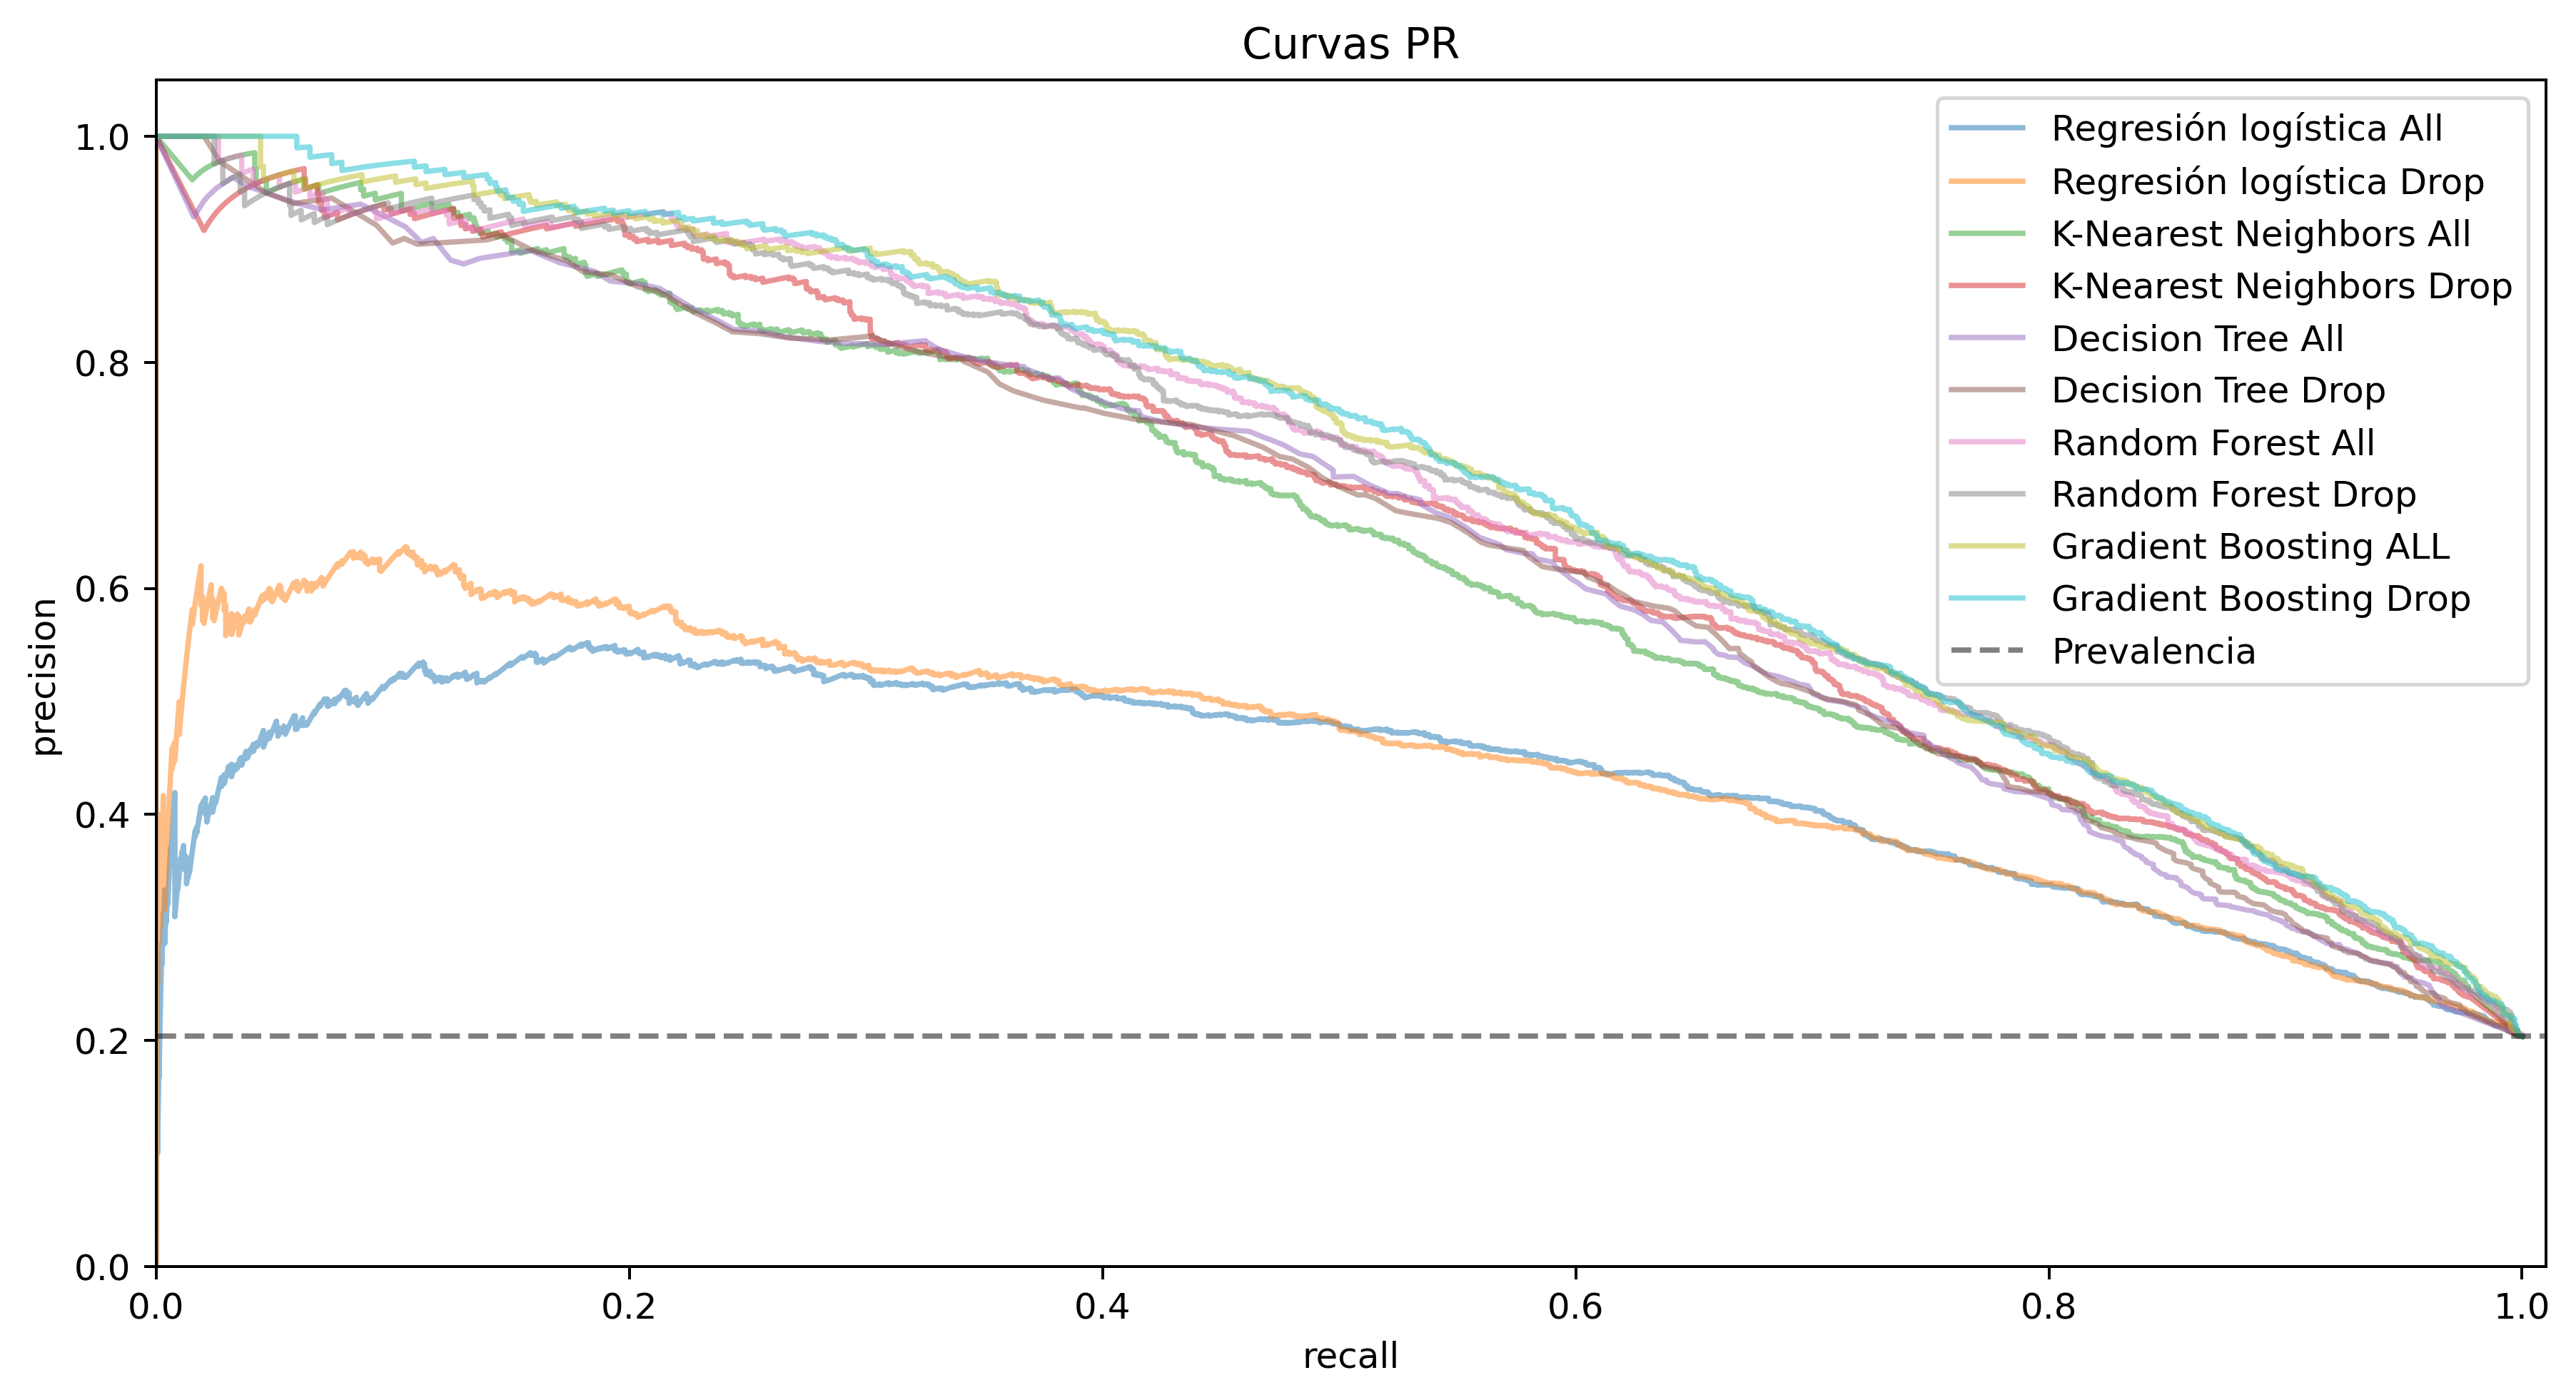

In [84]:
from sklearn.metrics import auc

plt.figure(dpi = 360, figsize = (12,6))
prevalencia = np.mean(y_train == 1)
print('Modelo: (F2-Score, AUC-PR)')
for i, model_resume in enumerate(history_models):
    auc_res = auc(model_resume['recall'], model_resume['precision'])
    print(f'{model_resume['model_name']}: ({model_resume['f2-score']:.4f}, {auc_res:.4f})')
    plt.plot(model_resume['recall'], model_resume['precision'], color=f"C{i}", label = model_resume['model_name'], alpha = 0.5)
plt.axhline(prevalencia, color = 'black', linestyle = '--', alpha = 0.50, label = 'Prevalencia')
plt.legend()
plt.xlim([0,1.01])
plt.ylim([0,1.05])
plt.xlabel('recall')
plt.ylabel('precision')
plt.title('Curvas PR')
plt.show()

Como se puede observar, el modelo Gradient Boosting Drop fue el modelo que mejor F2-score obtuvo así como un mejor valor de AUC-PR

#### Importancia de características

Los modelos basados en árbol poseen un atributo denominado `feature_importances_` el cual proprociona el valor de importancia de una variable en función de la impureza que esta proporcionó. A continuación, se observará la importancia de las distintas variables en cada conjunto de datos, *All* y *Drop*.

Para los modelos entrenados con el conjunto de datos *All*, se obtienen los siguientes resultados

In [108]:
vars_importance_all = pd.DataFrame()

for i in [4, 6, 8]: 
    importances = pd.Series(data = history_models[i]['model'].feature_importances_,
                            index=history_models[i]['model'].feature_names_in_,
                            name=history_models[i]['model_name'])
    
    vars_importance_all = pd.concat([vars_importance_all, importances], axis=1)

vars_importance_all

,Decision Tree All,Random Forest All,Gradient Boosting ALL
active_balance,0.014036,0.020419,0.018967
active_member,0.066866,0.052382,0.077948
age,0.417013,0.345346,0.340313
balance,0.128841,0.124367,0.085583
country_France,0.000000,0.005643,0.010063
country_Germany,0.041483,0.038163,0.047050
country_Spain,0.000000,0.005237,0.006659
credit_card,0.000000,0.006115,0.001947
credit_score,0.008535,0.061813,0.040363
estimated_salary,0.022620,0.063202,0.035698


Por su parte, para los modelos entrenados con el conjunto de datos *Drop* se obtienen los siguientes valores

In [110]:
vars_importance_drop = pd.DataFrame()

for i in [5, 7, 9]: 
    importances = pd.Series(data = history_models[i]['model'].feature_importances_,
                            index=history_models[i]['model'].feature_names_in_,
                            name=history_models[i]['model_name'])
    
    vars_importance_drop = pd.concat([vars_importance_drop, importances], axis=1)

vars_importance_drop

,Decision Tree Drop,Random Forest Drop,Gradient Boosting Drop
active_balance,0.000000,0.019705,0.016169
active_member,0.066771,0.062694,0.074514
age,0.425211,0.405724,0.351747
balance,0.148703,0.126575,0.102000
country_France,0.000000,0.003942,0.006667
country_Germany,0.041794,0.051273,0.053551
country_Spain,0.000000,0.004534,0.004062
credit_score,0.015418,0.044578,0.045660
gender,0.007919,0.017966,0.021650
products_number,0.294184,0.263008,0.323979


Para observar estos valores de importancia de mejor manera, se mostrará el promedio de los valores de importancia de los distintos modelos en una gráfica de barras.

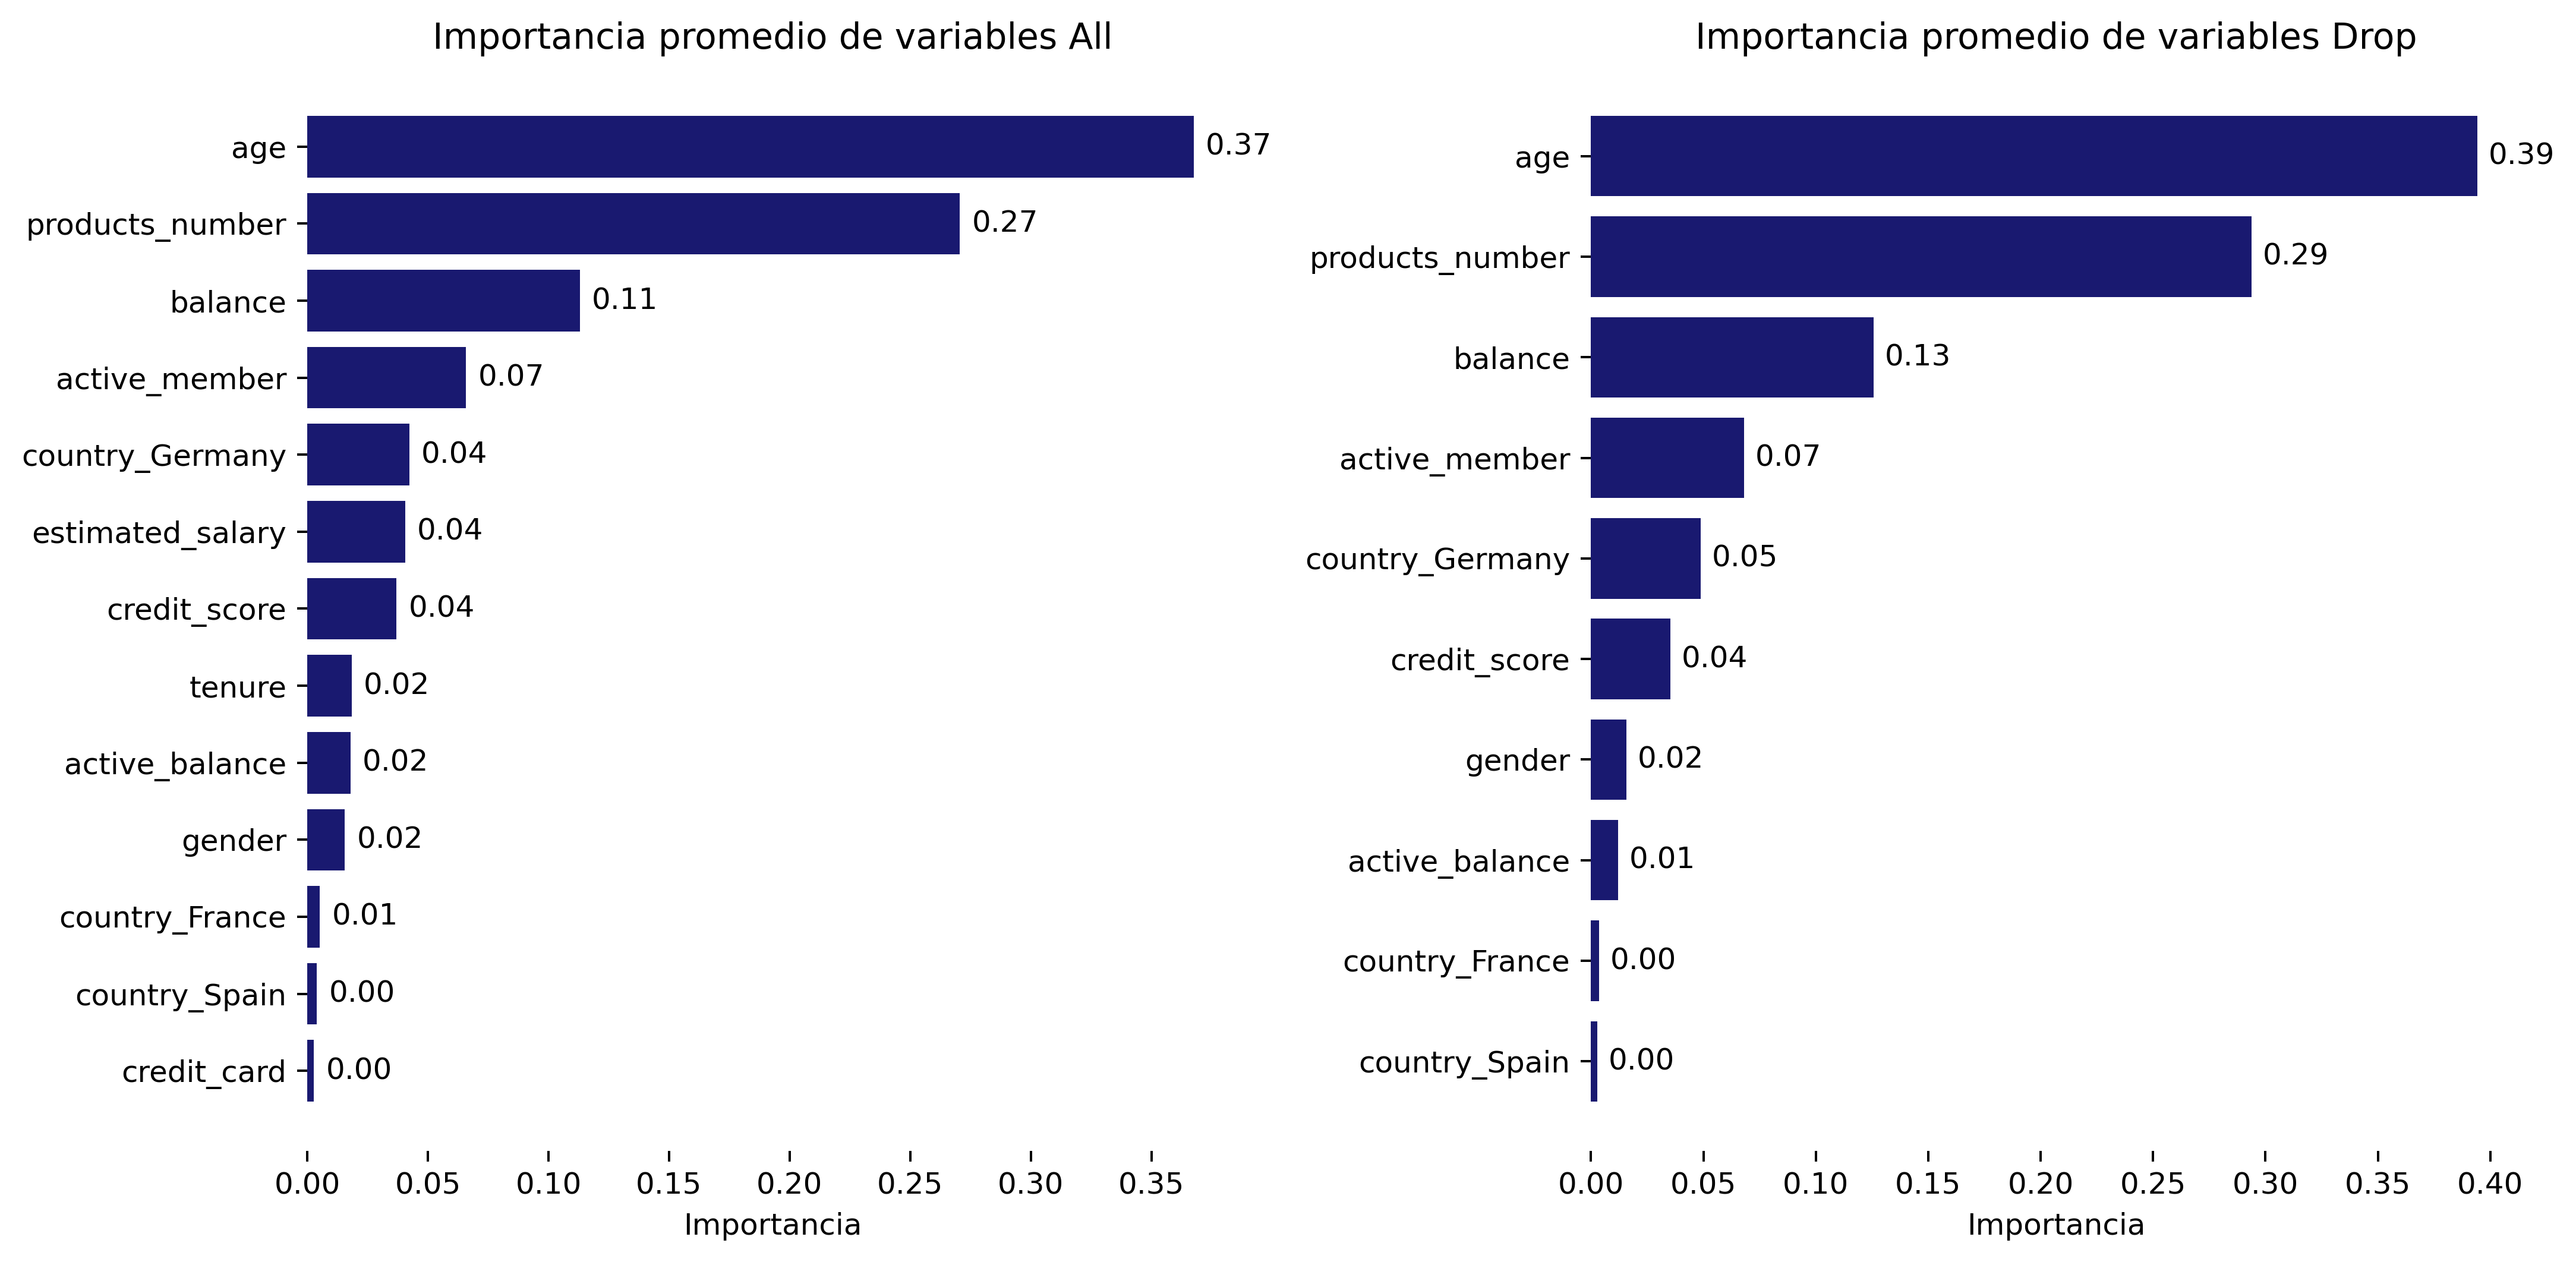

In [145]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (12,6), dpi = 360)

# Gráfica importance All
vars_importance_all['mean'] = vars_importance_all.mean(axis = 1)
importance = vars_importance_all['mean'].sort_values(ascending = False)
y_pos = np.arange(importance.shape[0])
axs[0].barh(y_pos, importance, color = churn_colors[0])
axs[0].set_yticks(y_pos, labels = importance.axes[0])
axs[0].invert_yaxis()  # labels read top-to-bottom
axs[0].set_xlabel('Importancia')
axs[0].set_title('Importancia promedio de variables All')

for i, v in enumerate(importance):
    axs[0].text(v + 0.005, i, f'{v:.2f}', va='center')
    
for spine in axs[0].spines.values():
    spine.set_visible(False)

# Gráfica importance drop
vars_importance_drop['mean'] = vars_importance_drop.mean(axis = 1)
importance = vars_importance_drop['mean'].sort_values(ascending = False)
y_pos = np.arange(importance.shape[0])
axs[1].barh(y_pos, importance, color = churn_colors[0])
axs[1].set_yticks(y_pos, labels = importance.axes[0])
axs[1].invert_yaxis()  # labels read top-to-bottom
axs[1].set_xlabel('Importancia')
axs[1].set_title('Importancia promedio de variables Drop')
plt.tight_layout()

for i, v in enumerate(importance):
    axs[1].text(v+ 0.005, i, f'{v:.2f}', va='center')

for spine in axs[1].spines.values():
    spine.set_visible(False)
plt.show()

In [80]:
"""
param_distributions = {'max_depth': np.arange(11,12,1),
                       'max_features': np.arange(8,9,1),
                       'max_leaf_nodes': np.arange(20, 51,5),
                       'min_samples_split': np.arange(140,181,5),
                       'min_samples_leaf': np.arange(10,36,5)}

model = RandomizedSearchCV(estimator = clf,
                           param_distributions = param_distributions,
                           n_iter=100,
                           scoring=make_scorer(fbeta_score, beta=2),
                           cv=skf,
                           random_state=SEED)

results = pd.DataFrame(model.cv_results_)

columns_list = ['param_max_depth',
                'param_max_leaf_nodes',
                'mean_test_F2_score',
                'std_test_F2_score',
                'mean_test_average_precision',
                'std_test_average_precision']

results[columns_list].sort_values('mean_test_average_precision', ascending =0).head(10)

from IPython.display import Audio, display
display(Audio(filename='C:/Users/Adrej/Downloads/success-48018.wav', autoplay=True))
"""

"\nparam_distributions = {'max_depth': np.arange(11,12,1),\n                       'max_features': np.arange(8,9,1),\n                       'max_leaf_nodes': np.arange(20, 51,5),\n                       'min_samples_split': np.arange(140,181,5),\n                       'min_samples_leaf': np.arange(10,36,5)}\n\nmodel = RandomizedSearchCV(estimator = clf,\n                           param_distributions = param_distributions,\n                           n_iter=100,\n                           scoring=make_scorer(fbeta_score, beta=2),\n                           cv=skf,\n                           random_state=SEED)\n\nresults = pd.DataFrame(model.cv_results_)\n\ncolumns_list = ['param_max_depth',\n                'param_max_leaf_nodes',\n                'mean_test_F2_score',\n                'std_test_F2_score',\n                'mean_test_average_precision',\n                'std_test_average_precision']\n\nresults[columns_list].sort_values('mean_test_average_precision', ascending =0).